# TP2 — Análise Exploratória de Dados de Tickets de Suporte

## 1.1 — Compreensão do problema e do dataset

### Contexto do problema

Este trabalho utiliza um conjunto de dados de tickets de atendimento ao cliente com o objetivo de compreender os padrões presentes nas solicitações de suporte e preparar os dados para uma futura tarefa de classificação.

O problema de classificação previsto para o TP3 consiste em **prever a intenção de um ticket**, representada pela variável `Ticket Type`, a partir das informações disponíveis sobre a solicitação do cliente.

A variável `Ticket Type` possui cinco classes:

- `Billing inquiry`
- `Cancellation request`
- `Product inquiry`
- `Refund request`
- `Technical issue`

Nesse contexto, a variável `Ticket Description` é especialmente importante, pois contém a descrição textual escrita para representar o problema ou a necessidade do cliente. A variável `Ticket Subject` também pode fornecer informações úteis sobre a intenção do chamado.

### Dataset

O dataset utilizado contém:

- **8.469 registros**
- **17 variáveis**

As variáveis incluem informações:

- numéricas;
- categóricas;
- textuais;
- temporais;
- identificadoras.

Entre elas, destacam-se:

- `Ticket Type`: variável-alvo da futura tarefa de classificação;
- `Ticket Description`: descrição textual do chamado;
- `Ticket Subject`: assunto do chamado;
- `Customer Age`: idade do cliente;
- `Product Purchased`: produto relacionado ao ticket;
- `Ticket Priority`: prioridade atribuída ao chamado;
- `Ticket Channel`: canal utilizado pelo cliente.

Algumas variáveis, como `Resolution`, `Customer Satisfaction Rating`, `First Response Time`, `Time to Resolution` e `Ticket Status`, representam informações geradas durante ou após o processo de atendimento. Por isso, sua utilização como preditoras deverá ser avaliada com cuidado, pois elas podem não estar disponíveis no momento em que um novo ticket é aberto e podem provocar **vazamento de informação (data leakage)**.

Variáveis como `Ticket ID`, `Customer Name` e `Customer Email` possuem caráter identificador e, em princípio, não representam características adequadas para prever a intenção do ticket.

### Objetivos da Análise Exploratória de Dados

A EDA será realizada com os seguintes objetivos:

1. compreender a estrutura e o conteúdo do dataset;
2. avaliar a qualidade dos dados;
3. realizar a limpeza e preparação necessárias;
4. analisar individualmente variáveis numéricas, categóricas e textuais;
5. investigar relações entre as variáveis;
6. identificar características potencialmente úteis para prever `Ticket Type`;
7. identificar variáveis independentes redundantes;
8. investigar outliers e anomalias de forma criteriosa;
9. formular e testar hipóteses estatísticas;
10. produzir insights que orientem a construção do classificador de intenção no TP3.

Dessa forma, a análise exploratória não busca apenas descrever os dados, mas também identificar quais informações possuem potencial preditivo e quais cuidados deverão ser considerados na etapa futura de modelagem.



# **Importação de Bibliotecas e Carregamento dos Dados**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
import numpy as np
from scipy.stats import chi2_contingency
import os


def print_formatado(*args, largura_total=100):
    titulo = " ".join(str(a) for a in args)

    print("\n")
    print("=" * largura_total)
    print(titulo)
    print("=" * largura_total)


file_path = "/content/customer_support_tickets.csv"


if not os.path.exists(file_path):

    raise FileNotFoundError(
        f"Arquivo não encontrado em: {file_path}\n"
        "Faça o upload do arquivo customer_support_tickets.csv "
        "para o ambiente do Google Colab antes de executar o notebook."
    )


df = pd.read_csv(file_path)


print(
    f"Dataset carregado com sucesso: "
    f"{df.shape[0]} linhas e "
    f"{df.shape[1]} colunas."
)

Dataset carregado com sucesso: 8469 linhas e 17 colunas.


# 1.2 — **Inspeção inicial**

In [3]:
print_formatado("1. Tamanho do dataset:")

print(df.shape)


print_formatado("2. Variáveis do dataset:")

print(df.columns.tolist())


print_formatado("3. Significado das colunas:")

print("Ver Markdown")


print_formatado("4. Tipos dos dados:")

print(df.dtypes)


print_formatado("5. Organização dos registros:")

df.info()

print("Ver Markdown")

print_formatado("5.1 Resumo descritivo das variáveis:")

display(
    df.describe(
        include="all"
    ).T
)

print_formatado("6. Exemplo de valores:")

print("\nPrimeiros registros:")
display(df.head())

print("\nÚltimos registros:")
display(df.tail())

print("\nRegistros aleatórios:")
display(df.sample(5, random_state=1))


print_formatado("7. Identificação das variáveis")



print("\nVariáveis numéricas:")

variaveis_numericas = [
    "Customer Age",
    "Customer Satisfaction Rating"
]

for coluna in variaveis_numericas:

    print(
        f"{coluna}: "
        f"min={df[coluna].min()}, "
        f"max={df[coluna].max()}, "
        f"média={df[coluna].mean():.2f}"
    )



print("\nVariáveis categóricas:")

variaveis_categoricas = [
    "Customer Gender",
    "Product Purchased",
    "Ticket Type",
    "Ticket Status",
    "Ticket Priority",
    "Ticket Channel"
]

for coluna in variaveis_categoricas:

    print(
        f"{coluna}: "
        f"{df[coluna].nunique()} valores únicos"
    )



print("\nVariáveis textuais:")

variaveis_textuais = [
    "Customer Name",
    "Customer Email",
    "Ticket Subject",
    "Ticket Description",
    "Resolution"
]

for coluna in variaveis_textuais:

    print(
        f"{coluna}: "
        f"{df[coluna].nunique()} valores únicos"
    )



print("\nVariáveis temporais:")

variaveis_temporais = [
    "Date of Purchase",
    "First Response Time",
    "Time to Resolution"
]

for coluna in variaveis_temporais:

    print(
        f"{coluna}: "
        f"{df[coluna].nunique()} valores únicos"
    )



print("\nIdentificador:")

print(
    f"Ticket ID: "
    f"{df['Ticket ID'].nunique()} identificadores únicos"
)


print_formatado("8. Variáveis relevantes para o objetivo da análise")

print("Ver Markdown")


print_formatado("9. Possíveis problemas nos dados")

print("\nValores ausentes por variável:")

print(df.isnull().sum())


print("\nPercentual de valores ausentes:")

print(
    (df.isnull().mean() * 100)
    .round(2)
)


print("\nRegistros duplicados:")

print(df.duplicated().sum())


print("\nTipos das variáveis de tempo:")

for coluna in variaveis_temporais:

    print(
        f"{coluna}: {df[coluna].dtype}"
    )


print("Ver Markdown")



1. Tamanho do dataset:
(8469, 17)


2. Variáveis do dataset:
['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age', 'Customer Gender', 'Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution', 'Ticket Priority', 'Ticket Channel', 'First Response Time', 'Time to Resolution', 'Customer Satisfaction Rating']


3. Significado das colunas:
Ver Markdown


4. Tipos dos dados:
Ticket ID                         int64
Customer Name                    object
Customer Email                   object
Customer Age                      int64
Customer Gender                  object
Product Purchased                object
Date of Purchase                 object
Ticket Type                      object
Ticket Subject                   object
Ticket Description               object
Ticket Status                    object
Resolution                       object
Ticket Priority                  object
Ticket Channel             

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Ticket ID,8469.0,NaN,NaN,NaN,4235.0,2444.934048,1.0,2118.0,4235.0,6352.0,8469.0
Customer Name,8469,8028,Michael Garcia,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Email,8469,8320,bsmith@example.com,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Age,8469.0,NaN,NaN,NaN,44.026804,15.296112,18.0,31.0,44.0,57.0,70.0
Customer Gender,8469,3,Male,2896,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product Purchased,8469,42,Canon EOS,240,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date of Purchase,8469,730,2020-10-21,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ticket Type,8469,5,Refund request,1752,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ticket Subject,8469,16,Refund request,576,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ticket Description,8469,8077,I'm having an issue with the {product_purchase...,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN




6. Exemplo de valores:

Primeiros registros:


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0



Últimos registros:


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
8464,8465,David Todd,adam28@example.net,22,Female,LG OLED,2021-12-08,Product inquiry,Installation support,My {product_purchased} is making strange noise...,Open,NaN,Low,Phone,NaN,NaN,NaN
8465,8466,Lori Davis,russell68@example.com,27,Female,Bose SoundLink Speaker,2020-02-22,Technical issue,Refund request,I'm having an issue with the {product_purchase...,Open,NaN,Critical,Email,NaN,NaN,NaN
8466,8467,Michelle Kelley,ashley83@example.org,57,Female,GoPro Action Camera,2021-08-17,Technical issue,Account access,I'm having an issue with the {product_purchase...,Closed,Eight account century nature kitchen.,High,Social media,2023-06-01 09:44:22,2023-06-01 04:31:22,3.0
8467,8468,Steven Rodriguez,fpowell@example.org,54,Male,PlayStation,2021-10-16,Product inquiry,Payment issue,I'm having an issue with the {product_purchase...,Closed,We seat culture plan.,Medium,Email,2023-06-01 18:28:24,2023-06-01 05:32:24,3.0
8468,8469,Steven Davis MD,lori20@example.net,53,Other,Philips Hue Lights,2020-06-01,Billing inquiry,Hardware issue,There seems to be a hardware problem with my {...,Open,NaN,High,Phone,NaN,NaN,NaN



Registros aleatórios:


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
1825,1826,Angela Humphrey,joshua84@example.com,55,Female,Bose SoundLink Speaker,2021-06-11,Billing inquiry,Hardware issue,I'm having an issue with the {product_purchase...,Closed,Any because size far record.,High,Chat,2023-06-01 17:06:29,2023-06-01 06:25:29,2.0
473,474,James Escobar,huertaryan@example.com,32,Male,Adobe Photoshop,2021-10-08,Technical issue,Hardware issue,I'm having an issue with the {product_purchase...,Open,NaN,Medium,Phone,NaN,NaN,NaN
3509,3510,Daniel Mccullough,davidcox@example.com,61,Male,Adobe Photoshop,2021-02-16,Refund request,Product recommendation,I'm encountering a software bug in the {produc...,Open,NaN,Critical,Chat,NaN,NaN,NaN
5415,5416,Nicole Knight,johnhess@example.com,46,Female,Bose QuietComfort,2020-08-20,Refund request,Software bug,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,High,Chat,2023-06-01 13:49:59,NaN,NaN
5537,5538,Jessica Chase,wschwartz@example.com,45,Female,Samsung Galaxy,2021-02-02,Technical issue,Software bug,I'm having an issue with the {product_purchase...,Closed,Debate wife window kitchen inside tonight give...,Low,Phone,2023-05-31 23:53:47,2023-06-01 13:18:47,2.0




7. Identificação das variáveis

Variáveis numéricas:
Customer Age: min=18, max=70, média=44.03
Customer Satisfaction Rating: min=1.0, max=5.0, média=2.99

Variáveis categóricas:
Customer Gender: 3 valores únicos
Product Purchased: 42 valores únicos
Ticket Type: 5 valores únicos
Ticket Status: 3 valores únicos
Ticket Priority: 4 valores únicos
Ticket Channel: 4 valores únicos

Variáveis textuais:
Customer Name: 8028 valores únicos
Customer Email: 8320 valores únicos
Ticket Subject: 16 valores únicos
Ticket Description: 8077 valores únicos
Resolution: 2769 valores únicos

Variáveis temporais:
Date of Purchase: 730 valores únicos
First Response Time: 5470 valores únicos
Time to Resolution: 2728 valores únicos

Identificador:
Ticket ID: 8469 identificadores únicos


8. Variáveis relevantes para o objetivo da análise
Ver Markdown


9. Possíveis problemas nos dados

Valores ausentes por variável:
Ticket ID                          0
Customer Name                      0
Customer Email      

## 1.2 — Observações da inspeção inicial

### Estrutura geral do dataset

A inspeção inicial mostra que o dataset possui **8.469 registros e 17 colunas**, contendo informações sobre clientes, produtos, tickets, atendimento e satisfação.

O índice do DataFrame varia de 0 a 8.468, seguindo o padrão de indexação do Pandas.

Foram encontrados diferentes tipos de dados. As variáveis `Customer Age` e `Ticket ID` foram carregadas como inteiras (`int64`), enquanto `Customer Satisfaction Rating` foi carregada como `float64`. Diversas outras colunas foram inicialmente carregadas como `object`, incluindo variáveis categóricas, textuais e temporais.

### Significado das principais variáveis

- **Ticket ID:** identificador único de cada ticket.
- **Customer Name:** nome do cliente.
- **Customer Email:** endereço de e-mail do cliente.
- **Customer Age:** idade do cliente.
- **Customer Gender:** gênero informado pelo cliente.
- **Product Purchased:** produto relacionado ao atendimento.
- **Date of Purchase:** data de aquisição do produto.
- **Ticket Type:** tipo ou intenção principal do ticket. Esta será a **variável-alvo da classificação prevista para o TP3**.
- **Ticket Subject:** assunto associado ao chamado.
- **Ticket Description:** descrição textual do problema ou solicitação apresentada pelo cliente.
- **Ticket Status:** situação atual do chamado, como aberto, fechado ou aguardando resposta do cliente.
- **Resolution:** descrição da solução fornecida ao cliente.
- **Ticket Priority:** prioridade atribuída ao chamado.
- **Ticket Channel:** canal utilizado pelo cliente para entrar em contato.
- **First Response Time:** data e horário da primeira resposta ao cliente.
- **Time to Resolution:** data e horário registrados para a resolução do chamado.
- **Customer Satisfaction Rating:** avaliação de satisfação atribuída pelo cliente ao atendimento.

### Tipos de variáveis

Para orientar as próximas etapas da EDA, as variáveis podem ser organizadas da seguinte forma:

**Variáveis numéricas:**
- `Customer Age`
- `Customer Satisfaction Rating`

**Variáveis categóricas:**
- `Customer Gender`
- `Product Purchased`
- `Ticket Type`
- `Ticket Subject`
- `Ticket Status`
- `Ticket Priority`
- `Ticket Channel`

**Variáveis textuais:**
- `Ticket Description`
- `Resolution`

`Customer Name` e `Customer Email` também possuem valores textuais, porém funcionam principalmente como identificadores do cliente e não como características relevantes para a futura classificação.

**Variáveis temporais:**
- `Date of Purchase`
- `First Response Time`
- `Time to Resolution`

**Identificador:**
- `Ticket ID`

Embora `Ticket ID` seja numericamente representado, ele não deve ser tratado como uma variável quantitativa, pois sua função é apenas identificar os registros.

### Valores ausentes observados

A inspeção mostra que algumas colunas não possuem valores preenchidos em todos os registros.

- `Resolution`: 2.769 valores preenchidos.
- `Time to Resolution`: 2.769 valores preenchidos.
- `Customer Satisfaction Rating`: 2.769 valores preenchidos.
- `First Response Time`: 5.650 valores preenchidos.

Essas ausências não devem ser consideradas erros automaticamente. Elas podem estar relacionadas ao estágio do atendimento, já que tickets ainda abertos ou aguardando resposta do cliente podem naturalmente não possuir resolução, horário de resolução ou avaliação de satisfação.

Essa hipótese será investigada posteriormente na etapa de qualidade dos dados.

### Variável-alvo e relação com o TP3

A variável mais importante para o objetivo futuro do projeto é `Ticket Type`, que representa a intenção associada ao ticket.

O dataset apresenta cinco classes de intenção:

- `Billing inquiry`
- `Cancellation request`
- `Product inquiry`
- `Refund request`
- `Technical issue`

Nas próximas etapas da EDA, será investigado quais atributos apresentam relação com `Ticket Type` e podem fornecer informação útil para sua previsão.

As variáveis `Ticket Description` e `Ticket Subject` são especialmente importantes, pois representam informações disponíveis diretamente sobre o conteúdo da solicitação do cliente.

Outras características, como `Product Purchased`, `Ticket Channel`, `Ticket Priority`, `Customer Age` e `Customer Gender`, também serão investigadas para verificar se apresentam associação com a intenção do ticket.

### Variáveis que exigem cautela na futura modelagem

Algumas informações presentes no dataset são produzidas durante ou após o atendimento, como:

- `Resolution`
- `Ticket Status`
- `First Response Time`
- `Time to Resolution`
- `Customer Satisfaction Rating`

Mesmo que essas variáveis apresentem associação estatística com `Ticket Type`, sua utilização como preditoras deverá ser avaliada cuidadosamente.

Se uma informação não estiver disponível no momento em que um novo ticket é aberto, utilizá-la para prever sua intenção poderá provocar **vazamento de informação (data leakage)** e gerar uma avaliação artificialmente otimista do modelo.

### Pontos que serão investigados nas próximas etapas

A inspeção inicial indica a necessidade de verificar:

1. valores ausentes e sua relação com o status dos tickets;
2. registros duplicados;
3. duplicidade do identificador `Ticket ID`;
4. consistência das variáveis temporais;
5. qualidade das variáveis textuais;
6. possíveis valores extremos e anomalias;
7. distribuição das classes de `Ticket Type`;
8. relações entre as variáveis independentes e a variável-alvo;
9. possíveis variáveis redundantes;
10. características potencialmente úteis para a classificação de intenção no TP3.

Portanto, a inspeção inicial confirma que o dataset possui variáveis numéricas, categóricas, textuais e temporais suficientes para uma EDA abrangente, mas também apresenta aspectos de qualidade e disponibilidade das informações que deverão ser considerados antes da modelagem.

## 1.3 — Verificação da qualidade dos dados

In [6]:
import unicodedata

colunas_categoricas = [
    "Customer Gender",
    "Product Purchased",
    "Ticket Type",
    "Ticket Subject",
    "Ticket Status",
    "Ticket Priority",
    "Ticket Channel"
]

colunas_textuais = [
    "Customer Name",
    "Customer Email",
    "Ticket Subject",
    "Ticket Description",
    "Resolution"
]

colunas_temporais = [
    "Date of Purchase",
    "First Response Time",
    "Time to Resolution"
]


print_formatado("1. Valores ausentes:")

print("Valores ausentes (NaN):")
print(df.isnull().sum())

print("\nPercentual de valores ausentes:")
print(
    (df.isnull().mean() * 100)
    .round(2)
    .sort_values(ascending=False)
)

print("\nValores ausentes representados por '?':")

for coluna in df.select_dtypes(include="object").columns:

    qtd_interrogacao = (
        df[coluna]
        .astype(str)
        .str.strip()
        .eq("?")
        .sum()
    )

    print(
        f"{coluna:<30}: {qtd_interrogacao}"
    )

print("Ver Markdown")



print_formatado("2. Registros duplicados:")

print("Duplicatas completas:")
print(df.duplicated().sum())

print("\nTicket IDs duplicados:")
print(df["Ticket ID"].duplicated().sum())

print("\nQuantidade de Ticket IDs únicos:")
print(df["Ticket ID"].nunique())

print("Ver Markdown")



print_formatado("3. Tipos de dados:")

for coluna in df.columns:

    print(f"\n{coluna}:")

    print(
        df[coluna]
        .apply(type)
        .value_counts()
    )


print("\nQuantidade de valores únicos:")

for coluna in df.columns:

    print(
        f"{coluna:<30}: "
        f"{df[coluna].nunique()}"
    )

print("Ver Markdown")



print_formatado(
    "4. Categorias escritas de maneira diferente:"
)


def normalizar_texto(valor):

    if pd.isna(valor):
        return valor

    valor = str(valor).strip().lower()

    valor = (
        unicodedata
        .normalize("NFKD", valor)
        .encode("ASCII", "ignore")
        .decode("utf-8")
    )

    return valor


for coluna in colunas_categoricas:

    sem_normalizacao = (
        df[coluna].nunique()
    )

    com_normalizacao = (
        df[coluna]
        .apply(normalizar_texto)
        .nunique()
    )

    print(
        f"{coluna:<30} -> "
        f"Original: {sem_normalizacao} | "
        f"Normalizado: {com_normalizacao}"
    )

print("Ver Markdown")



print_formatado(
    "5. Textos vazios ou espaços extras:"
)

for coluna in colunas_textuais:

    valores_string = (
        df[coluna]
        .dropna()
        .astype(str)
    )

    vazios = (
        valores_string
        .str.strip()
        .eq("")
        .sum()
    )

    espacos_extras = (
        valores_string
        .ne(valores_string.str.strip())
        .sum()
    )

    print(
        f"\n{coluna}:"
    )

    print(
        f"  Textos vazios: {vazios}"
    )

    print(
        f"  Espaços extras: {espacos_extras}"
    )

print("Ver Markdown")

print_formatado(
    "5.1 Qualidade das variáveis textuais:"
)

# Descrições duplicadas
descricoes_duplicadas = (
    df["Ticket Description"]
    .duplicated()
    .sum()
)

print(
    f"Ticket Description duplicadas: "
    f"{descricoes_duplicadas}"
)


# Assuntos duplicados
assuntos_unicos = (
    df["Ticket Subject"]
    .nunique()
)

print(
    f"Ticket Subject únicos: "
    f"{assuntos_unicos}"
)


# Verificação de possíveis placeholders artificiais
padrao_placeholder = r"\{[^{}]+\}"

placeholders_description = (
    df["Ticket Description"]
    .fillna("")
    .str.contains(
        padrao_placeholder,
        regex=True
    )
    .sum()
)

placeholders_resolution = (
    df["Resolution"]
    .fillna("")
    .str.contains(
        padrao_placeholder,
        regex=True
    )
    .sum()
)

print(
    f"Ticket Description com possíveis placeholders: "
    f"{placeholders_description}"
)

print(
    f"Resolution com possíveis placeholders: "
    f"{placeholders_resolution}"
)


# Comprimento dos textos
comprimento_descricao = (
    df["Ticket Description"]
    .fillna("")
    .str.len()
)

print("\nComprimento de Ticket Description:")

print(
    comprimento_descricao
    .describe()
)


# Quantidade de palavras
quantidade_palavras = (
    df["Ticket Description"]
    .fillna("")
    .str.split()
    .str.len()
)

print("\nQuantidade de palavras em Ticket Description:")

print(
    quantidade_palavras
    .describe()
)

print("Ver Markdown")


print_formatado(
    "5.2 Placeholders encontrados em Ticket Description:"
)

placeholders_encontrados = (
    df["Ticket Description"]
    .fillna("")
    .str.findall(r"\{[^{}]+\}")
    .explode()
    .dropna()
    .value_counts()
)

print(placeholders_encontrados)

print(
    "\nQuantidade de tipos diferentes de placeholders:"
)

print(
    placeholders_encontrados.shape[0]
)

print("Ver Markdown")


print_formatado(
    "5.3 Distribuição dos placeholders nas descrições:"
)

# Quantidade de placeholders por descrição
qtd_placeholders_por_ticket = (
    df["Ticket Description"]
    .fillna("")
    .str.findall(r"\{[^{}]+\}")
    .str.len()
)

print("Quantidade de placeholders por ticket:")
print(
    qtd_placeholders_por_ticket.describe()
)


# Tickets sem nenhum placeholder
tickets_sem_placeholder = (
    qtd_placeholders_por_ticket == 0
).sum()

print(
    f"\nTickets sem placeholder: "
    f"{tickets_sem_placeholder}"
)


# Tickets com mais de um placeholder
tickets_multiplos_placeholders = (
    qtd_placeholders_por_ticket > 1
).sum()

print(
    f"Tickets com mais de um placeholder: "
    f"{tickets_multiplos_placeholders}"
)


# 20 placeholders mais frequentes
print(
    "\n20 placeholders mais frequentes:"
)

print(
    placeholders_encontrados
    .head(20)
)


# Normalização para detectar variações apenas de maiúsculas/minúsculas
placeholders_normalizados = (
    df["Ticket Description"]
    .fillna("")
    .str.findall(r"\{[^{}]+\}")
    .explode()
    .dropna()
    .str.lower()
    .str.strip()
    .value_counts()
)

print(
    "\n20 placeholders mais frequentes após normalização:"
)

print(
    placeholders_normalizados
    .head(20)
)

print(
    "\nQuantidade de tipos após normalização:"
)

print(
    placeholders_normalizados.shape[0]
)

print("Ver Markdown")


print_formatado(
    "6. Valores impossíveis ou fora do contexto:"
)



print("\nCustomer Age:")

print(
    f"Mínimo: {df['Customer Age'].min()}"
)

print(
    f"Máximo: {df['Customer Age'].max()}"
)

print(
    f"Idades menores que 0: "
    f"{(df['Customer Age'] < 0).sum()}"
)

print(
    f"Idades maiores que 120: "
    f"{(df['Customer Age'] > 120).sum()}"
)



print(
    "\nCustomer Satisfaction Rating:"
)

print(
    f"Mínimo: "
    f"{df['Customer Satisfaction Rating'].min()}"
)

print(
    f"Máximo: "
    f"{df['Customer Satisfaction Rating'].max()}"
)

print(
    f"Valores menores que 1: "
    f"{(df['Customer Satisfaction Rating'] < 1).sum()}"
)

print(
    f"Valores maiores que 5: "
    f"{(df['Customer Satisfaction Rating'] > 5).sum()}"
)


print("\nCategorias de Ticket Status:")

print(
    df["Ticket Status"]
    .value_counts(dropna=False)
)



print("\nCategorias de Ticket Priority:")

print(
    df["Ticket Priority"]
    .value_counts(dropna=False)
)



print("\nCategorias de Ticket Channel:")

print(
    df["Ticket Channel"]
    .value_counts(dropna=False)
)



print_formatado(
    "7. Consistência entre Ticket Status e Resolution:"
)

tabela_status_resolution = pd.crosstab(
    df["Ticket Status"],
    df["Resolution"].isna(),
    margins=True
)

print(
    tabela_status_resolution
)


print("\nTickets fechados sem resolução:")

print(
    (
        (df["Ticket Status"] == "Closed") &
        (df["Resolution"].isna())
    ).sum()
)


print("\nTickets abertos com resolução preenchida:")

print(
    (
        (df["Ticket Status"] != "Closed") &
        (df["Resolution"].notna())
    ).sum()
)



print_formatado(
    "8. Consistência das variáveis de tempo:"
)

print("\nTipos atuais:")

for coluna in colunas_temporais:

    print(
        f"{coluna:<30}: "
        f"{df[coluna].dtype}"
    )


print("\nQuantidade de valores preenchidos:")

for coluna in colunas_temporais:

    print(
        f"{coluna:<30}: "
        f"{df[coluna].notna().sum()}"
    )


print("\nQuantidade de valores ausentes:")

for coluna in colunas_temporais:

    print(
        f"{coluna:<30}: "
        f"{df[coluna].isna().sum()}"
    )


print("Ver Markdown")



1. Valores ausentes:
Valores ausentes (NaN):
Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Ticket Description                 0
Ticket Status                      0
Resolution                      5700
Ticket Priority                    0
Ticket Channel                     0
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
dtype: int64

Percentual de valores ausentes:
Customer Satisfaction Rating    67.30
Resolution                      67.30
Time to Resolution              67.30
First Response Time             33.29
Ticket ID                        0.00
Customer Name                    0.00
Customer Email                   0.00
Customer Age

## 1.3 — Observações da qualidade dos dados

### 1. Valores ausentes

O dataset possui **8.469 registros** e apresenta valores ausentes em quatro variáveis:

- `Resolution`: 5.700 valores ausentes (67,30%);
- `Time to Resolution`: 5.700 valores ausentes (67,30%);
- `Customer Satisfaction Rating`: 5.700 valores ausentes (67,30%);
- `First Response Time`: 2.819 valores ausentes (33,29%).

As demais variáveis não apresentam valores ausentes e não foram encontrados valores ausentes representados pelo caractere `?`.

Essas ausências não devem ser tratadas automaticamente como erros. Elas estão fortemente relacionadas ao estágio do atendimento. Tickets que ainda não foram encerrados podem naturalmente não possuir resolução, horário de resolução ou avaliação de satisfação.

Por esse motivo, os valores ausentes serão preservados neste momento e tratados de acordo com o significado de cada variável.

### 2. Registros duplicados

Não foram encontradas duplicatas completas no dataset.

Também não foram encontrados valores duplicados em `Ticket ID`. Existem **8.469 identificadores únicos para 8.469 registros**, indicando que cada ticket possui um identificador próprio.

Entretanto, foram encontradas **392 ocorrências de `Ticket Description` duplicadas**.

Isso não significa necessariamente que existam registros completos repetidos, mas mostra que tickets diferentes podem possuir exatamente a mesma descrição textual.

Esse aspecto deverá ser considerado no TP3, pois descrições idênticas distribuídas entre conjuntos de treino e teste podem provocar uma avaliação artificialmente otimista do modelo.

### 3. Tipos de dados

As variáveis numéricas, como `Customer Age` e `Customer Satisfaction Rating`, apresentam tipos apropriados para análise numérica.

`Ticket ID` também é representado numericamente, mas deve ser considerado apenas um identificador e não uma variável quantitativa.

As variáveis:

- `Date of Purchase`;
- `First Response Time`;
- `Time to Resolution`;

foram originalmente carregadas como `object` e precisarão ser convertidas para tipos temporais apropriados na etapa de limpeza e preparação.

As variáveis categóricas e textuais também foram inicialmente representadas como `object`, comportamento esperado na leitura de arquivos CSV pelo Pandas.

### 4. Consistência das variáveis categóricas

Foi realizada uma normalização para comparar categorias considerando espaços, letras maiúsculas/minúsculas e caracteres especiais.

Nas principais variáveis categóricas não foram identificadas diferenças relevantes provocadas apenas pela forma de escrita.

As categorias observadas incluem:

- `Customer Gender`: 3 categorias;
- `Product Purchased`: 42 categorias;
- `Ticket Type`: 5 categorias;
- `Ticket Subject`: 16 categorias;
- `Ticket Status`: 3 categorias;
- `Ticket Priority`: 4 categorias;
- `Ticket Channel`: 4 categorias.

A variável `Ticket Subject`, apesar de armazenar texto, possui apenas **16 valores distintos**, podendo também ser analisada como uma variável categórica.

### 5. Textos vazios e espaços extras

Não foram encontrados textos vazios nem espaços extras relevantes no início ou no final das variáveis textuais analisadas.

Isso indica que não há evidências de problemas generalizados relacionados a campos preenchidos apenas com espaços em branco.

### 6. Qualidade das variáveis textuais

A variável `Ticket Description` possui conteúdo nos **8.469 registros**.

O comprimento das descrições varia entre:

- mínimo: **151 caracteres**;
- média: aproximadamente **290 caracteres**;
- mediana: **298 caracteres**;
- máximo: **397 caracteres**.

Em relação à quantidade de palavras:

- mínimo: **21 palavras**;
- média: aproximadamente **46 palavras**;
- mediana: **49 palavras**;
- máximo: **63 palavras**.

Os resultados indicam que as descrições possuem extensão relativamente homogênea e não existem tickets com descrições vazias ou extremamente curtas.

### 7. Placeholders e artefatos textuais

Foi identificado um aspecto relevante para a futura classificação: **todos os 8.469 registros de `Ticket Description` possuem pelo menos um trecho no formato `{...}`**.

A quantidade de placeholders por descrição apresenta:

- mínimo: 1;
- média: aproximadamente 1,75;
- mediana: 2;
- máximo: 7.

Além disso, **5.102 tickets possuem mais de um placeholder**.

Foram encontrados inicialmente **289 tipos diferentes de placeholders**. Após normalização de capitalização e espaços, permaneceram **269 tipos diferentes**.

Portanto, a maior parte da diversidade observada não é explicada apenas por diferenças entre letras maiúsculas e minúsculas.

O placeholder mais frequente é:

- `{product_purchased}`: aproximadamente **13,9 mil ocorrências** após normalização.

Outros exemplos encontrados incluem:

- `{error_message}`;
- `{product_id}`;
- `{product_name}`;
- `{product_price}`;
- `{product}`;
- `{name}`;
- `{item_id}`.

Também existem formas pouco frequentes e estruturas aparentemente malformadas.

A presença desses elementos em todas as descrições indica que o dataset possui características de textos construídos a partir de templates ou dados sintéticos.

Esses placeholders **não serão removidos automaticamente**, pois a remoção sem análise pode eliminar informação potencialmente relacionada à intenção do ticket.

Na preparação para o TP3 deverá ser avaliado se esses elementos serão mantidos, normalizados ou substituídos por tokens padronizados, evitando que o modelo aprenda artefatos do processo de geração dos dados em vez de características reais da intenção do cliente.

### 8. Valores impossíveis ou fora do contexto

A variável `Customer Age` apresenta valores entre **18 e 70 anos**.

Não foram identificadas:

- idades negativas;
- idades superiores a 120 anos.

A variável `Customer Satisfaction Rating` apresenta valores entre **1 e 5**, exatamente dentro da escala esperada.

Não foram encontrados valores inferiores a 1 ou superiores a 5.

Portanto, nenhuma dessas duas variáveis apresenta, nesta etapa, valores claramente impossíveis segundo suas regras de domínio.

### 9. Distribuição de algumas variáveis categóricas

`Ticket Status` possui:

- `Pending Customer Response`: 2.881 registros;
- `Open`: 2.819 registros;
- `Closed`: 2.769 registros.

`Ticket Priority` possui:

- `Medium`: 2.192 registros;
- `Critical`: 2.129 registros;
- `High`: 2.085 registros;
- `Low`: 2.063 registros.

`Ticket Channel` possui:

- `Email`: 2.143 registros;
- `Phone`: 2.132 registros;
- `Social media`: 2.121 registros;
- `Chat`: 2.073 registros.

As categorias apresentam quantidades relativamente próximas, não sendo observada concentração extrema em apenas uma categoria.

### 10. Consistência entre `Ticket Status` e `Resolution`

Foi identificada uma relação consistente entre essas duas variáveis.

Todos os **2.769 tickets com status `Closed` possuem `Resolution` preenchida**.

Os tickets com status `Open` ou `Pending Customer Response` apresentam `Resolution` ausente.

Não foram encontrados:

- tickets fechados sem resolução;
- tickets não fechados com resolução preenchida.

Isso confirma que os valores ausentes em `Resolution` possuem significado no contexto dos dados e não devem ser simplesmente preenchidos ou removidos.

### 11. Consistência das variáveis temporais

Antes da etapa de limpeza:

- `Date of Purchase` possui 8.469 valores preenchidos;
- `First Response Time` possui 5.650 valores preenchidos e 2.819 ausentes;
- `Time to Resolution` possui 2.769 valores preenchidos e 5.700 ausentes.

Essas variáveis ainda precisam ser convertidas para tipos temporais apropriados.

Após a conversão, será necessário verificar também a consistência cronológica entre os eventos, pois uma data válida individualmente não garante que a sequência temporal do atendimento seja coerente.

### 12. Implicações para o TP3

A análise de qualidade mostra que `Ticket Description` e `Ticket Subject` possuem potencial importante para a futura classificação de `Ticket Type`.

Entretanto, alguns cuidados serão necessários:

1. investigar e tratar adequadamente os placeholders;
2. considerar as descrições textuais duplicadas ao separar treino e teste;
3. evitar o uso de identificadores como `Ticket ID`, `Customer Name` e `Customer Email`;
4. avaliar cuidadosamente variáveis produzidas depois da abertura do ticket;
5. evitar **data leakage**;
6. preservar valores ausentes quando eles representam o estado real do processo de atendimento.

Portanto, o dataset apresenta qualidade suficiente para prosseguir com a EDA, mas possui características textuais e temporais que exigem tratamento criterioso antes da futura modelagem.

## 1.4 — Limpeza e preparação dos dados

In [7]:


import pandas as pd
import numpy as np


def print_formatado(titulo):
    print("\n" + "=" * 100)
    print(titulo)
    print("=" * 100)



print_formatado("INFORMAÇÕES INICIAIS DO DATASET")

print(f"Número de registros: {df.shape[0]}")
print(f"Número de colunas: {df.shape[1]}")

print("\nTipos das colunas:")
print(df.dtypes)



print_formatado(
    "1. Remover/tratar registros duplicados desnecessários"
)

duplicatas_antes = df.duplicated().sum()

print("\nDuplicatas completas:")
print(f"Duplicatas completas antes: {duplicatas_antes}")

df = df.drop_duplicates().reset_index(drop=True)

duplicatas_depois = df.duplicated().sum()

print(f"Duplicatas completas depois: {duplicatas_depois}")

print(f"\nNúmero de registros após tratamento: {len(df)}")


print_formatado(
    "2. Remover/tratar valores ausentes de forma justificada"
)

colunas_com_nan = [
    "Resolution",
    "Time to Resolution",
    "First Response Time",
    "Customer Satisfaction Rating"
]


print("\nValores ausentes antes do tratamento:")

for coluna in colunas_com_nan:

    quantidade = df[coluna].isna().sum()
    percentual = (quantidade / len(df)) * 100

    print(
        f"{coluna:<35}: "
        f"{quantidade:>5} "
        f"({percentual:>6.2f}%)"
    )


print("\nTratamento de Resolution:")

print(
    "Os valores ausentes serão mantidos, pois representam "
    "registros sem informação de resolução disponível."
)



print("\nTratamento de Time to Resolution:")

quantidade = df["Time to Resolution"].isna().sum()
percentual = (quantidade / len(df)) * 100

print(
    f"A coluna possui {quantidade} valores ausentes "
    f"({percentual:.2f}% do dataset)."
)

print(
    "Os valores ausentes serão mantidos, pois não há "
    "informação disponível para realizar uma imputação confiável."
)


print("\nTratamento de First Response Time:")

quantidade = df["First Response Time"].isna().sum()
percentual = (quantidade / len(df)) * 100

print(
    f"A coluna possui {quantidade} valores ausentes "
    f"({percentual:.2f}% do dataset)."
)

print(
    "Os valores ausentes serão mantidos para evitar "
    "a criação artificial de tempos de resposta."
)



print("\nTratamento de Customer Satisfaction Rating:")

print(
    "Os valores ausentes serão mantidos, pois representam "
    "registros sem avaliação de satisfação disponível."
)



print("\nValores ausentes após o tratamento:")

for coluna in colunas_com_nan:

    quantidade = df[coluna].isna().sum()
    percentual = (quantidade / len(df)) * 100

    print(
        f"{coluna:<35}: "
        f"{quantidade:>5} "
        f"({percentual:>6.2f}%)"
    )



print_formatado(
    "3. Corrigir tipos das colunas categóricas"
)

colunas_categoricas = [
    "Customer Gender",
    "Product Purchased",
    "Ticket Type",
    "Ticket Subject",
    "Ticket Status",
    "Ticket Priority",
    "Ticket Channel"
]


print("\nTipos antes da conversão:")

print(df[colunas_categoricas].dtypes)


for coluna in colunas_categoricas:

    df[coluna] = df[coluna].astype("category")


print("\nTipos depois da conversão:")

print(df[colunas_categoricas].dtypes)



print_formatado(
    "4. Corrigir espaços e inconsistências evidentes"
)


for coluna in colunas_categoricas:

    df[coluna] = (
        df[coluna]
        .astype("string")
        .str.strip()
    )


for coluna in colunas_categoricas:

    df[coluna] = df[coluna].astype("category")


print(
    "Espaços extras no início e no final "
    "foram removidos das variáveis categóricas."
)


print_formatado(
    "4.1 Preparar variáveis textuais"
)

# Mantemos Ticket Description original sem remover placeholders.
# Nesta etapa, criamos apenas variáveis derivadas para a EDA.

df["Description Char Count"] = (
    df["Ticket Description"]
    .fillna("")
    .str.len()
)

df["Description Word Count"] = (
    df["Ticket Description"]
    .fillna("")
    .str.split()
    .str.len()
)

df["Description Placeholder Count"] = (
    df["Ticket Description"]
    .fillna("")
    .str.findall(r"\{[^{}]+\}")
    .str.len()
)


print(
    "Variáveis derivadas criadas:"
)

print(
    "- Description Char Count"
)

print(
    "- Description Word Count"
)

print(
    "- Description Placeholder Count"
)


print(
    "\nResumo das variáveis derivadas:"
)

display(
    df[
        [
            "Description Char Count",
            "Description Word Count",
            "Description Placeholder Count"
        ]
    ].describe()
)


print(
    "\nTicket Description original foi preservada."
)

print(
    "Os placeholders não foram removidos nesta etapa."
)


print_formatado(
    "5. Verificar valores inválidos"
)



print("\nCustomer Age:")

print(
    f"Mínimo: {df['Customer Age'].min()}"
)

print(
    f"Máximo: {df['Customer Age'].max()}"
)


idade_invalida = (
    (df["Customer Age"] < 0) |
    (df["Customer Age"] > 120)
).sum()


print(
    f"Valores inválidos: {idade_invalida}"
)


print("\nCustomer Satisfaction Rating:")

print(
    f"Mínimo: "
    f"{df['Customer Satisfaction Rating'].min()}"
)

print(
    f"Máximo: "
    f"{df['Customer Satisfaction Rating'].max()}"
)


avaliacao_invalida = (
    (df["Customer Satisfaction Rating"] < 1) |
    (df["Customer Satisfaction Rating"] > 5)
).sum()


print(
    f"Valores inválidos: {avaliacao_invalida}"
)



print_formatado(
    "6. Corrigir tipos das variáveis temporais"
)


colunas_temporais = [
    "Date of Purchase",
    "First Response Time",
    "Time to Resolution"
]


print("\nTipos antes da conversão:")

for coluna in colunas_temporais:

    print(
        f"{coluna:<30}: "
        f"{df[coluna].dtype}"
    )


# Guarda a quantidade de valores preenchidos antes da conversão
validos_antes_conversao = {
    coluna: df[coluna].notna().sum()
    for coluna in colunas_temporais
}


for coluna in colunas_temporais:

    df[coluna] = pd.to_datetime(
        df[coluna],
        errors="coerce"
    )


print("\nVerificação de perda de valores na conversão:")

for coluna in colunas_temporais:

    validos_antes = validos_antes_conversao[coluna]

    validos_depois = (
        df[coluna]
        .notna()
        .sum()
    )

    perdidos = (
        validos_antes
        - validos_depois
    )

    print(
        f"{coluna:<30}: "
        f"antes = {validos_antes} | "
        f"depois = {validos_depois} | "
        f"perdidos = {perdidos}"
    )


print("\nTipos depois da conversão:")

for coluna in colunas_temporais:

    print(
        f"{coluna:<30}: "
        f"{df[coluna].dtype}"
    )


print("\nValores válidos após a conversão:")

for coluna in colunas_temporais:

    quantidade_validos = (
        df[coluna]
        .notna()
        .sum()
    )

    print(
        f"{coluna:<30}: "
        f"{quantidade_validos}"
    )


print("\nValores ausentes após a conversão:")

for coluna in colunas_temporais:

    quantidade_ausentes = (
        df[coluna]
        .isna()
        .sum()
    )

    percentual_ausentes = (
        quantidade_ausentes /
        len(df)
    ) * 100

    print(
        f"{coluna:<30}: "
        f"{quantidade_ausentes} "
        f"({percentual_ausentes:.2f}%)"
    )


print_formatado(
    "7. Verificar consistência das variáveis de tempo"
)


print("\nIntervalos das variáveis temporais:")

for coluna in colunas_temporais:

    print(f"\n{coluna}:")

    print(
        f"Menor valor: "
        f"{df[coluna].min()}"
    )

    print(
        f"Maior valor: "
        f"{df[coluna].max()}"
    )


print("\nValores preenchidos por status do ticket:")

for status in df["Ticket Status"].unique():

    dados_status = df[
        df["Ticket Status"] == status
    ]

    print(f"\nStatus: {status}")
    print(f"Quantidade de tickets: {len(dados_status)}")

    print(
        f"First Response Time preenchidos: "
        f"{dados_status['First Response Time'].notna().sum()}"
    )

    print(
        f"Time to Resolution preenchidos: "
        f"{dados_status['Time to Resolution'].notna().sum()}"
    )


print_formatado(
    "8. Resumo da qualidade dos dados após a limpeza"
)


print(f"Registros: {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")


print(
    f"\nDuplicatas completas: "
    f"{df.duplicated().sum()}"
)


print("\nValores ausentes por coluna:")

valores_ausentes = df.isna().sum()

percentuais_ausentes = (
    df.isna().mean() * 100
)


resumo_ausentes = pd.DataFrame({
    "Valores Ausentes": valores_ausentes,
    "Percentual (%)": percentuais_ausentes.round(2)
})


print(resumo_ausentes)



print_formatado(
    "9. Tipos finais das variáveis"
)

print(df.dtypes)



print_formatado(
    "10. Resumo das variáveis numéricas"
)


colunas_numericas = [
    "Customer Age",
    "Customer Satisfaction Rating"
]


print(
    df[colunas_numericas].describe()
)



print_formatado(
    "11. Resumo das variáveis categóricas"
)


for coluna in colunas_categoricas:

    print(f"\n{coluna}:")

    print(
        df[coluna]
        .value_counts(dropna=False)
    )



print_formatado(
    "12. Amostra do dataset após a limpeza"
)

print(df.head())



print_formatado(
    "13. VERIFICAÇÃO FINAL PARA INICIAR AS ANÁLISES"
)

print(
    "Dataset preparado para as próximas etapas da "
    "Análise Exploratória de Dados."
)

print(
    f"\nTotal de registros: {len(df)}"
)

print(
    f"Total de variáveis: {len(df.columns)}"
)

print(
    f"Total de duplicatas: {df.duplicated().sum()}"
)

print(
    f"Total de células ausentes: "
    f"{df.isna().sum().sum()}"
)


INFORMAÇÕES INICIAIS DO DATASET
Número de registros: 8469
Número de colunas: 17

Tipos das colunas:
Ticket ID                         int64
Customer Name                    object
Customer Email                   object
Customer Age                      int64
Customer Gender                  object
Product Purchased                object
Date of Purchase                 object
Ticket Type                      object
Ticket Subject                   object
Ticket Description               object
Ticket Status                    object
Resolution                       object
Ticket Priority                  object
Ticket Channel                   object
First Response Time              object
Time to Resolution               object
Customer Satisfaction Rating    float64
dtype: object

1. Remover/tratar registros duplicados desnecessários

Duplicatas completas:
Duplicatas completas antes: 0
Duplicatas completas depois: 0

Número de registros após tratamento: 8469

2. Remover/tratar valo

,Description Char Count,Description Word Count,Description Placeholder Count
count,8469.000000,8469.000000,8469.000000
mean,289.821939,46.467352,1.754044
std,43.593954,8.461730,0.753568
min,151.000000,21.000000,1.000000
25%,273.000000,43.000000,1.000000
50%,298.000000,49.000000,2.000000
75%,318.000000,52.000000,2.000000
max,397.000000,63.000000,7.000000



Ticket Description original foi preservada.
Os placeholders não foram removidos nesta etapa.

5. Verificar valores inválidos

Customer Age:
Mínimo: 18
Máximo: 70
Valores inválidos: 0

Customer Satisfaction Rating:
Mínimo: 1.0
Máximo: 5.0
Valores inválidos: 0

6. Corrigir tipos das variáveis temporais

Tipos antes da conversão:
Date of Purchase              : object
First Response Time           : object
Time to Resolution            : object

Verificação de perda de valores na conversão:
Date of Purchase              : antes = 8469 | depois = 8469 | perdidos = 0
First Response Time           : antes = 5650 | depois = 5650 | perdidos = 0
Time to Resolution            : antes = 2769 | depois = 2769 | perdidos = 0

Tipos depois da conversão:
Date of Purchase              : datetime64[ns]
First Response Time           : datetime64[ns]
Time to Resolution            : datetime64[ns]

Valores válidos após a conversão:
Date of Purchase              : 8469
First Response Time           : 5650


## 1.4 — Observações da limpeza e preparação dos dados

### 1. Registros duplicados

Não foram encontradas duplicatas completas no dataset.

O conjunto permaneceu com **8.469 registros** após essa verificação, portanto não houve necessidade de remover observações.

### 2. Valores ausentes

Os valores ausentes foram mantidos de forma justificada.

As principais ausências permanecem em:

- `Resolution`: 5.700 valores ausentes (67,30%);
- `Time to Resolution`: 5.700 valores ausentes (67,30%);
- `First Response Time`: 2.819 valores ausentes (33,29%);
- `Customer Satisfaction Rating`: 5.700 valores ausentes (67,30%).

Esses valores não foram preenchidos artificialmente porque representam, em grande parte, informações que ainda não existem para determinados estados do atendimento.

Uma imputação sem justificativa poderia introduzir dados artificiais e distorcer as análises posteriores.

### 3. Variáveis categóricas

As seguintes variáveis foram convertidas para o tipo `category`:

- `Customer Gender`;
- `Product Purchased`;
- `Ticket Type`;
- `Ticket Subject`;
- `Ticket Status`;
- `Ticket Priority`;
- `Ticket Channel`.

Também foram tratados possíveis espaços extras no início e no final dos valores categóricos.

Essa conversão melhora a representação sem alterar o significado original dos dados.

### 4. Preparação das variáveis textuais

A variável original `Ticket Description` foi preservada.

Os placeholders encontrados anteriormente não foram removidos nesta etapa, pois ainda não existe evidência suficiente para concluir que todos devem ser descartados.

Foram criadas três variáveis derivadas para apoiar a análise exploratória:

- `Description Char Count`: quantidade de caracteres da descrição;
- `Description Word Count`: quantidade de palavras;
- `Description Placeholder Count`: quantidade de placeholders presentes no texto.

As descrições apresentam, em média:

- aproximadamente **289,82 caracteres**;
- aproximadamente **46,47 palavras**;
- aproximadamente **1,75 placeholders**.

Essas novas variáveis permitirão investigar se características estruturais dos textos possuem alguma relação com a intenção representada por `Ticket Type`.

### 5. Valores inválidos

`Customer Age` apresenta valores entre **18 e 70 anos**, sem idades negativas ou superiores ao limite de domínio considerado.

`Customer Satisfaction Rating` apresenta valores entre **1 e 5**, também sem registros fora da escala esperada.

Portanto, não foi necessário remover ou corrigir valores dessas duas variáveis.

### 6. Conversão das variáveis temporais

As variáveis:

- `Date of Purchase`;
- `First Response Time`;
- `Time to Resolution`;

foram convertidas de `object` para `datetime64[ns]`.

Foi realizada uma verificação antes e depois da conversão e **nenhum valor preenchido foi perdido**:

- `Date of Purchase`: 8.469 antes e 8.469 depois;
- `First Response Time`: 5.650 antes e 5.650 depois;
- `Time to Resolution`: 2.769 antes e 2.769 depois.

Isso confirma que a conversão temporal foi realizada corretamente.

### 7. Disponibilidade das informações temporais

A análise por status mostrou que:

- tickets `Open` não possuem `First Response Time` nem `Time to Resolution`;
- tickets `Pending Customer Response` possuem `First Response Time`, mas não possuem `Time to Resolution`;
- tickets `Closed` possuem tanto `First Response Time` quanto `Time to Resolution`.

Esse comportamento reforça que parte dos valores ausentes possui significado operacional e não representa necessariamente falha de qualidade.

A coerência cronológica entre os horários será analisada posteriormente na etapa específica de identificação de anomalias.

### 8. Dataset após a preparação

Após a preparação, o dataset possui:

- **8.469 registros**;
- **20 variáveis**;
- **0 duplicatas completas**.

O aumento de 17 para 20 variáveis ocorreu exclusivamente pela criação das três características derivadas de `Ticket Description`.

Os dados originais foram preservados sempre que possível, evitando exclusões ou imputações sem justificativa.

### Conclusão

A etapa de limpeza e preparação deixou o dataset em condições adequadas para prosseguir com a análise exploratória.

As principais decisões tomadas foram:

1. preservar ausências com significado contextual;
2. não remover registros sem evidência de erro;
3. converter corretamente variáveis categóricas e temporais;
4. preservar os textos originais;
5. não remover placeholders prematuramente;
6. criar variáveis auxiliares para estudar a estrutura dos textos;
7. manter a análise de anomalias cronológicas para uma etapa específica posterior.


## 1.5 — Análise univariada

### **Variáveis numéricas**


1. Média, mediana, mínimo e máximo

Variável 'Customer Age':
Valores válidos: 8469
Valores ausentes: 0
Média: 44.03
Mediana: 44.00
Mínimo: 18.00
Máximo: 70.00

Variável 'Customer Satisfaction Rating':
Valores válidos: 2769
Valores ausentes: 5700
Média: 2.99
Mediana: 3.00
Mínimo: 1.00
Máximo: 5.00

2. Quartis, variância e desvio-padrão

Variável 'Customer Age':
Q1 (25%): 31.00
Q2 (50% - mediana): 44.00
Q3 (75%): 57.00
Variância: 233.97
Desvio-padrão: 15.30
Assimetria (skewness): -0.0172

Variável 'Customer Satisfaction Rating':
Q1 (25%): 2.00
Q2 (50% - mediana): 3.00
Q3 (75%): 4.00
Variância: 1.98
Desvio-padrão: 1.41
Assimetria (skewness): 0.0084

3. Distribuição dos valores

Variável 'Customer Age':
count    8469.000000
mean       44.026804
std        15.296112
min        18.000000
25%        31.000000
50%        44.000000
75%        57.000000
max        70.000000
Name: Customer Age, dtype: float64


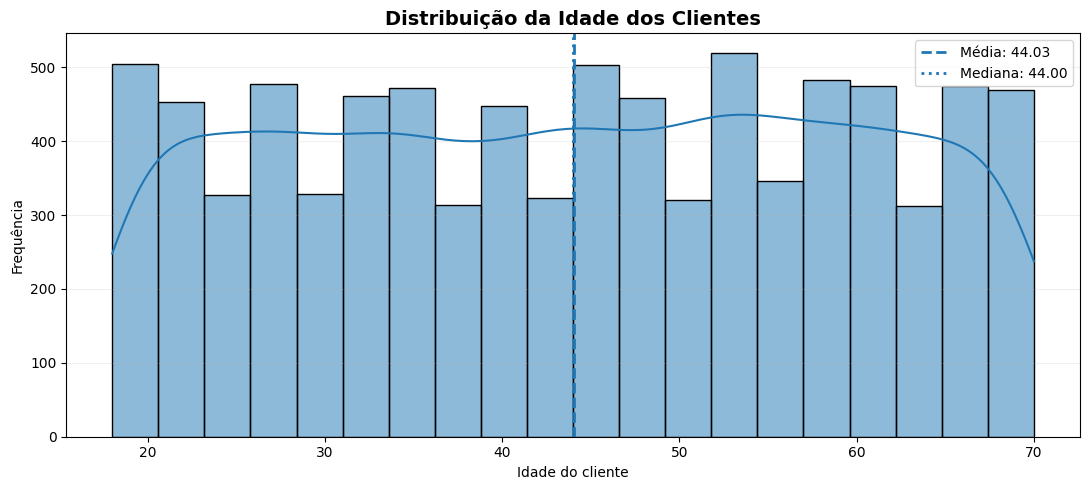


Variável 'Customer Satisfaction Rating':
count    2769.000000
mean        2.991333
std         1.407016
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: Customer Satisfaction Rating, dtype: float64


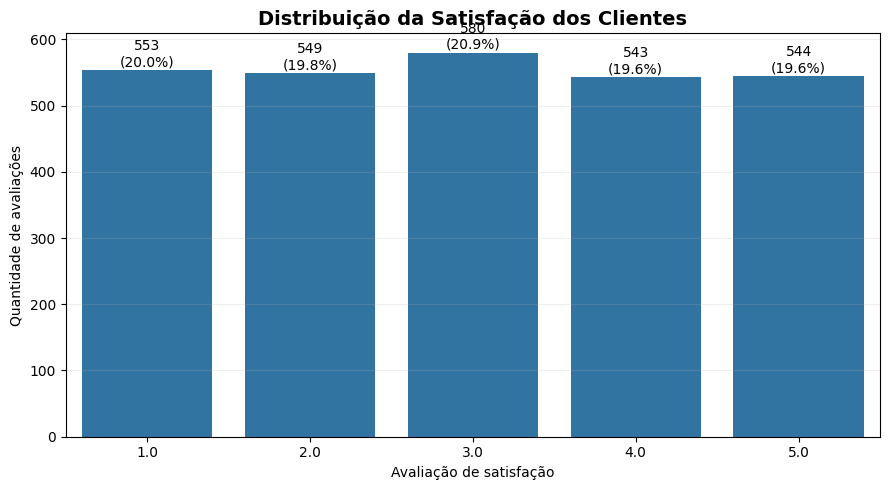


4. Boxplots das variáveis numéricas


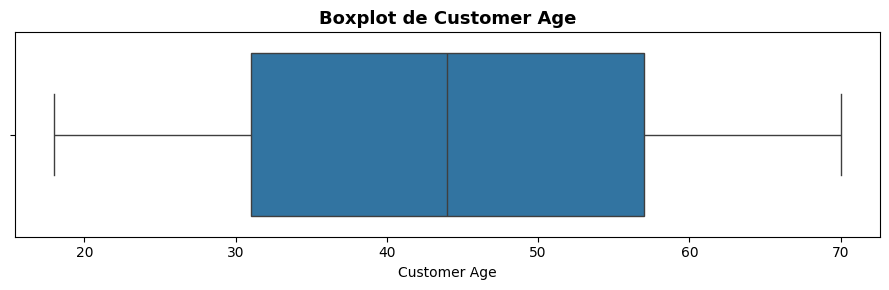

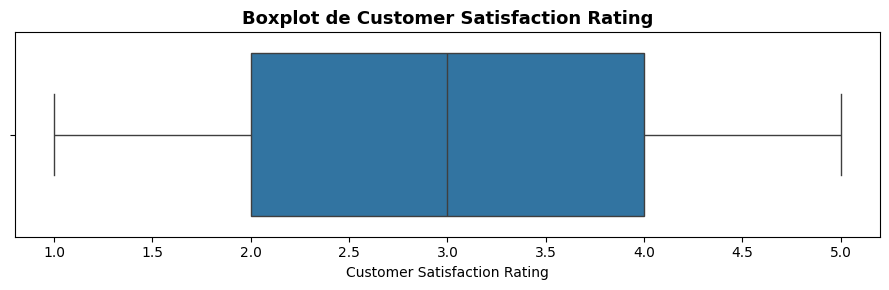

Ver Markdown


In [8]:


colunas_numericas = [
    "Customer Age",
    "Customer Satisfaction Rating"
]


print_formatado(
    "1. Média, mediana, mínimo e máximo"
)


for coluna in colunas_numericas:

    valores_validos = df[coluna].notna().sum()
    valores_ausentes = df[coluna].isna().sum()

    print(f"\nVariável '{coluna}':")

    print(
        f"Valores válidos: {valores_validos}"
    )

    print(
        f"Valores ausentes: {valores_ausentes}"
    )

    print(
        f"Média: {df[coluna].mean():.2f}"
    )

    print(
        f"Mediana: {df[coluna].median():.2f}"
    )

    print(
        f"Mínimo: {df[coluna].min():.2f}"
    )

    print(
        f"Máximo: {df[coluna].max():.2f}"
    )



print_formatado(
    "2. Quartis, variância e desvio-padrão"
)


for coluna in colunas_numericas:

    q1 = df[coluna].quantile(0.25)
    q2 = df[coluna].quantile(0.50)
    q3 = df[coluna].quantile(0.75)

    print(f"\nVariável '{coluna}':")

    print(
        f"Q1 (25%): {q1:.2f}"
    )

    print(
        f"Q2 (50% - mediana): {q2:.2f}"
    )

    print(
        f"Q3 (75%): {q3:.2f}"
    )

    print(
        f"Variância: {df[coluna].var():.2f}"
    )

    print(
        f"Desvio-padrão: {df[coluna].std():.2f}"
    )

    print(
      f"Assimetria (skewness): "
      f"{df[coluna].skew():.4f}"
    )



print_formatado(
    "3. Distribuição dos valores"
)


for coluna in colunas_numericas:

    print(f"\nVariável '{coluna}':")

    print(
        df[coluna].describe()
    )



    if coluna == "Customer Satisfaction Rating":

        frequencia = (
            df[coluna]
            .dropna()
            .value_counts()
            .sort_index()
        )

        percentual = (
            frequencia /
            frequencia.sum()
            * 100
        )


        plt.figure(figsize=(9, 5))

        ax = sns.barplot(
            x=frequencia.index.astype(str),
            y=frequencia.values
        )


        plt.title(
            "Distribuição da Satisfação dos Clientes",
            fontsize=14,
            fontweight="bold"
        )

        plt.xlabel(
            "Avaliação de satisfação"
        )

        plt.ylabel(
            "Quantidade de avaliações"
        )


        plt.grid(
            axis="y",
            alpha=0.2
        )



        for i, (quantidade, pct) in enumerate(
            zip(
                frequencia.values,
                percentual.values
            )
        ):

            ax.text(
                i,
                quantidade +
                max(frequencia.values) * 0.01,
                f"{quantidade}\n({pct:.1f}%)",
                ha="center",
                fontsize=10
            )


        plt.tight_layout()
        plt.show()



    else:

        media = df[coluna].mean()
        mediana = df[coluna].median()


        plt.figure(
            figsize=(11, 5)
        )


        sns.histplot(
            df[coluna].dropna(),
            bins=20,
            kde=True
        )



        plt.axvline(
            media,
            linestyle="--",
            linewidth=2,
            label=f"Média: {media:.2f}"
        )



        plt.axvline(
            mediana,
            linestyle=":",
            linewidth=2,
            label=f"Mediana: {mediana:.2f}"
        )


        plt.title(
            "Distribuição da Idade dos Clientes",
            fontsize=14,
            fontweight="bold"
        )

        plt.xlabel(
            "Idade do cliente"
        )

        plt.ylabel(
            "Frequência"
        )


        plt.legend()


        plt.grid(
            axis="y",
            alpha=0.2
        )


        plt.tight_layout()
        plt.show()


print_formatado(
    "4. Boxplots das variáveis numéricas"
)


for coluna in colunas_numericas:

    plt.figure(
        figsize=(9, 3)
    )

    sns.boxplot(
        x=df[coluna].dropna()
    )

    plt.title(
        f"Boxplot de {coluna}",
        fontsize=13,
        fontweight="bold"
    )

    plt.xlabel(
        coluna
    )

    plt.tight_layout()
    plt.show()

print("Ver Markdown")

### 1.5.1 — Análise univariada das variáveis numéricas

#### `Customer Age`

A variável `Customer Age` possui **8.469 valores válidos**, sem dados ausentes.

As idades variam entre **18 e 70 anos**, apresentando:

- média: **44,03 anos**;
- mediana: **44 anos**;
- primeiro quartil (Q1): **31 anos**;
- terceiro quartil (Q3): **57 anos**;
- desvio-padrão: **15,30 anos**;
- assimetria (skewness): **-0,0172**.

A proximidade entre média e mediana e o valor de assimetria muito próximo de zero indicam uma distribuição aproximadamente simétrica em torno do centro.

Entretanto, a simetria observada não é suficiente para concluir que a variável segue uma distribuição normal. Essa hipótese será avaliada formalmente na etapa de análise de outliers e normalidade.

Os valores mínimo e máximo também estão dentro de limites plausíveis para idade, não sendo identificados nesta análise valores evidentemente impossíveis.

#### `Customer Satisfaction Rating`

A variável `Customer Satisfaction Rating` possui **2.769 valores válidos** e **5.700 valores ausentes**.

Os valores válidos variam entre **1 e 5**, correspondendo à escala esperada de satisfação.

As principais medidas são:

- média: **2,99**;
- mediana: **3,00**;
- primeiro quartil (Q1): **2,00**;
- terceiro quartil (Q3): **4,00**;
- desvio-padrão: **1,41**;
- assimetria (skewness): **0,0084**.

A média praticamente igual à mediana e a assimetria próxima de zero mostram uma distribuição bastante equilibrada ao redor do valor 3.

Contudo, `Customer Satisfaction Rating` é uma variável discreta e limitada à escala de 1 a 5. Portanto, uma distribuição visualmente simétrica não deve ser interpretada automaticamente como distribuição normal.

Além disso, apenas os tickets que possuem avaliação preenchida podem participar de análises envolvendo satisfação. Esse subconjunto contém **2.769 registros**, e sua relação com o estado do atendimento deve ser considerada para evitar interpretações incorretas.

#### Síntese

A análise univariada numérica mostra que:

1. `Customer Age` não possui valores ausentes e apresenta distribuição aproximadamente simétrica;
2. `Customer Satisfaction Rating` está limitada corretamente à escala de 1 a 5;
3. ambas apresentam assimetria próxima de zero;
4. nenhuma conclusão sobre normalidade será tomada apenas com base na assimetria ou nos gráficos;
5. a normalidade será testada formalmente antes da escolha do método para identificação de outliers;
6. os valores ausentes de satisfação permanecem preservados devido ao seu significado no processo de atendimento.

Essas características serão posteriormente relacionadas à variável-alvo `Ticket Type` para avaliar se possuem potencial informativo para a classificação de intenção.

### **Variáveis categóricas**


1. Quantidade de categorias

Quantidade de categorias únicas por variável:
Product Purchased    42
Ticket Subject       16
Ticket Type           5
Ticket Channel        4
Ticket Priority       4
Customer Gender       3
Ticket Status         3
dtype: int64

Valores ausentes:
Customer Gender               : 0
Product Purchased             : 0
Ticket Type                   : 0
Ticket Subject                : 0
Ticket Status                 : 0
Ticket Priority               : 0
Ticket Channel                : 0

2. Frequência absoluta e relativa

Variável: Customer Gender


,Quantidade,Percentual (%)
Customer Gender,,
Male,2896,34.20
Female,2887,34.09
Other,2686,31.72


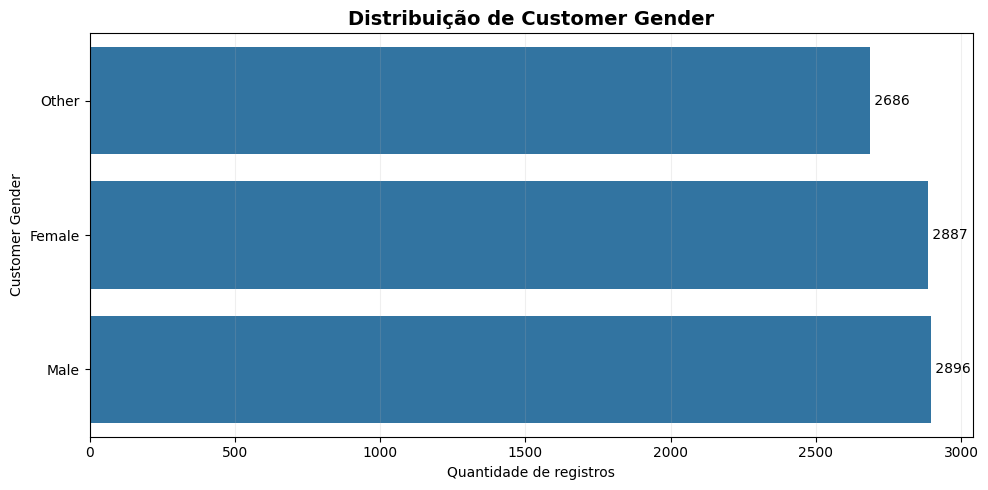


Variável: Product Purchased


,Quantidade,Percentual (%)
Product Purchased,,
Canon EOS,240,2.83
GoPro Hero,228,2.69
Nest Thermostat,225,2.66
Philips Hue Lights,221,2.61
Amazon Echo,221,2.61
LG Smart TV,219,2.59
Sony Xperia,217,2.56
Roomba Robot Vacuum,216,2.55
Apple AirPods,213,2.52


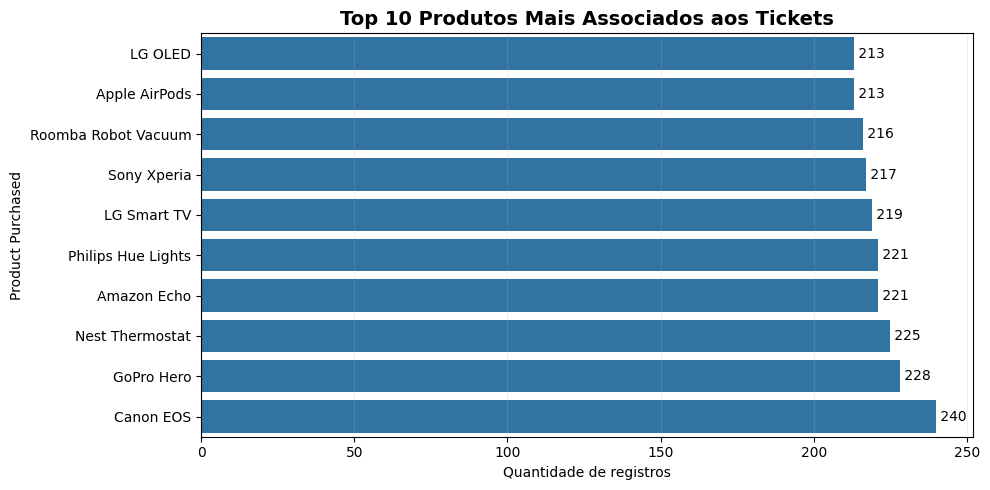


Variável: Ticket Type


,Quantidade,Percentual (%)
Ticket Type,,
Refund request,1752,20.69
Technical issue,1747,20.63
Cancellation request,1695,20.01
Product inquiry,1641,19.38
Billing inquiry,1634,19.29


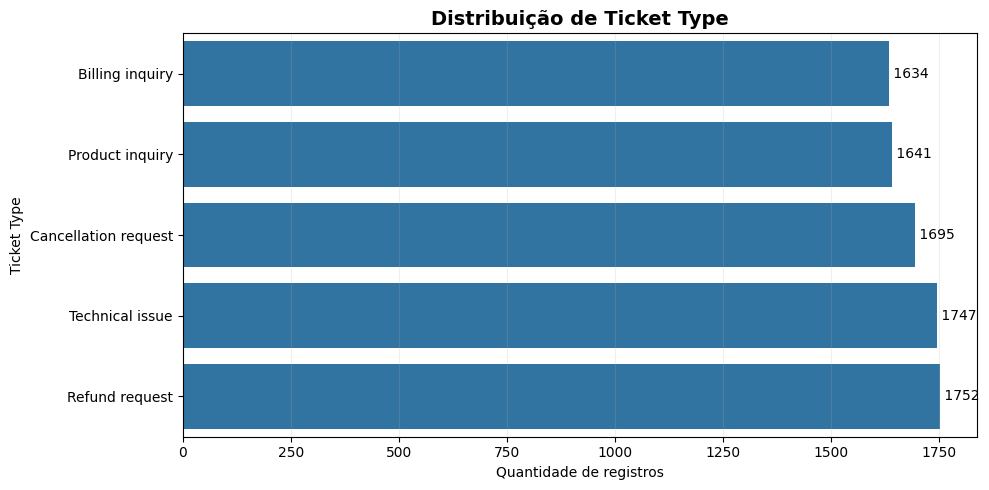


Variável: Ticket Subject


,Quantidade,Percentual (%)
Ticket Subject,,
Refund request,576,6.80
Software bug,574,6.78
Product compatibility,567,6.70
Delivery problem,561,6.62
Hardware issue,547,6.46
Battery life,542,6.40
Network problem,539,6.36
Installation support,530,6.26
Product setup,529,6.25


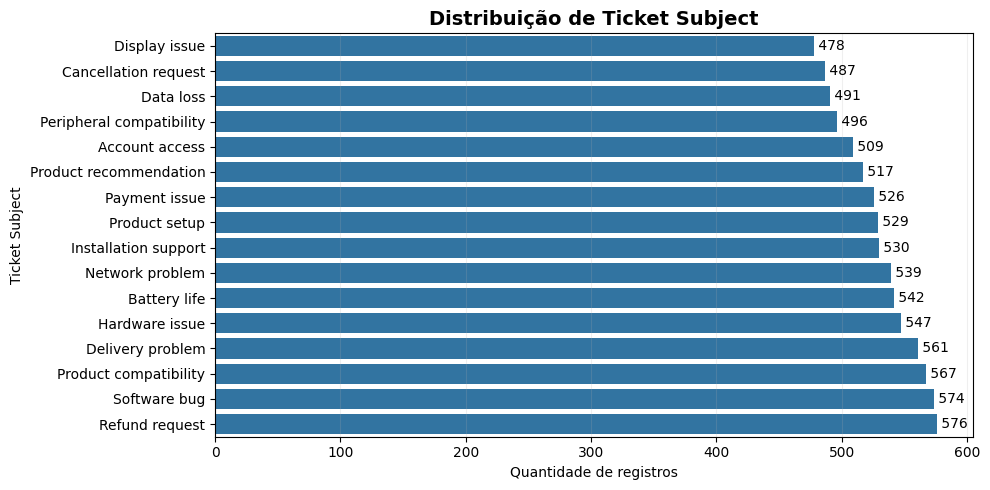


Variável: Ticket Status


,Quantidade,Percentual (%)
Ticket Status,,
Pending Customer Response,2881,34.02
Open,2819,33.29
Closed,2769,32.70


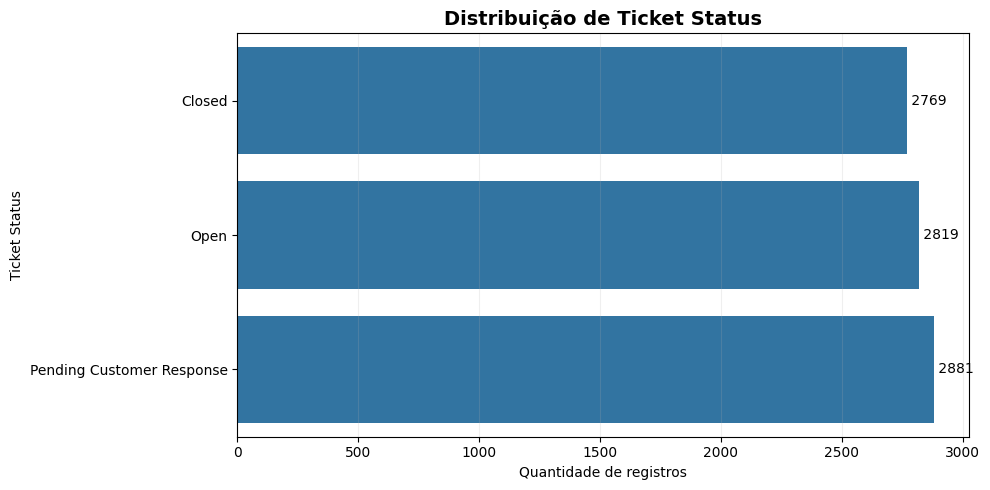


Variável: Ticket Priority


,Quantidade,Percentual (%)
Ticket Priority,,
Medium,2192,25.88
Critical,2129,25.14
High,2085,24.62
Low,2063,24.36


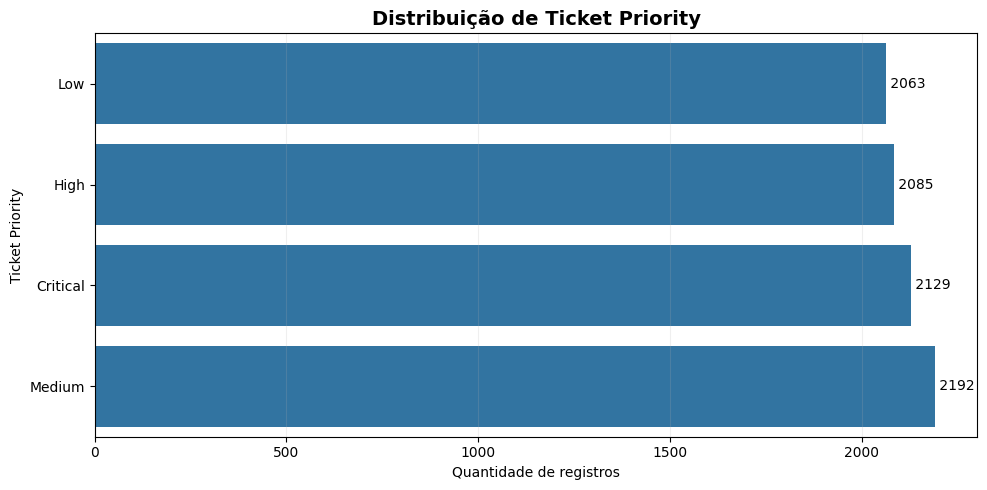


Variável: Ticket Channel


,Quantidade,Percentual (%)
Ticket Channel,,
Email,2143,25.30
Phone,2132,25.17
Social media,2121,25.04
Chat,2073,24.48


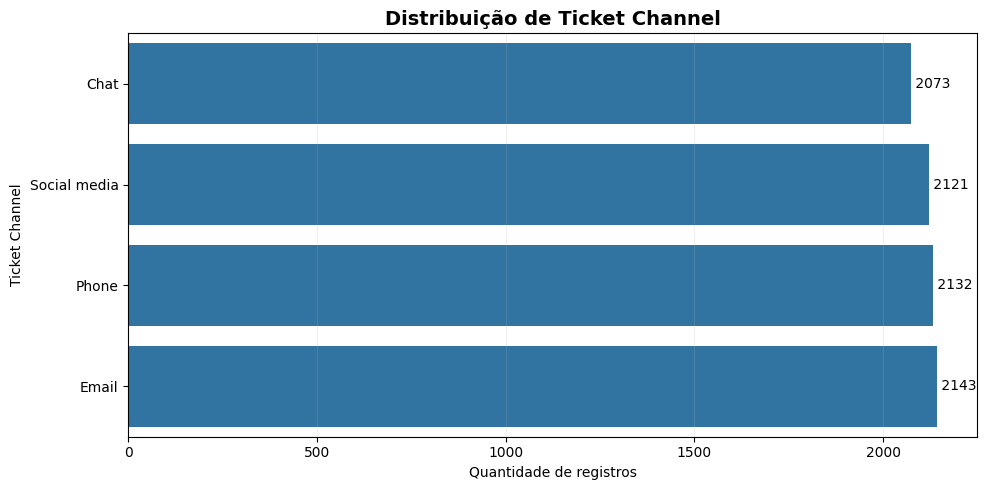


3. Categoria mais frequente

Categoria mais frequente da variável 'Customer Gender':
Categoria: Male
Quantidade: 2896
Percentual: 34.20%

Categoria mais frequente da variável 'Product Purchased':
Categoria: Canon EOS
Quantidade: 240
Percentual: 2.83%

Categoria mais frequente da variável 'Ticket Type':
Categoria: Refund request
Quantidade: 1752
Percentual: 20.69%

Categoria mais frequente da variável 'Ticket Subject':
Categoria: Refund request
Quantidade: 576
Percentual: 6.80%

Categoria mais frequente da variável 'Ticket Status':
Categoria: Pending Customer Response
Quantidade: 2881
Percentual: 34.02%

Categoria mais frequente da variável 'Ticket Priority':
Categoria: Medium
Quantidade: 2192
Percentual: 25.88%

Categoria mais frequente da variável 'Ticket Channel':
Categoria: Email
Quantidade: 2143
Percentual: 25.30%

4. Resumo da distribuição das variáveis categóricas

Customer Gender:
Quantidade de categorias: 3
Categoria mais frequente: Male
Frequência da maior: 2896 (34.20%)
Cate

,Quantidade,Percentual (%)
Ticket Type,,
Refund request,1752,20.69
Technical issue,1747,20.63
Cancellation request,1695,20.01
Product inquiry,1641,19.38
Billing inquiry,1634,19.29



Maior classe: 1752 registros
Menor classe: 1634 registros
Razão entre maior e menor classe: 1.072

Conclusão: Ticket Type apresenta distribuição relativamente equilibrada entre as classes.
Ver Markdown


In [9]:
colunas_categoricas = [
    "Customer Gender",
    "Product Purchased",
    "Ticket Type",
    "Ticket Subject",
    "Ticket Status",
    "Ticket Priority",
    "Ticket Channel"
]


print_formatado(
    "1. Quantidade de categorias"
)

print(
    "\nQuantidade de categorias únicas por variável:"
)

quantidade_categorias = (
    df[colunas_categoricas]
    .nunique()
    .sort_values(ascending=False)
)

print(quantidade_categorias)


print("\nValores ausentes:")

for coluna in colunas_categoricas:

    ausentes = df[coluna].isna().sum()

    print(
        f"{coluna:<30}: "
        f"{ausentes}"
    )


print_formatado(
    "2. Frequência absoluta e relativa"
)

for coluna in colunas_categoricas:

    print(f"\n{'=' * 80}")
    print(f"Variável: {coluna}")
    print(f"{'=' * 80}")

    frequencia_absoluta = (
        df[coluna]
        .value_counts(
            dropna=False
        )
    )

    frequencia_relativa = (
        df[coluna]
        .value_counts(
            normalize=True,
            dropna=False
        )
        .mul(100)
        .round(2)
    )

    resumo_frequencias = pd.DataFrame(
        {
            "Quantidade": frequencia_absoluta,
            "Percentual (%)": frequencia_relativa
        }
    )

    display(
        resumo_frequencias
    )


    dados_grafico = (
        frequencia_absoluta
        .sort_values(
            ascending=False
        )
    )


    if coluna == "Product Purchased":

        dados_grafico = (
            dados_grafico
            .head(10)
            .sort_values(
                ascending=True
            )
        )

        titulo = (
            "Top 10 Produtos Mais Associados aos Tickets"
        )

    else:

        dados_grafico = (
            dados_grafico
            .sort_values(
                ascending=True
            )
        )

        titulo = (
            f"Distribuição de {coluna}"
        )


    plt.figure(
        figsize=(10, 5)
    )

    ax = sns.barplot(
        x=dados_grafico.values,
        y=dados_grafico.index.astype(str)
    )

    plt.title(
        titulo,
        fontsize=14,
        fontweight="bold"
    )

    plt.xlabel(
        "Quantidade de registros"
    )

    plt.ylabel(
        coluna
    )

    plt.grid(
        axis="x",
        alpha=0.2
    )


    for i, valor in enumerate(
        dados_grafico.values
    ):

        plt.text(
            valor,
            i,
            f" {valor}",
            va="center",
            fontsize=10
        )


    plt.tight_layout()
    plt.show()


print_formatado(
    "3. Categoria mais frequente"
)

for coluna in colunas_categoricas:

    frequencias = (
        df[coluna]
        .value_counts(
            dropna=False
        )
    )

    categoria_mais_frequente = (
        frequencias.index[0]
    )

    quantidade = (
        frequencias.iloc[0]
    )

    percentual = (
        quantidade
        / len(df)
        * 100
    )

    print(
        f"\nCategoria mais frequente "
        f"da variável '{coluna}':"
    )

    print(
        f"Categoria: "
        f"{categoria_mais_frequente}"
    )

    print(
        f"Quantidade: "
        f"{quantidade}"
    )

    print(
        f"Percentual: "
        f"{percentual:.2f}%"
    )


print_formatado(
    "4. Resumo da distribuição das variáveis categóricas"
)

for coluna in colunas_categoricas:

    frequencias = (
        df[coluna]
        .value_counts()
    )

    categoria_maior = (
        frequencias.index[0]
    )

    quantidade_maior = (
        frequencias.iloc[0]
    )

    percentual_maior = (
        quantidade_maior
        / len(df)
        * 100
    )

    categoria_menor = (
        frequencias.index[-1]
    )

    quantidade_menor = (
        frequencias.iloc[-1]
    )

    percentual_menor = (
        quantidade_menor
        / len(df)
        * 100
    )

    print(
        f"\n{coluna}:"
    )

    print(
        f"Quantidade de categorias: "
        f"{df[coluna].nunique()}"
    )

    print(
        f"Categoria mais frequente: "
        f"{categoria_maior}"
    )

    print(
        f"Frequência da maior: "
        f"{quantidade_maior} "
        f"({percentual_maior:.2f}%)"
    )

    print(
        f"Categoria menos frequente: "
        f"{categoria_menor}"
    )

    print(
        f"Frequência da menor: "
        f"{quantidade_menor} "
        f"({percentual_menor:.2f}%)"
    )


print_formatado(
    "5. Distribuição da variável-alvo Ticket Type"
)

ticket_type_contagem = (
    df["Ticket Type"]
    .value_counts()
)

ticket_type_percentual = (
    df["Ticket Type"]
    .value_counts(
        normalize=True
    )
    .mul(100)
    .round(2)
)

resumo_ticket_type = pd.DataFrame(
    {
        "Quantidade": ticket_type_contagem,
        "Percentual (%)": ticket_type_percentual
    }
)

display(
    resumo_ticket_type
)


maior_classe = (
    ticket_type_contagem.max()
)

menor_classe = (
    ticket_type_contagem.min()
)

razao_balanceamento = (
    maior_classe
    / menor_classe
)

print(
    f"\nMaior classe: {maior_classe} registros"
)

print(
    f"Menor classe: {menor_classe} registros"
)

print(
    f"Razão entre maior e menor classe: "
    f"{razao_balanceamento:.3f}"
)


if razao_balanceamento < 1.5:

    print(
        "\nConclusão: Ticket Type apresenta "
        "distribuição relativamente equilibrada entre as classes."
    )

else:

    print(
        "\nConclusão: Ticket Type apresenta "
        "diferenças relevantes de frequência entre as classes."
    )


print("Ver Markdown")

### 1.5.2 — Análise univariada das variáveis categóricas

A análise das variáveis categóricas permitiu verificar a frequência absoluta e relativa das categorias presentes no dataset, com atenção especial para `Ticket Type`, que será a variável-alvo do problema de classificação desenvolvido no TP3.

#### Variável-alvo `Ticket Type`

A variável `Ticket Type` possui cinco classes:

- `Refund request`: **1.752 registros (20,69%)**;
- `Technical issue`: **1.747 registros (20,63%)**;
- `Cancellation request`: **1.695 registros (20,01%)**;
- `Product inquiry`: **1.641 registros (19,38%)**;
- `Billing inquiry`: **1.634 registros (19,29%)**.

A maior classe possui 1.752 registros e a menor possui 1.634, produzindo uma razão de aproximadamente **1,072** entre elas.

Portanto, a variável-alvo apresenta uma distribuição **relativamente equilibrada**, sem evidência de desbalanceamento severo entre as cinco classes.

Essa característica é positiva para a futura etapa de modelagem, pois reduz o risco de um modelo favorecer excessivamente uma classe apenas devido à sua maior frequência.

Ainda assim, na etapa de classificação deverão ser utilizadas métricas adequadas para problemas multiclasse, e não apenas a acurácia.

#### Demais variáveis categóricas

As distribuições de `Customer Gender`, `Product Purchased`, `Ticket Subject`, `Ticket Status`, `Ticket Priority` e `Ticket Channel` também foram avaliadas por meio de frequências absolutas, relativas e representações gráficas.

`Product Purchased` apresenta maior quantidade de categorias que as demais variáveis, razão pela qual a visualização foi limitada aos dez produtos mais frequentes, mantendo a tabela completa para análise.

`Ticket Subject` possui apenas 16 categorias e pode ser particularmente relevante para o problema de classificação, pois representa diretamente o assunto declarado no atendimento. Sua relação com `Ticket Type` será investigada posteriormente na análise multivariada.

Variáveis como `Ticket Status` devem ser interpretadas com cautela para o futuro modelo, pois representam informações associadas ao andamento do atendimento e podem não estar disponíveis no momento em que a intenção inicial do ticket precisa ser prevista.

#### Conclusão

A análise categórica indica que:

1. `Ticket Type` possui cinco classes aproximadamente balanceadas;
2. não existe, neste momento, necessidade evidente de técnicas de rebalanceamento da variável-alvo;
3. `Ticket Subject` merece atenção especial como possível variável preditora;
4. `Product Purchased`, `Ticket Channel`, `Ticket Priority` e outras variáveis serão comparadas posteriormente com `Ticket Type`;
5. variáveis geradas após a abertura do ticket deverão ser avaliadas quanto ao risco de vazamento de informação (*data leakage*).



1.5.3 Análise univariada das variáveis textuais

1. Resumo das variáveis textuais

Variável: Ticket Subject
Valores válidos: 8469
Valores ausentes: 0
Valores únicos: 16

Variável: Ticket Description
Valores válidos: 8469
Valores ausentes: 0
Valores únicos: 8077

Variável: Resolution
Valores válidos: 2769
Valores ausentes: 5700
Valores únicos: 2769

2. Estrutura de Ticket Description


,count,mean,std,min,25%,50%,75%,max
Description Char Count,8469.0,289.821939,43.593954,151.0,273.0,298.0,318.0,397.0
Description Word Count,8469.0,46.467352,8.461730,21.0,43.0,49.0,52.0,63.0
Description Placeholder Count,8469.0,1.754044,0.753568,1.0,1.0,2.0,2.0,7.0



3. Distribuição das características textuais


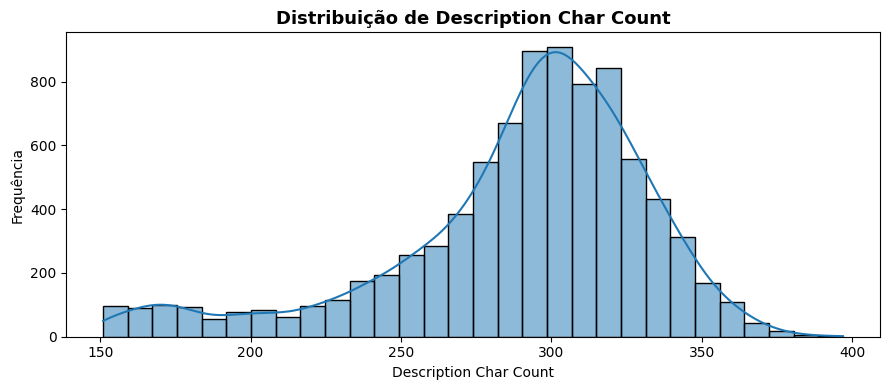

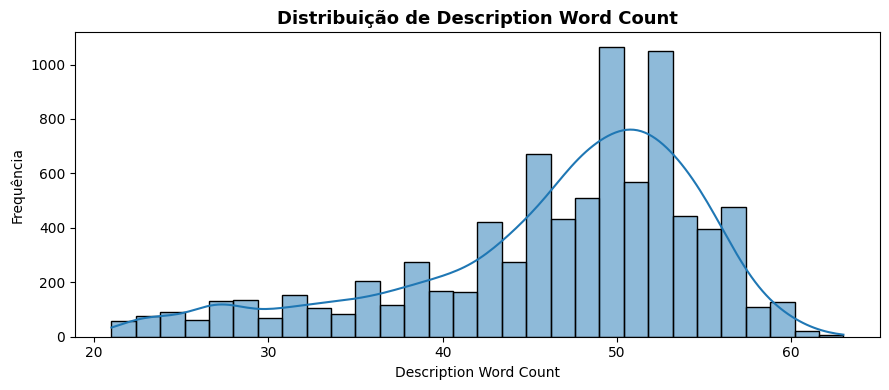

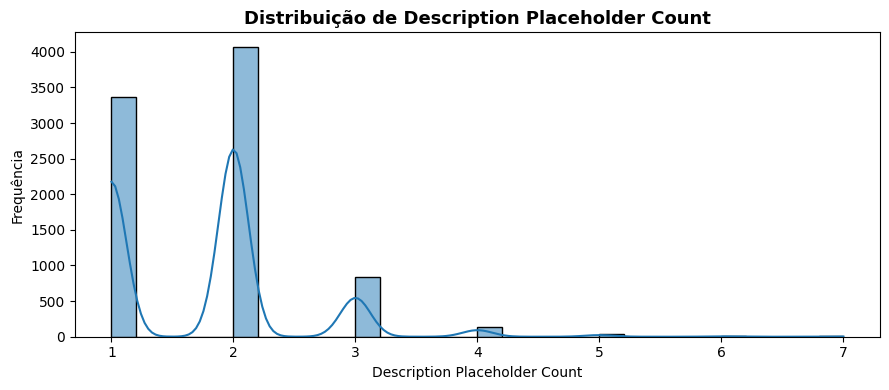


4. Boxplots das características textuais


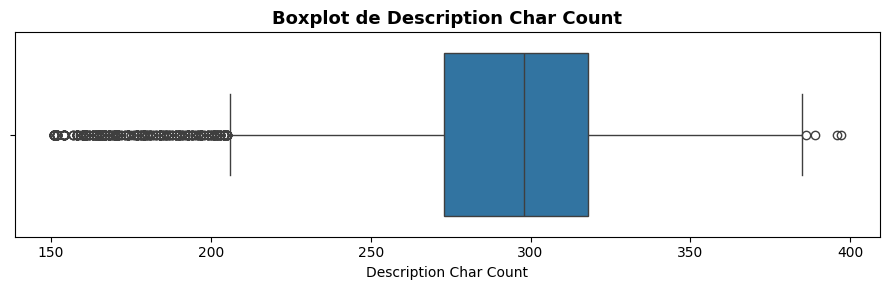

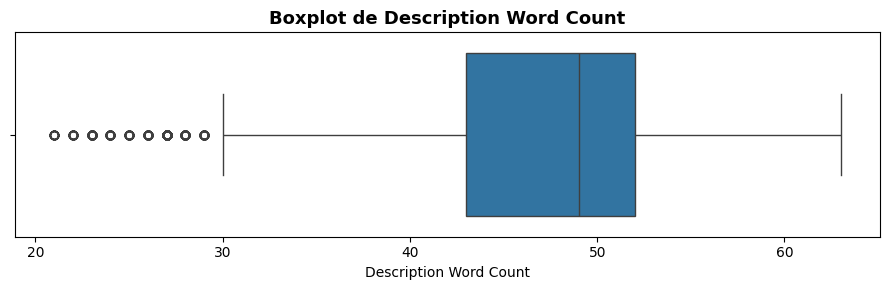

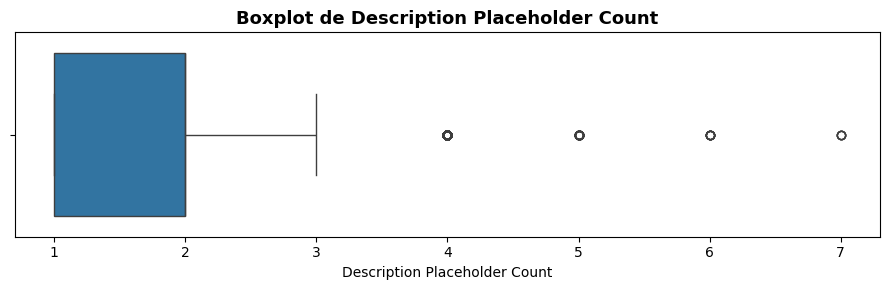


5. Ticket Subjects mais frequentes


,Ticket Subject,Quantidade,Percentual (%)
0,Refund request,576,6.80
1,Software bug,574,6.78
2,Product compatibility,567,6.70
3,Delivery problem,561,6.62
4,Hardware issue,547,6.46
5,Battery life,542,6.40
6,Network problem,539,6.36
7,Installation support,530,6.26
8,Product setup,529,6.25
9,Payment issue,526,6.21



6. Repetição de Ticket Description
Ocorrências duplicadas: 392
Percentual de ocorrências duplicadas: 4.63%

Descrições mais frequentes:


,Ticket Description,Quantidade
0,I'm having an issue with the {product_purchase...,25
1,I'm having an issue with the {product_purchase...,25
2,I'm having an issue with the {product_purchase...,25
3,I'm having an issue with the {product_purchase...,24
4,I'm having an issue with the {product_purchase...,24
5,I'm having an issue with the {product_purchase...,23
6,I'm having an issue with the {product_purchase...,20
7,I'm having an issue with the {product_purchase...,20
8,I'm having an issue with the {product_purchase...,17
9,I'm having an issue with the {product_purchase...,17



7. Placeholders em Ticket Description
Total de placeholders encontrados: 14855
Média por ticket: 1.75
Mediana por ticket: 2.00
Máximo em um ticket: 7
Tickets com mais de um placeholder: 5102 (60.24%)

8. Placeholders mais frequentes


,Placeholder,Quantidade
0,{product_purchased},13893
1,{error_message},472
2,{product_id},56
3,{product_name},38
4,{product},19
5,{product_price},14
6,{name},10
7,{product_purchases},7
8,{id},7
9,{product_purchasing},6


Ver Markdown


In [10]:
# ============================================================
# 1.5.3 — ANÁLISE UNIVARIADA DAS VARIÁVEIS TEXTUAIS
# ============================================================

print_formatado(
    "1.5.3 Análise univariada das variáveis textuais"
)


# ------------------------------------------------------------
# 1. Resumo das variáveis textuais
# ------------------------------------------------------------

print_formatado(
    "1. Resumo das variáveis textuais"
)

colunas_textuais_analise = [
    "Ticket Subject",
    "Ticket Description",
    "Resolution"
]

for coluna in colunas_textuais_analise:

    valores_validos = (
        df[coluna]
        .notna()
        .sum()
    )

    valores_ausentes = (
        df[coluna]
        .isna()
        .sum()
    )

    valores_unicos = (
        df[coluna]
        .nunique(
            dropna=True
        )
    )

    print(
        f"\nVariável: {coluna}"
    )

    print(
        f"Valores válidos: "
        f"{valores_validos}"
    )

    print(
        f"Valores ausentes: "
        f"{valores_ausentes}"
    )

    print(
        f"Valores únicos: "
        f"{valores_unicos}"
    )


# ------------------------------------------------------------
# 2. Estrutura de Ticket Description
# ------------------------------------------------------------

print_formatado(
    "2. Estrutura de Ticket Description"
)

variaveis_descricao = [
    "Description Char Count",
    "Description Word Count",
    "Description Placeholder Count"
]

display(
    df[
        variaveis_descricao
    ].describe().T
)


# ------------------------------------------------------------
# 3. Histogramas das características textuais
# ------------------------------------------------------------

print_formatado(
    "3. Distribuição das características textuais"
)

for coluna in variaveis_descricao:

    plt.figure(
        figsize=(9, 4)
    )

    sns.histplot(
        data=df,
        x=coluna,
        bins=30,
        kde=True
    )

    plt.title(
        f"Distribuição de {coluna}",
        fontsize=13,
        fontweight="bold"
    )

    plt.xlabel(
        coluna
    )

    plt.ylabel(
        "Frequência"
    )

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 4. Boxplots das características textuais
# ------------------------------------------------------------

print_formatado(
    "4. Boxplots das características textuais"
)

for coluna in variaveis_descricao:

    plt.figure(
        figsize=(9, 3)
    )

    sns.boxplot(
        x=df[coluna]
    )

    plt.title(
        f"Boxplot de {coluna}",
        fontsize=13,
        fontweight="bold"
    )

    plt.xlabel(
        coluna
    )

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 5. Assuntos de tickets mais frequentes
# ------------------------------------------------------------

print_formatado(
    "5. Ticket Subjects mais frequentes"
)

ticket_subject_resumo = (
    df["Ticket Subject"]
    .value_counts()
    .rename_axis(
        "Ticket Subject"
    )
    .reset_index(
        name="Quantidade"
    )
)

ticket_subject_resumo[
    "Percentual (%)"
] = (
    ticket_subject_resumo[
        "Quantidade"
    ]
    / len(df)
    * 100
).round(2)

display(
    ticket_subject_resumo
)


# ------------------------------------------------------------
# 6. Descrições duplicadas
# ------------------------------------------------------------

print_formatado(
    "6. Repetição de Ticket Description"
)

descricoes_duplicadas = (
    df["Ticket Description"]
    .duplicated()
    .sum()
)

percentual_duplicadas = (
    descricoes_duplicadas
    / len(df)
    * 100
)

print(
    f"Ocorrências duplicadas: "
    f"{descricoes_duplicadas}"
)

print(
    f"Percentual de ocorrências duplicadas: "
    f"{percentual_duplicadas:.2f}%"
)


print(
    "\nDescrições mais frequentes:"
)

display(
    df["Ticket Description"]
    .value_counts()
    .head(10)
    .rename_axis(
        "Ticket Description"
    )
    .reset_index(
        name="Quantidade"
    )
)


# ------------------------------------------------------------
# 7. Placeholders
# ------------------------------------------------------------

print_formatado(
    "7. Placeholders em Ticket Description"
)

total_placeholders = (
    df[
        "Description Placeholder Count"
    ]
    .sum()
)

media_placeholders = (
    df[
        "Description Placeholder Count"
    ]
    .mean()
)

mediana_placeholders = (
    df[
        "Description Placeholder Count"
    ]
    .median()
)

max_placeholders = (
    df[
        "Description Placeholder Count"
    ]
    .max()
)

tickets_multiplos = (
    df[
        "Description Placeholder Count"
    ]
    .gt(1)
    .sum()
)

percentual_multiplos = (
    tickets_multiplos
    / len(df)
    * 100
)

print(
    f"Total de placeholders encontrados: "
    f"{total_placeholders}"
)

print(
    f"Média por ticket: "
    f"{media_placeholders:.2f}"
)

print(
    f"Mediana por ticket: "
    f"{mediana_placeholders:.2f}"
)

print(
    f"Máximo em um ticket: "
    f"{max_placeholders}"
)

print(
    f"Tickets com mais de um placeholder: "
    f"{tickets_multiplos} "
    f"({percentual_multiplos:.2f}%)"
)


# ------------------------------------------------------------
# 8. Tipos de placeholders mais frequentes
# ------------------------------------------------------------

print_formatado(
    "8. Placeholders mais frequentes"
)

placeholders_textuais = (
    df["Ticket Description"]
    .fillna("")
    .str.findall(
        r"\{[^{}]+\}"
    )
    .explode()
    .dropna()
    .str.lower()
    .str.strip()
    .value_counts()
    .head(20)
)

display(
    placeholders_textuais
    .rename_axis(
        "Placeholder"
    )
    .reset_index(
        name="Quantidade"
    )
)


print("Ver Markdown")

### 1.5.3 — Análise univariada das variáveis textuais

A análise textual foi realizada sobre `Ticket Subject`, `Ticket Description` e `Resolution`, além das características derivadas do conteúdo de `Ticket Description`.

#### `Ticket Subject`

A variável `Ticket Subject` possui:

- **8.469 valores válidos**;
- **0 valores ausentes**;
- **16 valores únicos**.

Apesar de representar informação textual, sua baixa cardinalidade permite tratá-la também como uma variável categórica.

Essa variável pode ser especialmente relevante para a futura classificação de `Ticket Type`, pois o assunto informado no ticket pode conter sinais diretos sobre a intenção do cliente.

Sua relação com a variável-alvo será investigada na análise multivariada.

#### `Ticket Description`

`Ticket Description` possui:

- **8.469 valores válidos**;
- **0 valores ausentes**;
- **8.077 textos únicos**.

Foram identificadas **392 ocorrências duplicadas**, correspondendo a aproximadamente **4,63%** do dataset.

Isso indica que algumas descrições aparecem mais de uma vez, enquanto a grande maioria dos textos é distinta.

As descrições duplicadas não foram removidas automaticamente, pois a repetição de um texto não significa necessariamente que o registro seja incorreto. Entretanto, essa característica deverá ser considerada posteriormente na separação entre treino e teste para reduzir o risco de vazamento de informação entre conjuntos.

#### Estrutura das descrições

A análise das características derivadas mostrou que `Ticket Description` possui, em média:

- aproximadamente **289,82 caracteres**;
- aproximadamente **46,47 palavras**;
- aproximadamente **1,75 placeholders por ticket**.

As descrições variam entre **151 e 397 caracteres** e entre **21 e 63 palavras**.

Esses resultados indicam que os textos possuem comprimento relativamente consistente, embora exista variação suficiente para investigar se a extensão da descrição apresenta relação com `Ticket Type`.

#### Placeholders

Foram identificados **14.855 placeholders** nas descrições.

A quantidade de placeholders por ticket apresenta:

- média: **1,75**;
- mediana: **2**;
- máximo: **7**.

Além disso, **5.102 tickets (60,24%)** possuem mais de um placeholder.

Todos os tickets possuem pelo menos um placeholder.

Os placeholders parecem fazer parte da estrutura utilizada para gerar ou anonimizar os textos do dataset. Por esse motivo, eles não foram removidos automaticamente durante a preparação.

Essa característica merece atenção para a futura modelagem, pois determinados tipos de placeholder podem fornecer pistas artificiais sobre a classe do ticket. Caso estejam fortemente associados a `Ticket Type`, o modelo poderia aprender padrões estruturais do dataset em vez de compreender efetivamente o conteúdo textual.

#### `Resolution`

A variável `Resolution` possui:

- **2.769 valores válidos**;
- **5.700 valores ausentes**;
- **2.769 textos únicos** entre os valores preenchidos.

Isso significa que todas as resoluções preenchidas são distintas.

Entretanto, `Resolution` representa uma informação produzida durante ou após o tratamento do ticket. Por esse motivo, embora possa ser analisada no EDA, ela não deve ser considerada automaticamente como variável preditora para a classificação inicial de `Ticket Type`, pois existe risco de *data leakage*.

#### Conclusão da análise textual

A análise univariada textual indica que:

1. `Ticket Description` é a principal fonte de texto livre disponível antes ou durante a abertura do ticket;
2. a maior parte das descrições é única, embora existam 392 ocorrências duplicadas;
3. os textos apresentam comprimento relativamente consistente;
4. os placeholders estão presentes em todas as descrições e são bastante frequentes;
5. a influência dos placeholders sobre `Ticket Type` deverá ser investigada antes da modelagem;
6. `Ticket Subject`, apesar de categórica, pode ser uma variável altamente informativa para a classificação;
7. `Resolution` possui risco de vazamento de informação e não deve ser usada como preditora sem considerar o momento em que essa informação se torna disponível.

### Conclusão da análise univariada

A análise univariada cobriu variáveis numéricas, categóricas e textuais.

Os principais resultados foram:

- `Customer Age` apresenta distribuição aproximadamente simétrica e não possui valores ausentes;
- `Customer Satisfaction Rating` possui valores válidos apenas para 2.769 tickets;
- `Ticket Type`, variável-alvo do TP3, apresenta cinco classes relativamente equilibradas;
- não há evidência de desbalanceamento severo que exija tratamento imediato;
- `Ticket Subject` apresenta baixa cardinalidade e potencial relevância preditiva;
- `Ticket Description` contém informação textual rica, mas também padrões estruturais, como placeholders e descrições repetidas;
- variáveis produzidas após o início do atendimento devem ser avaliadas com cautela para evitar *data leakage*.

Esses resultados fornecem a base para a próxima etapa, a **1.6 — Análise multivariada**, na qual serão investigadas as relações entre as variáveis e, principalmente, sua associação com `Ticket Type`.

## 1.6 — Análise multivariada

### 1.6.1 — Relações entre variáveis numéricas


1. Estatísticas das variáveis numéricas por Ticket Type

Customer Age por Ticket Type


,count,mean,median,std,min,max
Ticket Type,,,,,,
Billing inquiry,1634,44.247,45.0,15.630,18,70
Cancellation request,1695,44.048,44.0,15.526,18,70
Product inquiry,1641,43.761,44.0,15.217,18,70
Refund request,1752,43.940,44.0,15.417,18,70
Technical issue,1747,44.137,44.0,14.709,18,70



Description Char Count por Ticket Type


,count,mean,median,std,min,max
Ticket Type,,,,,,
Billing inquiry,1634,291.162,299.0,42.427,151,397
Cancellation request,1695,289.153,297.0,44.100,151,389
Product inquiry,1641,291.176,299.0,42.670,151,375
Refund request,1752,289.843,298.0,43.335,151,396
Technical issue,1747,287.924,297.0,45.228,151,386



Description Word Count por Ticket Type


,count,mean,median,std,min,max
Ticket Type,,,,,,
Billing inquiry,1634,46.609,49.0,8.256,21,61
Cancellation request,1695,46.179,48.0,8.577,21,61
Product inquiry,1641,46.720,49.0,8.353,21,63
Refund request,1752,46.595,49.0,8.443,21,62
Technical issue,1747,46.250,48.0,8.653,21,62



Description Placeholder Count por Ticket Type


,count,mean,median,std,min,max
Ticket Type,,,,,,
Billing inquiry,1634,1.747,2.0,0.735,1,5
Cancellation request,1695,1.768,2.0,0.801,1,7
Product inquiry,1641,1.741,2.0,0.727,1,6
Refund request,1752,1.768,2.0,0.758,1,7
Technical issue,1747,1.745,2.0,0.744,1,6



2. Distribuição das variáveis numéricas por Ticket Type


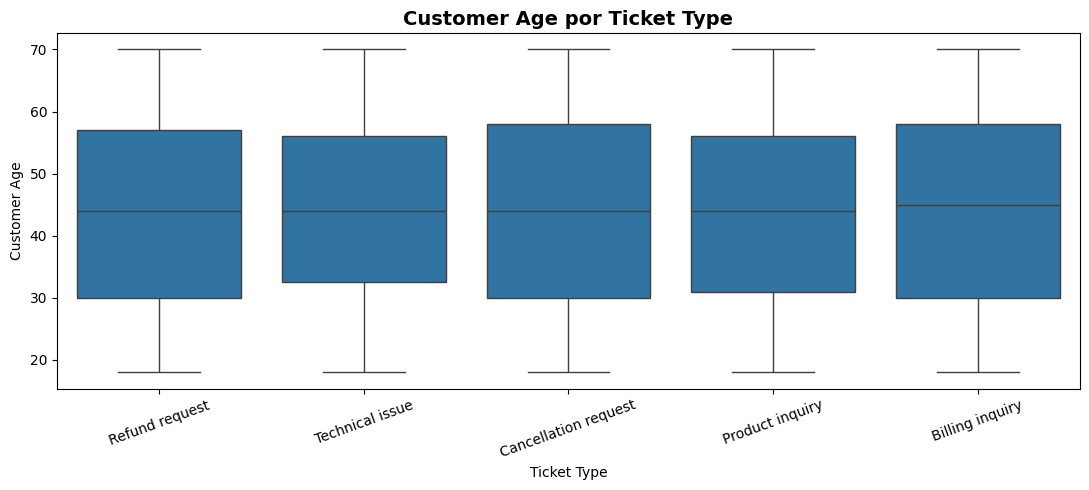

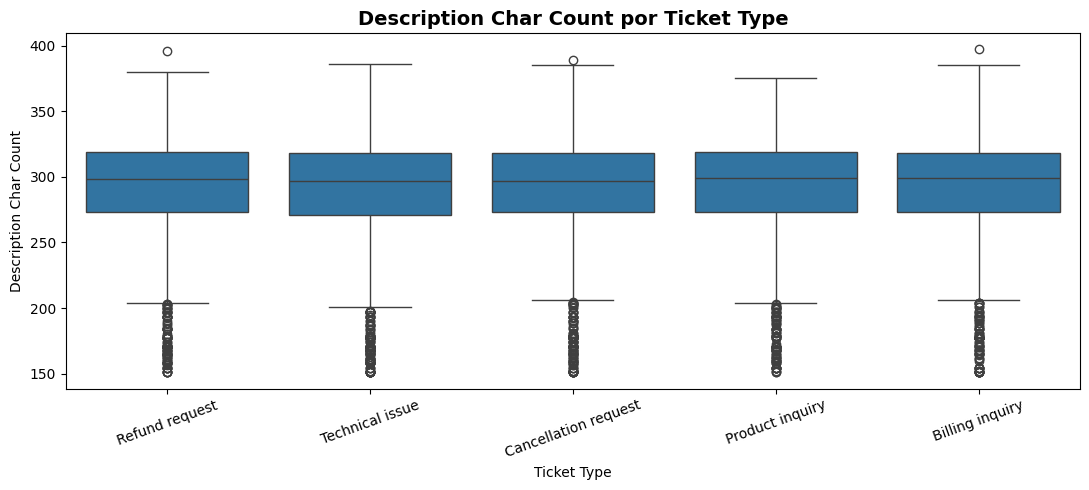

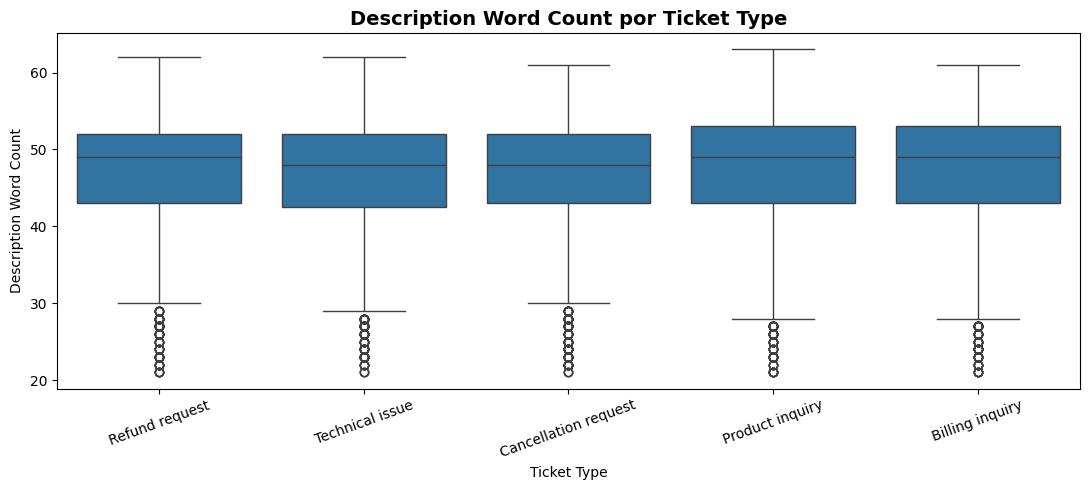

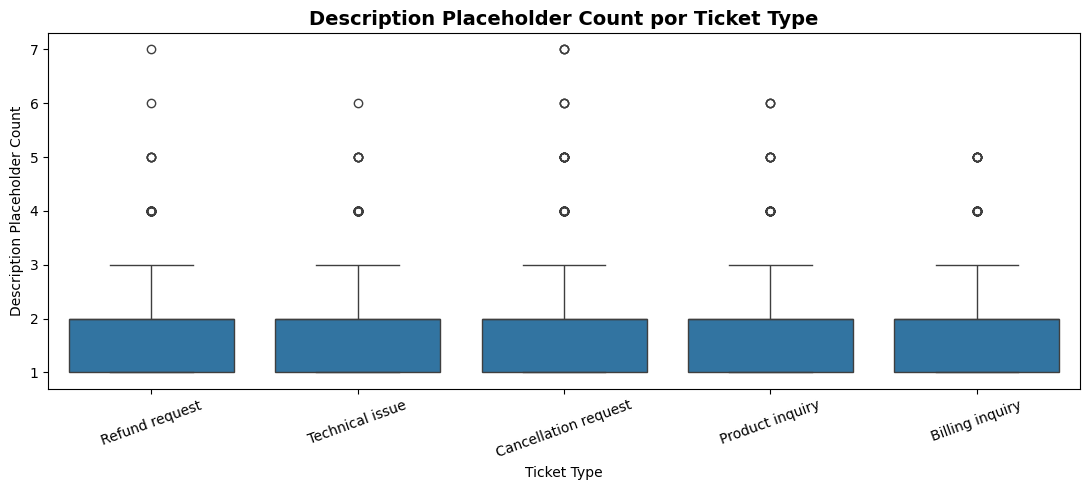


3. Correlação de Pearson entre variáveis numéricas independentes


,Customer Age,Description Char Count,Description Word Count,Description Placeholder Count
Customer Age,1.000,-0.006,-0.005,-0.008
Description Char Count,-0.006,1.000,0.913,0.149
Description Word Count,-0.005,0.913,1.000,0.023
Description Placeholder Count,-0.008,0.149,0.023,1.000


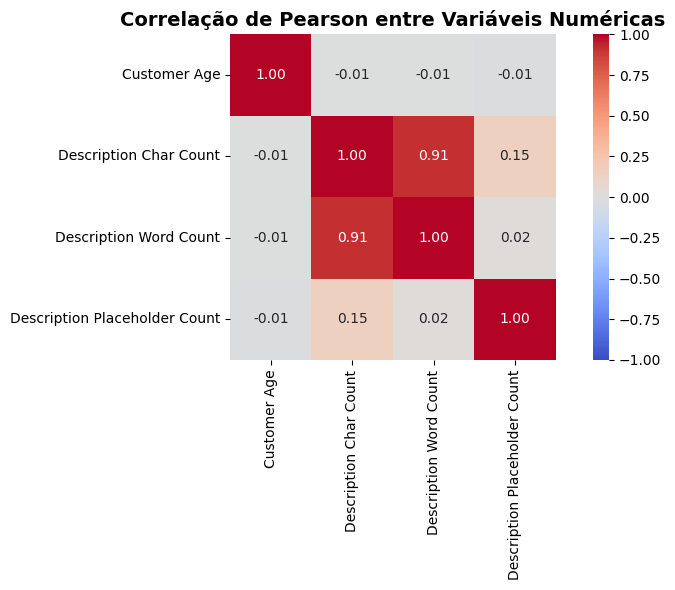


4. Correlação de Spearman entre variáveis numéricas independentes


,Customer Age,Description Char Count,Description Word Count,Description Placeholder Count
Customer Age,1.000,-0.013,-0.011,-0.005
Description Char Count,-0.013,1.000,0.859,0.191
Description Word Count,-0.011,0.859,1.000,0.064
Description Placeholder Count,-0.005,0.191,0.064,1.000


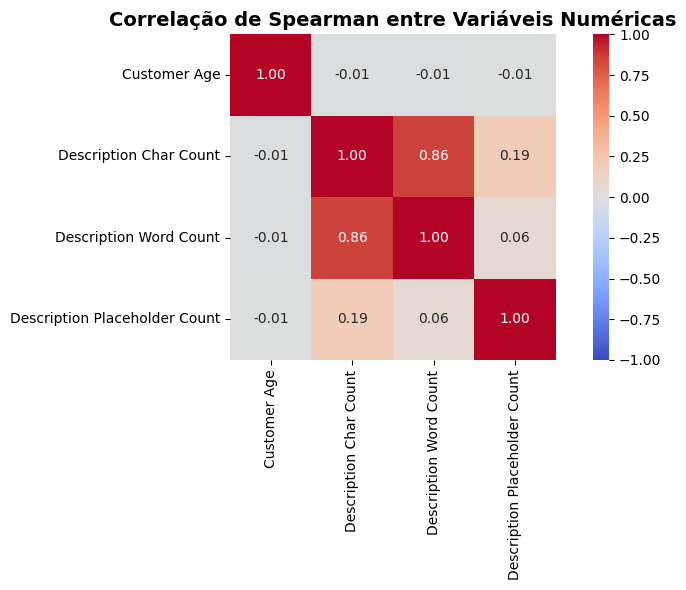


5. Possíveis relações redundantes entre variáveis numéricas


,Variável 1,Variável 2,Spearman
0,Description Char Count,Description Word Count,0.859



Foram encontrados pares com |correlação| >= 0.80.
Esses pares devem ser avaliados como possíveis variáveis redundantes.

6. Customer Satisfaction Rating por Ticket Type


,count,mean,median,std
Ticket Type,,,,
Billing inquiry,544,3.028,3.0,1.404
Cancellation request,516,3.029,3.0,1.434
Product inquiry,533,3.017,3.0,1.366
Refund request,596,2.935,3.0,1.427
Technical issue,580,2.959,3.0,1.404


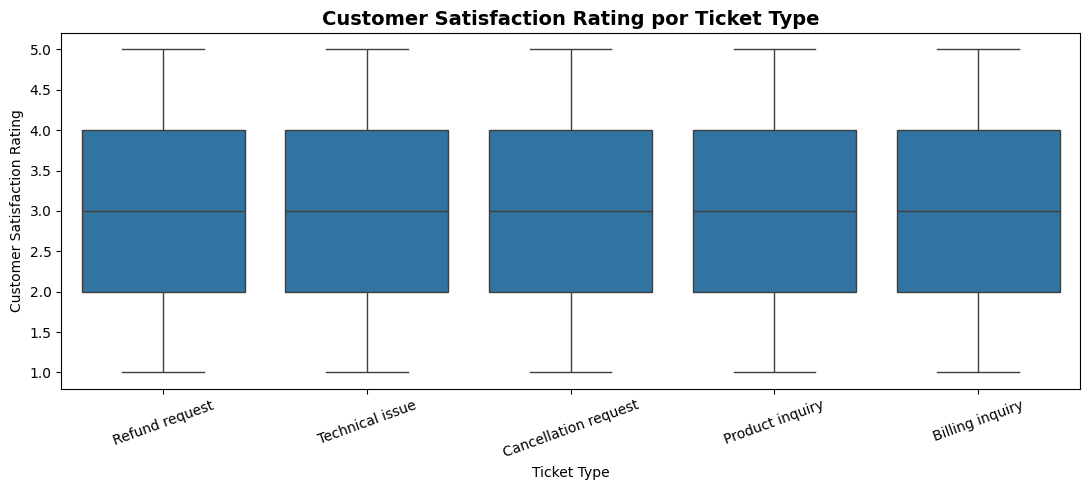


ATENÇÃO:
Customer Satisfaction Rating é analisada apenas para fins exploratórios.
Ela é obtida após o atendimento e não deve ser utilizada automaticamente como preditora da intenção inicial do ticket.
Ver Markdown


In [11]:
# ============================================================
# 1.6.1 — RELAÇÕES ENTRE VARIÁVEIS NUMÉRICAS
# ============================================================

# Variáveis que podem existir no momento da abertura do ticket
# e que poderão ser consideradas como candidatas para o TP3.
colunas_numericas_candidatas = [
    "Customer Age",
    "Description Char Count",
    "Description Word Count",
    "Description Placeholder Count"
]

# Customer Satisfaction Rating será analisada separadamente,
# pois é uma informação obtida depois do atendimento e pode
# representar vazamento de informação para o modelo.
coluna_pos_atendimento = "Customer Satisfaction Rating"

alvo = "Ticket Type"


# ------------------------------------------------------------
# 1. Estatísticas das variáveis numéricas por Ticket Type
# ------------------------------------------------------------

print_formatado(
    "1. Estatísticas das variáveis numéricas por Ticket Type"
)

for coluna in colunas_numericas_candidatas:

    print(
        f"\n{'=' * 80}"
    )

    print(
        f"{coluna} por {alvo}"
    )

    print(
        f"{'=' * 80}"
    )

    resumo_grupos = (
        df
        .groupby(
            alvo,
            observed=True
        )[coluna]
        .agg(
            [
                "count",
                "mean",
                "median",
                "std",
                "min",
                "max"
            ]
        )
        .round(3)
    )

    display(
        resumo_grupos
    )


# ------------------------------------------------------------
# 2. Boxplots por Ticket Type
# ------------------------------------------------------------

print_formatado(
    "2. Distribuição das variáveis numéricas por Ticket Type"
)

ordem_ticket_type = (
    df[alvo]
    .value_counts()
    .index
)

for coluna in colunas_numericas_candidatas:

    plt.figure(
        figsize=(11, 5)
    )

    sns.boxplot(
        data=df,
        x=alvo,
        y=coluna,
        order=ordem_ticket_type
    )

    plt.title(
        f"{coluna} por Ticket Type",
        fontsize=14,
        fontweight="bold"
    )

    plt.xlabel(
        "Ticket Type"
    )

    plt.ylabel(
        coluna
    )

    plt.xticks(
        rotation=20
    )

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 3. Correlação de Pearson entre variáveis independentes
# ------------------------------------------------------------

print_formatado(
    "3. Correlação de Pearson entre variáveis numéricas independentes"
)

matriz_pearson = (
    df[
        colunas_numericas_candidatas
    ]
    .corr(
        method="pearson"
    )
)

display(
    matriz_pearson.round(3)
)


plt.figure(
    figsize=(9, 6)
)

sns.heatmap(
    matriz_pearson,
    annot=True,
    fmt=".2f",
    vmin=-1,
    vmax=1,
    cmap="coolwarm",
    square=True
)

plt.title(
    "Correlação de Pearson entre Variáveis Numéricas",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. Correlação de Spearman
# ------------------------------------------------------------

print_formatado(
    "4. Correlação de Spearman entre variáveis numéricas independentes"
)

matriz_spearman = (
    df[
        colunas_numericas_candidatas
    ]
    .corr(
        method="spearman"
    )
)

display(
    matriz_spearman.round(3)
)


plt.figure(
    figsize=(9, 6)
)

sns.heatmap(
    matriz_spearman,
    annot=True,
    fmt=".2f",
    vmin=-1,
    vmax=1,
    cmap="coolwarm",
    square=True
)

plt.title(
    "Correlação de Spearman entre Variáveis Numéricas",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. Identificação de possível redundância
# ------------------------------------------------------------

print_formatado(
    "5. Possíveis relações redundantes entre variáveis numéricas"
)

limite_correlacao = 0.80

pares_fortes = []

for i in range(
    len(colunas_numericas_candidatas)
):

    for j in range(
        i + 1,
        len(colunas_numericas_candidatas)
    ):

        coluna_1 = (
            colunas_numericas_candidatas[i]
        )

        coluna_2 = (
            colunas_numericas_candidatas[j]
        )

        correlacao = (
            matriz_spearman
            .loc[
                coluna_1,
                coluna_2
            ]
        )

        if abs(correlacao) >= limite_correlacao:

            pares_fortes.append(
                {
                    "Variável 1": coluna_1,
                    "Variável 2": coluna_2,
                    "Spearman": correlacao
                }
            )


if pares_fortes:

    redundancias_numericas = (
        pd.DataFrame(
            pares_fortes
        )
        .sort_values(
            by="Spearman",
            key=lambda serie: serie.abs(),
            ascending=False
        )
    )

    display(
        redundancias_numericas
        .round(3)
    )

    print(
        "\nForam encontrados pares com "
        "|correlação| >= 0.80."
    )

    print(
        "Esses pares devem ser avaliados "
        "como possíveis variáveis redundantes."
    )

else:

    print(
        "Nenhum par apresentou "
        "|correlação de Spearman| >= 0.80."
    )


# ------------------------------------------------------------
# 6. Customer Satisfaction Rating por Ticket Type
# ------------------------------------------------------------

print_formatado(
    "6. Customer Satisfaction Rating por Ticket Type"
)

resumo_satisfacao = (
    df
    .groupby(
        alvo,
        observed=True
    )[coluna_pos_atendimento]
    .agg(
        [
            "count",
            "mean",
            "median",
            "std"
        ]
    )
    .round(3)
)

display(
    resumo_satisfacao
)


plt.figure(
    figsize=(11, 5)
)

sns.boxplot(
    data=df,
    x=alvo,
    y=coluna_pos_atendimento,
    order=ordem_ticket_type
)

plt.title(
    "Customer Satisfaction Rating por Ticket Type",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel(
    "Ticket Type"
)

plt.ylabel(
    "Customer Satisfaction Rating"
)

plt.xticks(
    rotation=20
)

plt.tight_layout()
plt.show()


print(
    "\nATENÇÃO:"
)

print(
    "Customer Satisfaction Rating é analisada "
    "apenas para fins exploratórios."
)

print(
    "Ela é obtida após o atendimento e não deve "
    "ser utilizada automaticamente como preditora "
    "da intenção inicial do ticket."
)


print("Ver Markdown")

### 1.6.1 — Observações das relações entre variáveis numéricas

A análise multivariada numérica teve dois objetivos principais: verificar quais características apresentam diferenças entre as classes de `Ticket Type` e identificar possíveis redundâncias entre variáveis independentes.

#### `Customer Age` e `Ticket Type`

As médias de idade são muito próximas entre todos os tipos de ticket:

- `Billing inquiry`: **44,25 anos**;
- `Cancellation request`: **44,05 anos**;
- `Product inquiry`: **43,76 anos**;
- `Refund request`: **43,94 anos**;
- `Technical issue`: **44,14 anos**.

As medianas também permanecem entre 44 e 45 anos.

Portanto, a análise descritiva não mostra diferenças relevantes de idade entre os tipos de solicitação. Isso sugere que `Customer Age`, isoladamente, provavelmente possui baixo poder discriminativo para prever `Ticket Type`.

#### Comprimento das descrições

`Description Char Count` também apresenta valores muito semelhantes entre as classes.

As médias variam aproximadamente entre **287,92 e 291,18 caracteres**, enquanto as medianas permanecem entre **297 e 299 caracteres**.

O mesmo comportamento ocorre com `Description Word Count`, cujas médias variam apenas entre aproximadamente **46,18 e 46,72 palavras**.

Esses resultados indicam que o simples comprimento da mensagem, seja medido em caracteres ou palavras, não parece diferenciar de maneira importante os cinco tipos de ticket.

Isso não significa que o **conteúdo textual** não seja relevante. A informação discriminativa pode estar nas palavras e expressões utilizadas, e não necessariamente no tamanho da mensagem.

#### Quantidade de placeholders

`Description Placeholder Count` também apresenta comportamento muito semelhante entre as cinco classes.

As médias variam aproximadamente entre **1,74 e 1,77 placeholders por ticket**, e todas as classes apresentam mediana igual a **2**.

Assim, apenas a quantidade de placeholders não apresenta, descritivamente, grande capacidade de distinguir `Ticket Type`.

Entretanto, o **tipo específico de placeholder** ainda poderá apresentar associação com a classe e deve ser avaliado separadamente antes da futura modelagem textual.

#### Redundância entre variáveis independentes

Foi encontrada uma correlação de Spearman de **0,859** entre:

- `Description Char Count`;
- `Description Word Count`.

Como essa associação é elevada e ambas representam essencialmente o tamanho da descrição, existe forte evidência de redundância entre essas duas características.

Para uma futura modelagem, provavelmente não será necessário manter as duas simultaneamente. Uma delas poderá ser removida para reduzir redundância e processamento sem perda substancial de informação.

A decisão definitiva deverá considerar também o desempenho dos modelos no TP3.

#### Síntese

A análise numérica indica que:

1. `Customer Age` apresenta pouca diferença entre as classes de `Ticket Type`;
2. o comprimento da descrição também varia pouco entre as classes;
3. a quantidade total de placeholders apresenta comportamento semelhante entre os tipos de ticket;
4. `Description Char Count` e `Description Word Count` apresentam forte redundância, com **Spearman = 0,859**;
5. entre essas duas variáveis, uma poderá futuramente ser descartada;
6. a maior capacidade preditiva provavelmente estará no conteúdo das variáveis categóricas e textuais, e não apenas nas características numéricas analisadas.






### 1.6.2 — Relações entre variáveis categóricas


1. Associação das variáveis categóricas com Ticket Type


,Variável,Qui-quadrado,p-valor,Graus de liberdade,V de Cramér,Menor freq. esperada,% esperadas < 5
0,Product Purchased,138.803,0.923981,164,0.064,34.34,0.00
1,Ticket Subject,39.571,0.980737,60,0.034,92.22,0.00
2,Ticket Channel,11.851,0.457755,12,0.022,399.96,0.00
3,Ticket Priority,10.625,0.561263,12,0.020,398.03,0.00
4,Customer Gender,5.850,0.664064,8,0.019,518.23,0.00



2. Força de associação com Ticket Type

Product Purchased:
V de Cramér = 0.064 (muito fraca)
p-valor = 0.923981
Conclusão: sem evidência estatística suficiente.

Ticket Subject:
V de Cramér = 0.034 (muito fraca)
p-valor = 0.980737
Conclusão: sem evidência estatística suficiente.

Ticket Channel:
V de Cramér = 0.022 (muito fraca)
p-valor = 0.457755
Conclusão: sem evidência estatística suficiente.

Ticket Priority:
V de Cramér = 0.020 (muito fraca)
p-valor = 0.561263
Conclusão: sem evidência estatística suficiente.

Customer Gender:
V de Cramér = 0.019 (muito fraca)
p-valor = 0.664064
Conclusão: sem evidência estatística suficiente.

3. Distribuição de Ticket Type por Ticket Subject


Ticket Type,Billing inquiry,Cancellation request,Product inquiry,Refund request,Technical issue
Ticket Subject,,,,,
Account access,20.24,18.07,21.02,21.22,19.45
Battery life,19.56,19.19,18.63,21.96,20.66
Cancellation request,16.84,21.15,17.45,22.38,22.18
Data loss,18.13,23.42,18.53,19.76,20.16
Delivery problem,20.50,20.32,19.43,19.07,20.68
Display issue,19.04,21.55,16.74,20.71,21.97
Hardware issue,18.28,19.93,19.38,23.58,18.83
Installation support,20.38,18.68,18.68,22.45,19.81
Network problem,17.63,18.92,20.96,19.85,22.63


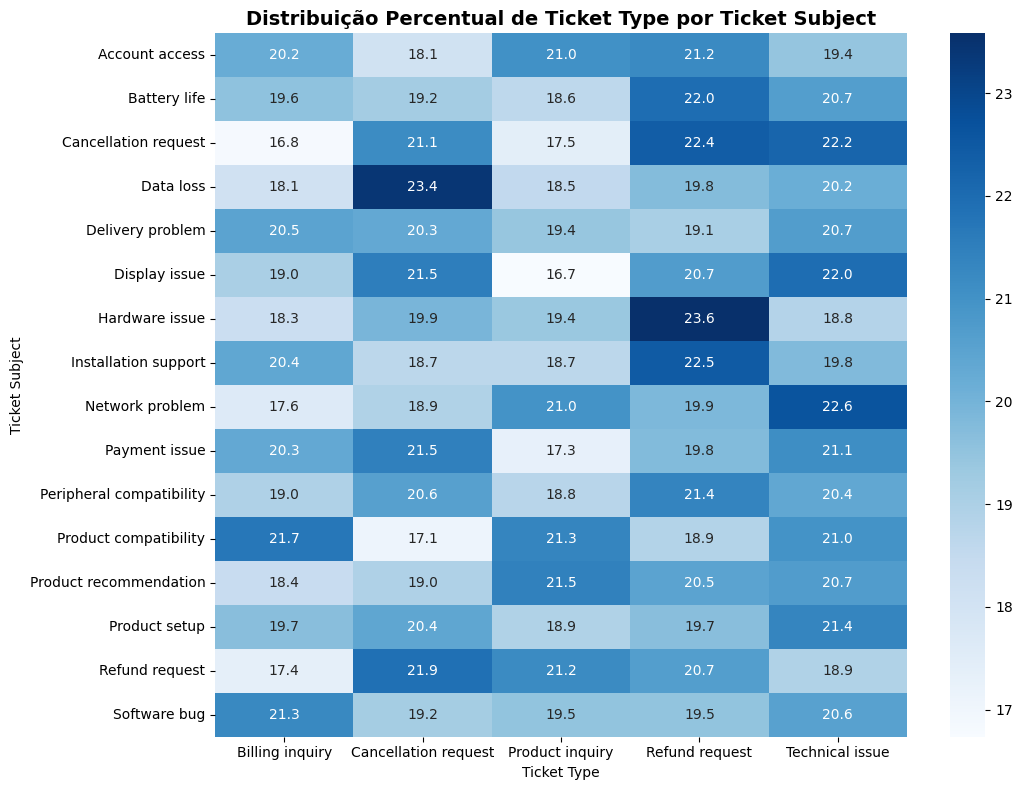


4. Associação entre variáveis categóricas independentes


,Customer Gender,Product Purchased,Ticket Subject,Ticket Priority,Ticket Channel
Customer Gender,1.000,0.062,0.038,0.016,0.017
Product Purchased,0.062,1.000,0.070,0.072,0.068
Ticket Subject,0.038,0.070,1.000,0.040,0.039
Ticket Priority,0.016,0.072,0.040,1.000,0.025
Ticket Channel,0.017,0.068,0.039,0.025,1.000


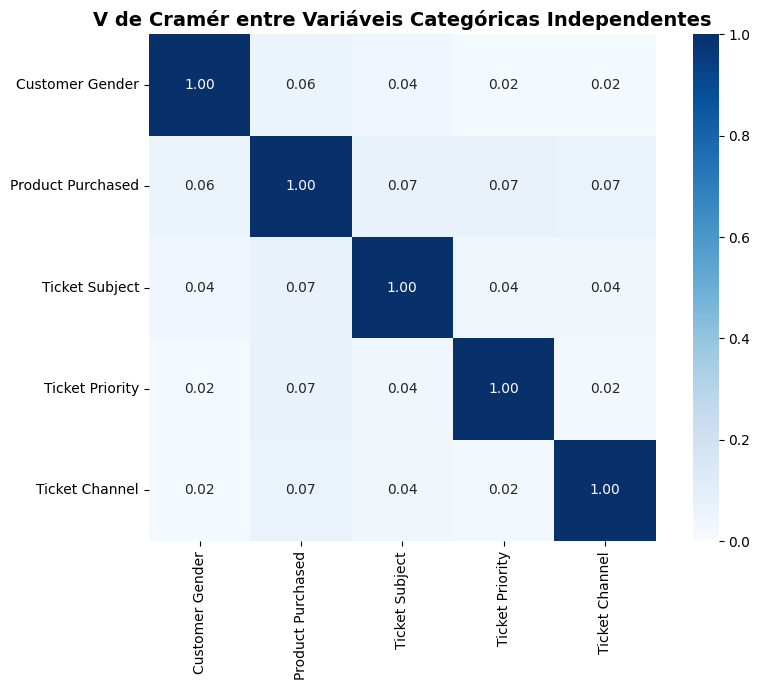


5. Possíveis redundâncias categóricas


,Variável 1,Variável 2,p-valor,V de Cramér
0,Product Purchased,Ticket Priority,0.262751,0.072
1,Product Purchased,Ticket Subject,0.334517,0.070
2,Product Purchased,Ticket Channel,0.634655,0.068
3,Customer Gender,Product Purchased,0.924027,0.062
4,Ticket Subject,Ticket Priority,0.647987,0.040
5,Ticket Subject,Ticket Channel,0.716088,0.039
6,Customer Gender,Ticket Subject,0.771636,0.038
7,Ticket Priority,Ticket Channel,0.078497,0.025
8,Customer Gender,Ticket Channel,0.570992,0.017
9,Customer Gender,Ticket Priority,0.597132,0.016



Nenhum par de variáveis categóricas apresentou V de Cramér >= 0.80.
Não foi identificada redundância categórica forte por esse critério.

6. Ticket Status x Ticket Type — análise exploratória


Ticket Type,Billing inquiry,Cancellation request,Product inquiry,Refund request,Technical issue
Ticket Status,,,,,
Closed,544,516,533,596,580
Open,539,582,532,564,602
Pending Customer Response,551,597,576,592,565



Qui-quadrado: 9.035
p-valor: 0.339368
V de Cramér: 0.023

ATENÇÃO:
Ticket Status é analisada apenas para compreensão do dataset.
Como o status é definido durante o ciclo de atendimento, ele não deve ser utilizado automaticamente como preditor da intenção inicial do ticket.
Ver Markdown


In [12]:
# ============================================================
# 1.6.2 — RELAÇÕES ENTRE VARIÁVEIS CATEGÓRICAS
# ============================================================

alvo_categorico = "Ticket Type"

# Variáveis disponíveis ou potencialmente disponíveis
# no momento da classificação do ticket.
variaveis_categoricas_candidatas = [
    "Customer Gender",
    "Product Purchased",
    "Ticket Subject",
    "Ticket Priority",
    "Ticket Channel"
]


# ------------------------------------------------------------
# Função para calcular V de Cramér
# ------------------------------------------------------------

def calcular_v_cramer(tabela_contingencia):

    chi2, p_valor, graus_liberdade, frequencias_esperadas = (
        chi2_contingency(
            tabela_contingencia
        )
    )

    n = (
        tabela_contingencia
        .to_numpy()
        .sum()
    )

    linhas, colunas = (
        tabela_contingencia.shape
    )

    menor_dimensao = min(
        linhas - 1,
        colunas - 1
    )

    if (
        n == 0
        or menor_dimensao == 0
    ):

        v_cramer = np.nan

    else:

        v_cramer = np.sqrt(
            chi2
            / (
                n
                * menor_dimensao
            )
        )

    return (
        chi2,
        p_valor,
        graus_liberdade,
        v_cramer,
        frequencias_esperadas
    )


# ------------------------------------------------------------
# 1. Associação das variáveis candidatas com Ticket Type
# ------------------------------------------------------------

print_formatado(
    "1. Associação das variáveis categóricas com Ticket Type"
)

resultados_alvo = []


for coluna in variaveis_categoricas_candidatas:

    tabela_contingencia = (
        pd.crosstab(
            df[coluna],
            df[alvo_categorico]
        )
    )

    (
        chi2,
        p_valor,
        graus_liberdade,
        v_cramer,
        frequencias_esperadas
    ) = calcular_v_cramer(
        tabela_contingencia
    )

    menor_frequencia_esperada = (
        frequencias_esperadas.min()
    )

    percentual_esperadas_menor_5 = (
        (
            frequencias_esperadas < 5
        )
        .mean()
        * 100
    )

    resultados_alvo.append(
        {
            "Variável": coluna,
            "Qui-quadrado": chi2,
            "p-valor": p_valor,
            "Graus de liberdade": graus_liberdade,
            "V de Cramér": v_cramer,
            "Menor freq. esperada": menor_frequencia_esperada,
            "% esperadas < 5": percentual_esperadas_menor_5
        }
    )


resultados_alvo_df = (
    pd.DataFrame(
        resultados_alvo
    )
    .sort_values(
        "V de Cramér",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


display(
    resultados_alvo_df.style.format(
        {
            "Qui-quadrado": "{:.3f}",
            "p-valor": "{:.6f}",
            "V de Cramér": "{:.3f}",
            "Menor freq. esperada": "{:.2f}",
            "% esperadas < 5": "{:.2f}"
        }
    )
)


# ------------------------------------------------------------
# 2. Interpretação do poder de associação
# ------------------------------------------------------------

print_formatado(
    "2. Força de associação com Ticket Type"
)


def interpretar_v_cramer(valor):

    if pd.isna(valor):

        return "não calculável"

    if valor < 0.10:

        return "muito fraca"

    if valor < 0.30:

        return "fraca"

    if valor < 0.50:

        return "moderada"

    return "forte"


for _, linha in resultados_alvo_df.iterrows():

    significancia = (
        "estatisticamente significativa"
        if linha["p-valor"] < 0.05
        else "sem evidência estatística suficiente"
    )

    intensidade = interpretar_v_cramer(
        linha["V de Cramér"]
    )

    print(
        f"\n{linha['Variável']}:"
    )

    print(
        f"V de Cramér = "
        f"{linha['V de Cramér']:.3f} "
        f"({intensidade})"
    )

    print(
        f"p-valor = "
        f"{linha['p-valor']:.6f}"
    )

    print(
        f"Conclusão: "
        f"{significancia}."
    )


# ------------------------------------------------------------
# 3. Ticket Subject x Ticket Type
# ------------------------------------------------------------

print_formatado(
    "3. Distribuição de Ticket Type por Ticket Subject"
)

tabela_subject_type = (
    pd.crosstab(
        df["Ticket Subject"],
        df[alvo_categorico],
        normalize="index"
    )
    .mul(100)
)

display(
    tabela_subject_type.round(2)
)


plt.figure(
    figsize=(11, 8)
)

sns.heatmap(
    tabela_subject_type,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

plt.title(
    "Distribuição Percentual de Ticket Type por Ticket Subject",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel(
    "Ticket Type"
)

plt.ylabel(
    "Ticket Subject"
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. Associação entre variáveis categóricas independentes
# ------------------------------------------------------------

print_formatado(
    "4. Associação entre variáveis categóricas independentes"
)

matriz_v_cramer = pd.DataFrame(
    np.eye(
        len(
            variaveis_categoricas_candidatas
        )
    ),
    index=variaveis_categoricas_candidatas,
    columns=variaveis_categoricas_candidatas
)


resultados_independentes = []


for i in range(
    len(
        variaveis_categoricas_candidatas
    )
):

    for j in range(
        i + 1,
        len(
            variaveis_categoricas_candidatas
        )
    ):

        coluna_1 = (
            variaveis_categoricas_candidatas[i]
        )

        coluna_2 = (
            variaveis_categoricas_candidatas[j]
        )

        tabela_contingencia = (
            pd.crosstab(
                df[coluna_1],
                df[coluna_2]
            )
        )

        (
            chi2,
            p_valor,
            graus_liberdade,
            v_cramer,
            frequencias_esperadas
        ) = calcular_v_cramer(
            tabela_contingencia
        )

        matriz_v_cramer.loc[
            coluna_1,
            coluna_2
        ] = v_cramer

        matriz_v_cramer.loc[
            coluna_2,
            coluna_1
        ] = v_cramer

        resultados_independentes.append(
            {
                "Variável 1": coluna_1,
                "Variável 2": coluna_2,
                "p-valor": p_valor,
                "V de Cramér": v_cramer
            }
        )


display(
    matriz_v_cramer.round(3)
)


plt.figure(
    figsize=(9, 7)
)

sns.heatmap(
    matriz_v_cramer,
    annot=True,
    fmt=".2f",
    vmin=0,
    vmax=1,
    cmap="Blues",
    square=True
)

plt.title(
    "V de Cramér entre Variáveis Categóricas Independentes",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. Possíveis redundâncias categóricas
# ------------------------------------------------------------

print_formatado(
    "5. Possíveis redundâncias categóricas"
)

resultados_independentes_df = (
    pd.DataFrame(
        resultados_independentes
    )
    .sort_values(
        "V de Cramér",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

display(
    resultados_independentes_df.style.format(
        {
            "p-valor": "{:.6f}",
            "V de Cramér": "{:.3f}"
        }
    )
)


limite_redundancia = 0.80

pares_redundantes = (
    resultados_independentes_df[
        resultados_independentes_df[
            "V de Cramér"
        ]
        >= limite_redundancia
    ]
)


if pares_redundantes.empty:

    print(
        "\nNenhum par de variáveis categóricas "
        "apresentou V de Cramér >= 0.80."
    )

    print(
        "Não foi identificada redundância categórica "
        "forte por esse critério."
    )

else:

    print(
        "\nForam encontrados possíveis pares redundantes:"
    )

    display(
        pares_redundantes
    )


# ------------------------------------------------------------
# 6. Ticket Status x Ticket Type
# ------------------------------------------------------------

print_formatado(
    "6. Ticket Status x Ticket Type — análise exploratória"
)

tabela_status_type = (
    pd.crosstab(
        df["Ticket Status"],
        df[alvo_categorico]
    )
)

(
    chi2_status,
    p_status,
    gl_status,
    v_status,
    esperadas_status
) = calcular_v_cramer(
    tabela_status_type
)

display(
    tabela_status_type
)

print(
    f"\nQui-quadrado: "
    f"{chi2_status:.3f}"
)

print(
    f"p-valor: "
    f"{p_status:.6f}"
)

print(
    f"V de Cramér: "
    f"{v_status:.3f}"
)

print(
    "\nATENÇÃO:"
)

print(
    "Ticket Status é analisada apenas para "
    "compreensão do dataset."
)

print(
    "Como o status é definido durante o ciclo "
    "de atendimento, ele não deve ser utilizado "
    "automaticamente como preditor da intenção "
    "inicial do ticket."
)


print("Ver Markdown")

### 1.6.2 — Observações das relações entre variáveis categóricas

A análise multivariada categórica teve como objetivo avaliar quais variáveis apresentam associação com `Ticket Type` e verificar possíveis redundâncias entre as variáveis independentes.

Para isso, foram utilizados o teste de independência do qui-quadrado e o **V de Cramér**, que permite avaliar a intensidade da associação entre duas variáveis categóricas.

#### Associação com `Ticket Type`

Os resultados encontrados foram:

| Variável | p-valor | V de Cramér | Interpretação |
|---|---:|---:|---|
| `Product Purchased` | 0,923981 | 0,064 | associação muito fraca |
| `Ticket Subject` | 0,980737 | 0,034 | associação muito fraca |
| `Ticket Channel` | 0,457755 | 0,022 | associação muito fraca |
| `Ticket Priority` | 0,561263 | 0,020 | associação muito fraca |
| `Customer Gender` | 0,664064 | 0,019 | associação muito fraca |

Todos os p-valores ficaram acima do nível de significância de 5%.

Portanto, **não foi encontrada evidência estatística suficiente de associação entre essas variáveis categóricas e `Ticket Type` quando consideradas individualmente**.

Além disso, todos os valores de V de Cramér ficaram abaixo de 0,10, indicando associações muito fracas.

#### `Product Purchased`

Entre as variáveis avaliadas, `Product Purchased` apresentou o maior V de Cramér, com valor de **0,064**.

Apesar de ser o maior valor observado, ele ainda representa uma associação muito fraca.

O p-valor de **0,923981** também não permite rejeitar a hipótese de independência.

Assim, não há evidência de que o produto adquirido, isoladamente, seja um forte discriminador do tipo de ticket.

#### `Ticket Subject`

`Ticket Subject` poderia, conceitualmente, parecer uma variável promissora para identificar a intenção do ticket.

Entretanto, nesta base de dados, o resultado foi:

- V de Cramér: **0,034**;
- p-valor: **0,980737**.

Portanto, sua associação isolada com `Ticket Type` é muito fraca e não estatisticamente significativa.

Esse resultado é importante porque mostra que uma variável aparentemente relacionada semanticamente ao problema não necessariamente possui capacidade discriminativa suficiente quando utilizada isoladamente.

#### `Ticket Channel`, `Ticket Priority` e `Customer Gender`

As três variáveis apresentaram valores de V de Cramér ainda menores:

- `Ticket Channel`: **0,022**;
- `Ticket Priority`: **0,020**;
- `Customer Gender`: **0,019**.

Nenhuma apresentou evidência estatística de associação relevante com `Ticket Type`.

Assim, elas provavelmente possuem baixo poder preditivo quando consideradas individualmente.

Isso não significa que devam ser automaticamente removidas, pois combinações entre variáveis podem apresentar comportamento diferente durante a modelagem.

### Redundância entre variáveis categóricas

Também foi calculado o V de Cramér entre as variáveis categóricas independentes.

O maior valor encontrado foi:

- `Product Purchased` × `Ticket Priority`: **V de Cramér = 0,072**.

Os demais valores também foram muito baixos.

Nenhum par apresentou:

**V de Cramér ≥ 0,80**

Portanto, **não foi identificada redundância categórica forte** entre as variáveis analisadas.

Diferentemente do resultado numérico encontrado entre `Description Char Count` e `Description Word Count`, não existe evidência para remover alguma variável categórica apenas por redundância.

### Validade do teste qui-quadrado

As frequências esperadas das tabelas de contingência também foram verificadas.

Para todas as relações analisadas com `Ticket Type`, o percentual de células com frequência esperada inferior a 5 foi **0%**.

Portanto, não foram identificadas violações relevantes desse critério para a aplicação do teste qui-quadrado.

### Implicações para o TP3

A análise multivariada mostra que as características demográficas, operacionais e categóricas analisadas apresentam pouca associação individual com a intenção representada por `Ticket Type`.

Isso fortalece a hipótese de que a principal informação necessária para classificar a intenção do ticket pode estar no **conteúdo textual de `Ticket Description`**, e não apenas em características estruturadas como idade, gênero, canal, prioridade ou produto.

No TP3, será importante comparar o desempenho de modelos que utilizem:

- conteúdo textual de `Ticket Description`;
- possíveis características estruturadas;
- combinações entre texto e variáveis auxiliares.

As variáveis produzidas depois da abertura ou durante o tratamento do ticket deverão continuar sendo excluídas como candidatas iniciais sempre que houver risco de *data leakage*.

### Conclusão da análise multivariada

A análise multivariada permitiu responder aos dois objetivos definidos para esta etapa.

#### 1. Variáveis potencialmente úteis para prever `Ticket Type`

As variáveis numéricas e categóricas estruturadas analisadas apresentaram diferenças ou associações muito pequenas com a variável-alvo.

`Customer Age`, comprimento das descrições, quantidade de placeholders, gênero, produto, assunto, prioridade e canal não demonstraram forte capacidade discriminativa individual.

Consequentemente, os resultados apontam para a necessidade de explorar principalmente o **conteúdo textual de `Ticket Description`** na futura tarefa de classificação.

Isso não implica que as demais variáveis devam ser descartadas automaticamente, mas indica que seu valor preditivo deverá ser comprovado empiricamente durante a modelagem.

#### 2. Variáveis independentes redundantes

Foi encontrada forte correlação entre:

- `Description Char Count`;
- `Description Word Count`.

A correlação de Spearman foi de **0,859**, indicando que ambas representam praticamente a mesma característica: o tamanho da descrição.

Assim, uma das duas poderá ser removida futuramente para reduzir redundância e processamento.

Entre as variáveis categóricas, nenhuma relação forte de redundância foi encontrada.

### Síntese

Os principais achados da análise multivariada são:

1. as variáveis estruturadas apresentam pouca associação individual com `Ticket Type`;
2. nenhuma variável categórica analisada apresentou associação estatisticamente significativa com o alvo;
3. não foi identificada redundância forte entre as variáveis categóricas;
4. `Description Char Count` e `Description Word Count` apresentam forte redundância;
5. o conteúdo textual de `Ticket Description` surge como a principal fonte potencial de informação para a classificação;
6. variáveis pós-atendimento devem permanecer separadas das candidatas preditoras devido ao risco de *data leakage*.


## 1.7 — Identificação de outliers e anomalias

### 1.7.1 — Avaliação da normalidade das variáveis numéricas


1. Avaliação da normalidade antes da identificação de outliers

Variável: Customer Age
Quantidade de valores válidos: 8469
Assimetria: -0.0172


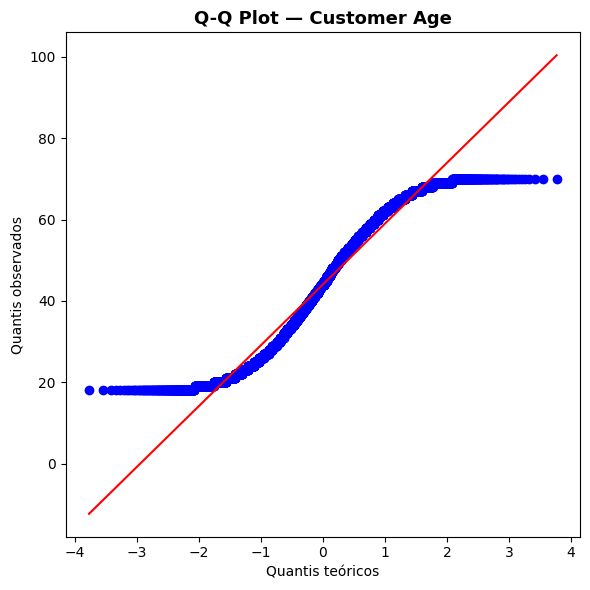

Estatística W: 0.9534
p-valor: 0.00000000
Conclusão: Rejeita normalidade
Método sugerido para valores extremos: IQR

Variável: Customer Satisfaction Rating
Quantidade de valores válidos: 2769
Assimetria: 0.0084


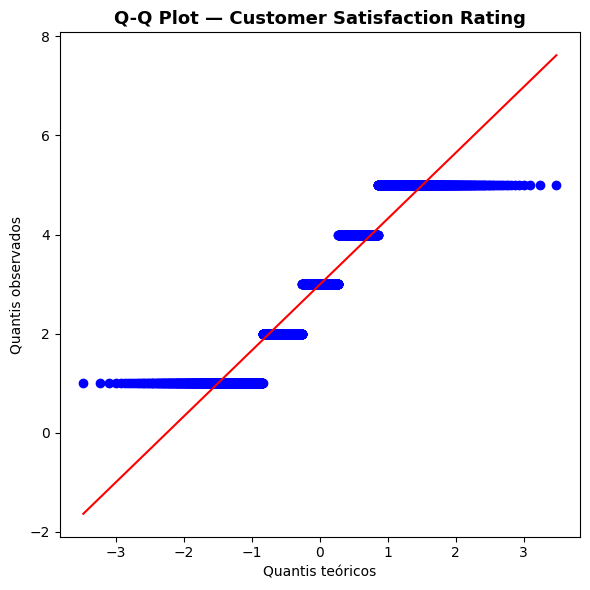

Estatística W: 0.8896
p-valor: 0.00000000
Conclusão: Rejeita normalidade
Método sugerido para valores extremos: IQR

Variável: Description Char Count
Quantidade de valores válidos: 8469
Assimetria: -1.1363


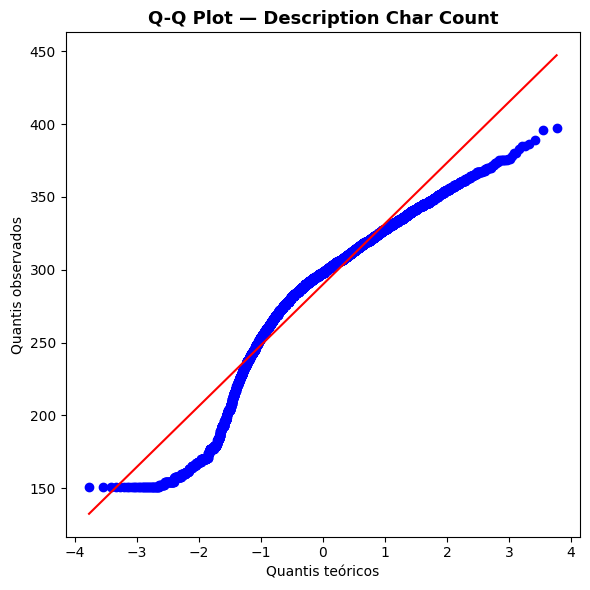

Estatística W: 0.9200
p-valor: 0.00000000
Conclusão: Rejeita normalidade
Método sugerido para valores extremos: IQR

Variável: Description Word Count
Quantidade de valores válidos: 8469
Assimetria: -1.0296


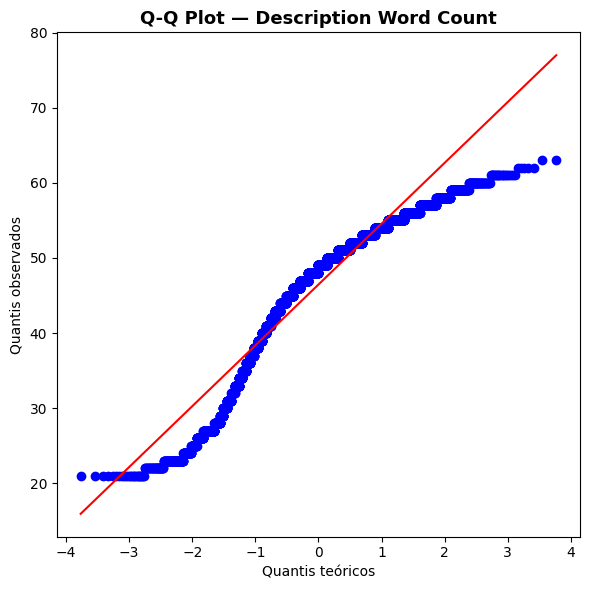

Estatística W: 0.9166
p-valor: 0.00000000
Conclusão: Rejeita normalidade
Método sugerido para valores extremos: IQR

Variável: Description Placeholder Count
Quantidade de valores válidos: 8469
Assimetria: 1.1712


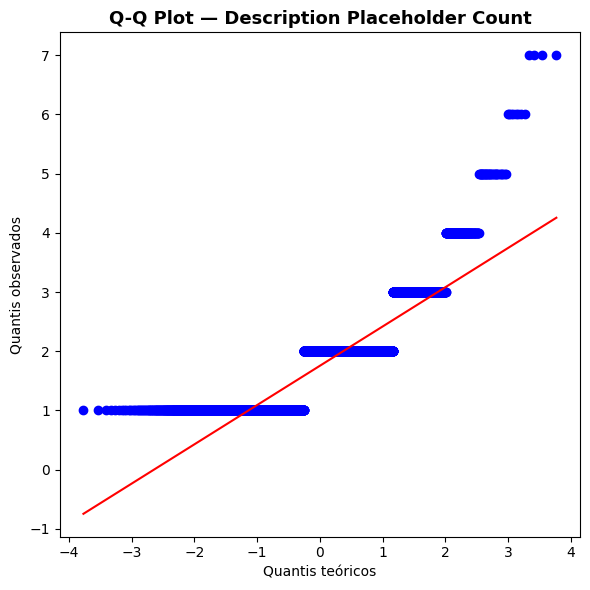

Estatística W: 0.7766
p-valor: 0.00000000
Conclusão: Rejeita normalidade
Método sugerido para valores extremos: IQR

2. Resumo dos testes de normalidade


,Variável,Valores válidos,Assimetria,W Shapiro,p-valor,Conclusão,Método sugerido
0,Customer Age,8469,-0.0172,0.9534,0.00000000,Rejeita normalidade,IQR
1,Customer Satisfaction Rating,2769,0.0084,0.8896,0.00000000,Rejeita normalidade,IQR
2,Description Char Count,8469,-1.1363,0.9200,0.00000000,Rejeita normalidade,IQR
3,Description Word Count,8469,-1.0296,0.9166,0.00000000,Rejeita normalidade,IQR
4,Description Placeholder Count,8469,1.1712,0.7766,0.00000000,Rejeita normalidade,IQR



3. Decisão metodológica
A normalidade foi verificada antes da escolha do método de identificação de valores extremos.
O teste estatístico será interpretado em conjunto com o Q-Q Plot e com a natureza de cada variável.
Um valor extremo não será considerado erro apenas por ultrapassar um limite estatístico.
Qualquer possível outlier deverá ser avaliado quanto à plausibilidade e à qualidade do dado antes de uma eventual remoção.
Ver Markdown


In [13]:
# ============================================================
# 1.7.1 — AVALIAÇÃO DA NORMALIDADE DAS VARIÁVEIS NUMÉRICAS
# ============================================================

from scipy import stats


colunas_numericas_outliers = [
    "Customer Age",
    "Customer Satisfaction Rating",
    "Description Char Count",
    "Description Word Count",
    "Description Placeholder Count"
]


alpha = 0.05
tamanho_maximo_shapiro = 5000

resultados_normalidade = []


print_formatado(
    "1. Avaliação da normalidade antes da identificação de outliers"
)


for coluna in colunas_numericas_outliers:

    dados = (
        df[coluna]
        .dropna()
    )

    print(
        f"\n{'=' * 80}"
    )

    print(
        f"Variável: {coluna}"
    )

    print(
        f"{'=' * 80}"
    )

    print(
        f"Quantidade de valores válidos: "
        f"{len(dados)}"
    )


    # --------------------------------------------------------
    # Assimetria
    # --------------------------------------------------------

    assimetria = stats.skew(
        dados,
        bias=False,
        nan_policy="omit"
    )

    print(
        f"Assimetria: "
        f"{assimetria:.4f}"
    )


    # --------------------------------------------------------
    # Q-Q Plot
    # --------------------------------------------------------

    plt.figure(
        figsize=(6, 6)
    )

    stats.probplot(
        dados,
        dist="norm",
        plot=plt
    )

    plt.title(
        f"Q-Q Plot — {coluna}",
        fontsize=13,
        fontweight="bold"
    )

    plt.xlabel(
        "Quantis teóricos"
    )

    plt.ylabel(
        "Quantis observados"
    )

    plt.tight_layout()
    plt.show()


    # --------------------------------------------------------
    # Shapiro-Wilk
    # --------------------------------------------------------
    # Para conjuntos maiores que 5.000 observações,
    # utiliza-se uma amostra reprodutível.

    if len(dados) > tamanho_maximo_shapiro:

        dados_teste = dados.sample(
            n=tamanho_maximo_shapiro,
            random_state=42
        )

    else:

        dados_teste = dados


    estatistica_w, p_valor = (
        stats.shapiro(
            dados_teste
        )
    )


    if p_valor < alpha:

        conclusao = (
            "Rejeita normalidade"
        )

        metodo_recomendado = (
            "IQR"
        )

    else:

        conclusao = (
            "Não rejeita normalidade"
        )

        metodo_recomendado = (
            "Avaliar Z-score e IQR"
        )


    resultados_normalidade.append(
        {
            "Variável": coluna,
            "Valores válidos": len(dados),
            "Assimetria": assimetria,
            "W Shapiro": estatistica_w,
            "p-valor": p_valor,
            "Conclusão": conclusao,
            "Método sugerido": metodo_recomendado
        }
    )


    print(
        f"Estatística W: "
        f"{estatistica_w:.4f}"
    )

    print(
        f"p-valor: "
        f"{p_valor:.8f}"
    )

    print(
        f"Conclusão: "
        f"{conclusao}"
    )

    print(
        f"Método sugerido para valores extremos: "
        f"{metodo_recomendado}"
    )


# ------------------------------------------------------------
# Resumo consolidado
# ------------------------------------------------------------

print_formatado(
    "2. Resumo dos testes de normalidade"
)

resultados_normalidade_df = (
    pd.DataFrame(
        resultados_normalidade
    )
)

display(
    resultados_normalidade_df.style.format(
        {
            "Assimetria": "{:.4f}",
            "W Shapiro": "{:.4f}",
            "p-valor": "{:.8f}"
        }
    )
)


# ------------------------------------------------------------
# Observação metodológica
# ------------------------------------------------------------

print_formatado(
    "3. Decisão metodológica"
)

print(
    "A normalidade foi verificada antes da escolha "
    "do método de identificação de valores extremos."
)

print(
    "O teste estatístico será interpretado em conjunto "
    "com o Q-Q Plot e com a natureza de cada variável."
)

print(
    "Um valor extremo não será considerado erro apenas "
    "por ultrapassar um limite estatístico."
)

print(
    "Qualquer possível outlier deverá ser avaliado "
    "quanto à plausibilidade e à qualidade do dado "
    "antes de uma eventual remoção."
)


print("Ver Markdown")

### **Observações – Identificação de Outliers e Anomalias**

### 1. Seleção do método de identificação de outliers

Foram analisadas as variáveis numéricas `Customer Age` e `Customer Satisfaction Rating` por meio de Q-Q Plot, assimetria e teste de Shapiro-Wilk.

A variável `Customer Age` apresentou assimetria próxima de zero, indicando uma distribuição aproximadamente simétrica. Entretanto, o Q-Q Plot e o teste de Shapiro-Wilk indicaram diferença em relação a uma distribuição normal, com p-valor inferior a 0,05.

A variável `Customer Satisfaction Rating` também apresentou assimetria próxima de zero. Entretanto, trata-se de uma variável discreta e ordinal, limitada aos valores de 1 a 5. O teste de Shapiro-Wilk também apresentou p-valor inferior a 0,05.

Dessa forma, não foi assumida normalidade para essas variáveis.

Para identificação de possíveis valores extremos será utilizado o método IQR (Interquartile Range), que não exige a hipótese de distribuição normal.

In [16]:
# ============================================================
# 1.7.2 — IDENTIFICAÇÃO DE VALORES EXTREMOS PELO MÉTODO IQR
# ============================================================

variaveis_iqr = [
    "Customer Age",
    "Customer Satisfaction Rating",
    "Description Char Count",
    "Description Word Count",
    "Description Placeholder Count"
]


print_formatado(
    "1.7.2 Identificação de possíveis valores extremos com IQR"
)


resultados_iqr = []
indices_outliers = set()


for coluna in variaveis_iqr:

    dados = (
        df[coluna]
        .dropna()
    )

    q1 = (
        dados
        .quantile(0.25)
    )

    q3 = (
        dados
        .quantile(0.75)
    )

    iqr = (
        q3 - q1
    )

    limite_inferior = (
        q1
        - 1.5 * iqr
    )

    limite_superior = (
        q3
        + 1.5 * iqr
    )

    mascara_outliers = (
        (df[coluna] < limite_inferior)
        |
        (df[coluna] > limite_superior)
    )

    outliers_coluna = (
        df.loc[
            mascara_outliers,
            [
                "Ticket ID",
                coluna
            ]
        ]
        .copy()
    )

    quantidade_outliers = (
        len(
            outliers_coluna
        )
    )

    percentual_outliers = (
        quantidade_outliers
        / len(dados)
        * 100
    )

    indices_outliers.update(
        outliers_coluna.index
    )

    resultados_iqr.append(
        {
            "Variável": coluna,
            "Q1": q1,
            "Q3": q3,
            "IQR": iqr,
            "Limite inferior": limite_inferior,
            "Limite superior": limite_superior,
            "Mínimo observado": dados.min(),
            "Máximo observado": dados.max(),
            "Possíveis outliers": quantidade_outliers,
            "Percentual (%)": percentual_outliers
        }
    )


    print(
        f"\n{'=' * 80}"
    )

    print(
        f"Variável: {coluna}"
    )

    print(
        f"{'=' * 80}"
    )

    print(
        f"Q1: "
        f"{q1:.2f}"
    )

    print(
        f"Q3: "
        f"{q3:.2f}"
    )

    print(
        f"IQR: "
        f"{iqr:.2f}"
    )

    print(
        f"Limite inferior: "
        f"{limite_inferior:.2f}"
    )

    print(
        f"Limite superior: "
        f"{limite_superior:.2f}"
    )

    print(
        f"Mínimo observado: "
        f"{dados.min():.2f}"
    )

    print(
        f"Máximo observado: "
        f"{dados.max():.2f}"
    )

    print(
        f"Possíveis outliers pelo IQR: "
        f"{quantidade_outliers}"
    )

    print(
        f"Percentual: "
        f"{percentual_outliers:.2f}%"
    )


    if quantidade_outliers > 0:

        print(
            "\nExemplos de valores sinalizados:"
        )

        display(
            outliers_coluna.head(10)
        )

    else:

        print(
            "\nNenhum valor foi sinalizado "
            "como extremo pelo critério IQR."
        )


# ------------------------------------------------------------
# Resumo consolidado
# ------------------------------------------------------------

print_formatado(
    "Resumo dos possíveis valores extremos"
)

resultados_iqr_df = (
    pd.DataFrame(
        resultados_iqr
    )
)

display(
    resultados_iqr_df.style.format(
        {
            "Q1": "{:.2f}",
            "Q3": "{:.2f}",
            "IQR": "{:.2f}",
            "Limite inferior": "{:.2f}",
            "Limite superior": "{:.2f}",
            "Mínimo observado": "{:.2f}",
            "Máximo observado": "{:.2f}",
            "Percentual (%)": "{:.2f}"
        }
    )
)


print(
    "\nQuantidade de registros únicos "
    "sinalizados em pelo menos uma variável:"
)

print(
    len(indices_outliers)
)


# ------------------------------------------------------------
# Avaliação de plausibilidade
# ------------------------------------------------------------

print_formatado(
    "Avaliação de plausibilidade dos valores sinalizados"
)


print(
    "\nCustomer Age:"
)

print(
    "Valores observados entre 18 e 70 anos "
    "são plausíveis para o domínio."
)


print(
    "\nCustomer Satisfaction Rating:"
)

print(
    "Valores observados entre 1 e 5 pertencem "
    "à escala válida de satisfação."
)


print(
    "\nDescription Char Count e Description Word Count:"
)

print(
    "Valores extremos representam descrições mais curtas "
    "ou mais longas, não necessariamente erros."
)


print(
    "\nDescription Placeholder Count:"
)

print(
    "Uma quantidade elevada de placeholders pode ser "
    "estatisticamente incomum, mas não constitui erro "
    "sem evidência adicional."
)


print(
    "\nDECISÃO:"
)

print(
    "Nenhum registro será removido automaticamente "
    "apenas por ter sido identificado como outlier pelo IQR."
)

print(
    "A remoção somente seria justificável se o valor "
    "fosse incompatível com o domínio ou resultado "
    "de erro de coleta/preenchimento."
)


print("Ver Markdown")


1.7.2 Identificação de possíveis valores extremos com IQR

Variável: Customer Age
Q1: 31.00
Q3: 57.00
IQR: 26.00
Limite inferior: -8.00
Limite superior: 96.00
Mínimo observado: 18.00
Máximo observado: 70.00
Possíveis outliers pelo IQR: 0
Percentual: 0.00%

Nenhum valor foi sinalizado como extremo pelo critério IQR.

Variável: Customer Satisfaction Rating
Q1: 2.00
Q3: 4.00
IQR: 2.00
Limite inferior: -1.00
Limite superior: 7.00
Mínimo observado: 1.00
Máximo observado: 5.00
Possíveis outliers pelo IQR: 0
Percentual: 0.00%

Nenhum valor foi sinalizado como extremo pelo critério IQR.

Variável: Description Char Count
Q1: 273.00
Q3: 318.00
IQR: 45.00
Limite inferior: 205.50
Limite superior: 385.50
Mínimo observado: 151.00
Máximo observado: 397.00
Possíveis outliers pelo IQR: 579
Percentual: 6.84%

Exemplos de valores sinalizados:


,Ticket ID,Description Char Count
23,24,205
29,30,203
52,53,167
56,57,184
80,81,197
105,106,151
106,107,152
107,108,165
189,190,190
207,208,174



Variável: Description Word Count
Q1: 43.00
Q3: 52.00
IQR: 9.00
Limite inferior: 29.50
Limite superior: 65.50
Mínimo observado: 21.00
Máximo observado: 63.00
Possíveis outliers pelo IQR: 555
Percentual: 6.55%

Exemplos de valores sinalizados:


,Ticket ID,Description Word Count
29,30,29
52,53,25
56,57,27
94,95,25
105,106,23
106,107,22
107,108,23
126,127,25
175,176,28
189,190,29



Variável: Description Placeholder Count
Q1: 1.00
Q3: 2.00
IQR: 1.00
Limite inferior: -0.50
Limite superior: 3.50
Mínimo observado: 1.00
Máximo observado: 7.00
Possíveis outliers pelo IQR: 189
Percentual: 2.23%

Exemplos de valores sinalizados:


,Ticket ID,Description Placeholder Count
64,65,4
68,69,4
70,71,4
86,87,4
153,154,4
214,215,4
294,295,4
297,298,5
299,300,4
323,324,4



Resumo dos possíveis valores extremos


,Variável,Q1,Q3,IQR,Limite inferior,Limite superior,Mínimo observado,Máximo observado,Possíveis outliers,Percentual (%)
0,Customer Age,31.00,57.00,26.00,-8.00,96.00,18.00,70.00,0,0.00
1,Customer Satisfaction Rating,2.00,4.00,2.00,-1.00,7.00,1.00,5.00,0,0.00
2,Description Char Count,273.00,318.00,45.00,205.50,385.50,151.00,397.00,579,6.84
3,Description Word Count,43.00,52.00,9.00,29.50,65.50,21.00,63.00,555,6.55
4,Description Placeholder Count,1.00,2.00,1.00,-0.50,3.50,1.00,7.00,189,2.23



Quantidade de registros únicos sinalizados em pelo menos uma variável:
835

Avaliação de plausibilidade dos valores sinalizados

Customer Age:
Valores observados entre 18 e 70 anos são plausíveis para o domínio.

Customer Satisfaction Rating:
Valores observados entre 1 e 5 pertencem à escala válida de satisfação.

Description Char Count e Description Word Count:
Valores extremos representam descrições mais curtas ou mais longas, não necessariamente erros.

Description Placeholder Count:
Uma quantidade elevada de placeholders pode ser estatisticamente incomum, mas não constitui erro sem evidência adicional.

DECISÃO:
Nenhum registro será removido automaticamente apenas por ter sido identificado como outlier pelo IQR.
A remoção somente seria justificável se o valor fosse incompatível com o domínio ou resultado de erro de coleta/preenchimento.
Ver Markdown


### **Observações – Identificação de Outliers Numéricos**

O método IQR foi aplicado às duas variáveis numéricas analisadas.

### `Customer Age`

- Q1 = 31 anos.
- Q3 = 57 anos.
- IQR = 26 anos.
- Limite inferior = -8 anos.
- Limite superior = 96 anos.
- Os valores observados no dataset variam de 18 a 70 anos.

Portanto, nenhum registro foi identificado como outlier de idade pelo método IQR.

### `Customer Satisfaction Rating`

- Q1 = 2.
- Q3 = 4.
- IQR = 2.
- Limite inferior = -1.
- Limite superior = 7.
- Os valores observados variam de 1 a 5.

Portanto, nenhum registro foi identificado como outlier de satisfação pelo método IQR.

Dessa forma, não foi necessária a remoção de registros por valores extremos nessas duas variáveis.

## **Variáveis Categóricas**

In [ ]:
colunas_categoricas = [
    "Customer Gender",
    "Product Purchased",
    "Ticket Type",
    "Ticket Status",
    "Ticket Priority",
    "Ticket Channel"
]


nivel_desequilibrio = 2
limite_categoria_rara = 0.01


print_formatado(
    "1. Identificar categorias raras"
)


for coluna in colunas_categoricas:

    frequencia_relativa = (
        df[coluna]
        .value_counts(
            normalize=True,
            dropna=False
        )
    )


    categorias_raras = (
        frequencia_relativa[
            frequencia_relativa <
            limite_categoria_rara
        ]
    )


    print(
        f"\nVariável: {coluna}"
    )


    if categorias_raras.empty:

        print(
            "Nenhuma categoria com frequência "
            "inferior a 1%."
        )

    else:

        print(
            "Categorias com frequência "
            "inferior a 1%:"
        )

        print(
            (
                categorias_raras * 100
            )
            .round(2)
            .astype(str)
            + "%"
        )


print_formatado(
    "2. Identificar possível desequilíbrio entre categorias"
)


for coluna in colunas_categoricas:

    contagem = (
        df[coluna]
        .value_counts(
            dropna=False
        )
    )


    maior_frequencia = (
        contagem.max()
    )

    menor_frequencia = (
        contagem.min()
    )


    razao_desequilibrio = (
        maior_frequencia /
        menor_frequencia
    )


    print(
        f"\nVariável: {coluna}"
    )

    print(
        f"Maior frequência: "
        f"{maior_frequencia}"
    )

    print(
        f"Menor frequência: "
        f"{menor_frequencia}"
    )

    print(
        f"Razão maior/menor: "
        f"{razao_desequilibrio:.2f}"
    )


    if (
        razao_desequilibrio >=
        nivel_desequilibrio
    ):

        print(
            "Conclusão: possível "
            "desequilíbrio entre categorias."
        )

    else:

        print(
            "Conclusão: não foi identificado "
            "desequilíbrio relevante."
        )


1. Identificar categorias raras

Variável: Customer Gender
Nenhuma categoria com frequência inferior a 1%.

Variável: Product Purchased
Nenhuma categoria com frequência inferior a 1%.

Variável: Ticket Type
Nenhuma categoria com frequência inferior a 1%.

Variável: Ticket Status
Nenhuma categoria com frequência inferior a 1%.

Variável: Ticket Priority
Nenhuma categoria com frequência inferior a 1%.

Variável: Ticket Channel
Nenhuma categoria com frequência inferior a 1%.

2. Identificar possível desequilíbrio entre categorias

Variável: Customer Gender
Maior frequência: 2896
Menor frequência: 2686
Razão maior/menor: 1.08
Conclusão: não foi identificado desequilíbrio relevante.

Variável: Product Purchased
Maior frequência: 240
Menor frequência: 178
Razão maior/menor: 1.35
Conclusão: não foi identificado desequilíbrio relevante.

Variável: Ticket Type
Maior frequência: 1752
Menor frequência: 1634
Razão maior/menor: 1.07
Conclusão: não foi identificado desequilíbrio relevante.

Variáve

### **Observações – Categorias Raras e Desequilíbrio**

Foram analisadas as variáveis categóricas:

- `Customer Gender`
- `Product Purchased`
- `Ticket Type`
- `Ticket Status`
- `Ticket Priority`
- `Ticket Channel`

Foi utilizado como critério de categoria rara uma frequência inferior a 1% dos registros.

Nenhuma das categorias analisadas apresentou frequência inferior a 1%.

Também foi utilizada a razão entre a categoria mais frequente e a menos frequente para verificar possíveis desequilíbrios.

Considerando como referência uma razão igual ou superior a 2, nenhuma das variáveis apresentou desequilíbrio relevante.

Mesmo `Product Purchased`, que possui 42 categorias diferentes, apresentou uma distribuição relativamente uniforme, sem produtos com frequência inferior a 1%.

Portanto, não foi necessário remover ou agrupar categorias.

In [17]:
# ============================================================
# 1.7.3 — IDENTIFICAÇÃO DE ANOMALIAS TEMPORAIS
# ============================================================

print_formatado(
    "1.7.3 Identificação de anomalias temporais"
)


# ------------------------------------------------------------
# 1. Garantir os tipos temporais
# ------------------------------------------------------------

colunas_temporais = [
    "Date of Purchase",
    "First Response Time",
    "Time to Resolution"
]

for coluna in colunas_temporais:

    df[coluna] = pd.to_datetime(
        df[coluna],
        errors="coerce"
    )


# ------------------------------------------------------------
# 2. Primeira resposta anterior à compra
# ------------------------------------------------------------

print_formatado(
    "1. Primeira resposta anterior à data de compra"
)

mascara_resposta_antes_compra = (
    df["First Response Time"].notna()
    &
    (
        df["First Response Time"]
        < df["Date of Purchase"]
    )
)

qtd_resposta_antes_compra = (
    mascara_resposta_antes_compra.sum()
)

print(
    f"Registros encontrados: "
    f"{qtd_resposta_antes_compra}"
)


if qtd_resposta_antes_compra > 0:

    display(
        df.loc[
            mascara_resposta_antes_compra,
            [
                "Ticket ID",
                "Date of Purchase",
                "First Response Time",
                "Ticket Status"
            ]
        ].head(10)
    )


# ------------------------------------------------------------
# 3. Resolução anterior à compra
# ------------------------------------------------------------

print_formatado(
    "2. Resolução anterior à data de compra"
)

mascara_resolucao_antes_compra = (
    df["Time to Resolution"].notna()
    &
    (
        df["Time to Resolution"]
        < df["Date of Purchase"]
    )
)

qtd_resolucao_antes_compra = (
    mascara_resolucao_antes_compra.sum()
)

print(
    f"Registros encontrados: "
    f"{qtd_resolucao_antes_compra}"
)


if qtd_resolucao_antes_compra > 0:

    display(
        df.loc[
            mascara_resolucao_antes_compra,
            [
                "Ticket ID",
                "Date of Purchase",
                "Time to Resolution",
                "Ticket Status"
            ]
        ].head(10)
    )


# ------------------------------------------------------------
# 4. Tickets fechados com os dois timestamps
# ------------------------------------------------------------

print_formatado(
    "3. Ordem cronológica entre primeira resposta e resolução"
)

tickets_fechados = (
    df.loc[
        (
            df["Ticket Status"] == "Closed"
        )
        &
        df["First Response Time"].notna()
        &
        df["Time to Resolution"].notna()
    ]
    .copy()
)


tickets_fechados[
    "Resolution Duration"
] = (
    tickets_fechados[
        "Time to Resolution"
    ]
    -
    tickets_fechados[
        "First Response Time"
    ]
)


mascara_negativa = (
    tickets_fechados[
        "Resolution Duration"
    ]
    < pd.Timedelta(0)
)

mascara_zero = (
    tickets_fechados[
        "Resolution Duration"
    ]
    == pd.Timedelta(0)
)

mascara_positiva = (
    tickets_fechados[
        "Resolution Duration"
    ]
    > pd.Timedelta(0)
)


quantidade_negativa = (
    mascara_negativa.sum()
)

quantidade_zero = (
    mascara_zero.sum()
)

quantidade_positiva = (
    mascara_positiva.sum()
)


percentual_negativa = (
    quantidade_negativa
    / len(tickets_fechados)
    * 100
)


print(
    f"Tickets fechados analisados: "
    f"{len(tickets_fechados)}"
)

print(
    f"Resolução posterior à primeira resposta: "
    f"{quantidade_positiva}"
)

print(
    f"Resolução no mesmo instante da primeira resposta: "
    f"{quantidade_zero}"
)

print(
    f"Resolução anterior à primeira resposta: "
    f"{quantidade_negativa}"
)

print(
    f"Percentual com resolução anterior "
    f"à primeira resposta: "
    f"{percentual_negativa:.2f}%"
)


# ------------------------------------------------------------
# 5. Exemplos das anomalias
# ------------------------------------------------------------

print_formatado(
    "4. Exemplos de anomalias temporais"
)


if quantidade_negativa > 0:

    display(
        tickets_fechados.loc[
            mascara_negativa,
            [
                "Ticket ID",
                "Ticket Type",
                "Ticket Status",
                "First Response Time",
                "Time to Resolution",
                "Resolution Duration"
            ]
        ].head(10)
    )

else:

    print(
        "Nenhuma resolução anterior "
        "à primeira resposta foi encontrada."
    )


# ------------------------------------------------------------
# 6. Resumo
# ------------------------------------------------------------

print_formatado(
    "5. Resumo das anomalias temporais"
)

resumo_anomalias_temporais = pd.DataFrame(
    {
        "Verificação": [
            "Primeira resposta anterior à compra",
            "Resolução anterior à compra",
            "Resolução anterior à primeira resposta",
            "Resolução no mesmo instante da primeira resposta",
            "Resolução posterior à primeira resposta"
        ],
        "Quantidade": [
            qtd_resposta_antes_compra,
            qtd_resolucao_antes_compra,
            quantidade_negativa,
            quantidade_zero,
            quantidade_positiva
        ]
    }
)

display(
    resumo_anomalias_temporais
)


print(
    "\nDECISÃO:"
)

print(
    "As inconsistências temporais serão documentadas, "
    "mas os registros não serão removidos automaticamente."
)

print(
    "Não é possível determinar apenas pelo dataset "
    "qual timestamp está incorreto."
)

print(
    "Por isso, diferenças de tempo entre primeira resposta "
    "e resolução não devem ser utilizadas diretamente "
    "sem tratamento ou investigação adicional."
)


print("Ver Markdown")


1.7.3 Identificação de anomalias temporais

1. Primeira resposta anterior à data de compra
Registros encontrados: 0

2. Resolução anterior à data de compra
Registros encontrados: 0

3. Ordem cronológica entre primeira resposta e resolução
Tickets fechados analisados: 2769
Resolução posterior à primeira resposta: 1402
Resolução no mesmo instante da primeira resposta: 2
Resolução anterior à primeira resposta: 1365
Percentual com resolução anterior à primeira resposta: 49.30%

4. Exemplos de anomalias temporais


,Ticket ID,Ticket Type,Ticket Status,First Response Time,Time to Resolution,Resolution Duration
3,4,Billing inquiry,Closed,2023-06-01 07:29:40,2023-06-01 01:57:40,-1 days +18:28:00
10,11,Cancellation request,Closed,2023-06-01 17:46:49,2023-05-31 23:51:49,-1 days +06:05:00
11,12,Product inquiry,Closed,2023-06-01 12:05:51,2023-06-01 09:27:51,-1 days +21:22:00
14,15,Billing inquiry,Closed,2023-06-01 06:22:55,2023-05-31 23:08:55,-1 days +16:46:00
16,17,Product inquiry,Closed,2023-06-01 19:46:59,2023-06-01 15:58:59,-1 days +20:12:00
35,36,Cancellation request,Closed,2023-06-01 07:56:25,2023-06-01 00:14:25,-1 days +16:18:00
38,39,Technical issue,Closed,2023-06-01 18:45:30,2023-05-31 21:53:30,-1 days +03:08:00
41,42,Billing inquiry,Closed,2023-06-01 20:25:34,2023-06-01 14:43:34,-1 days +18:18:00
44,45,Refund request,Closed,2023-06-01 05:58:39,2023-06-01 03:19:39,-1 days +21:21:00
47,48,Technical issue,Closed,2023-06-01 07:16:45,2023-06-01 05:59:45,-1 days +22:43:00



5. Resumo das anomalias temporais


,Verificação,Quantidade
0,Primeira resposta anterior à compra,0
1,Resolução anterior à compra,0
2,Resolução anterior à primeira resposta,1365
3,Resolução no mesmo instante da primeira resposta,2
4,Resolução posterior à primeira resposta,1402



DECISÃO:
As inconsistências temporais serão documentadas, mas os registros não serão removidos automaticamente.
Não é possível determinar apenas pelo dataset qual timestamp está incorreto.
Por isso, diferenças de tempo entre primeira resposta e resolução não devem ser utilizadas diretamente sem tratamento ou investigação adicional.
Ver Markdown


### 1.7 — Observações sobre outliers e anomalias

A identificação de outliers e anomalias foi realizada em duas etapas:

1. avaliação da normalidade das variáveis numéricas antes da escolha do método de detecção;
2. análise de valores extremos e inconsistências temporais.

O objetivo não foi remover automaticamente observações diferentes das demais, mas distinguir valores estatisticamente extremos de possíveis erros reais de qualidade dos dados.

### 1.7.1 — Avaliação da normalidade

Foram avaliadas as seguintes variáveis numéricas:

- `Customer Age`;
- `Customer Satisfaction Rating`;
- `Description Char Count`;
- `Description Word Count`;
- `Description Placeholder Count`.

O teste de Shapiro-Wilk foi utilizado em conjunto com a assimetria e os gráficos Q-Q.

Para as variáveis com mais de 5.000 observações, o teste de Shapiro-Wilk foi aplicado sobre uma amostra reprodutível de 5.000 registros.

Os resultados foram:

| Variável | Assimetria | W de Shapiro | p-valor | Conclusão |
|---|---:|---:|---:|---|
| `Customer Age` | -0,0172 | 0,9534 | < 0,001 | rejeita normalidade |
| `Customer Satisfaction Rating` | 0,0084 | 0,8896 | < 0,001 | rejeita normalidade |
| `Description Char Count` | -1,1363 | 0,9200 | < 0,001 | rejeita normalidade |
| `Description Word Count` | -1,0296 | 0,9166 | < 0,001 | rejeita normalidade |
| `Description Placeholder Count` | 1,1712 | 0,7766 | < 0,001 | rejeita normalidade |

Em todas as variáveis, o p-valor ficou abaixo de 0,05.

Portanto, a hipótese de normalidade foi rejeitada para todas elas.

Mesmo `Customer Age` e `Customer Satisfaction Rating`, que apresentam assimetria próxima de zero, não devem ser consideradas normais apenas por parecerem simétricas.

Com base nesses resultados, optou-se pelo **método do intervalo interquartil (IQR)** para sinalização de possíveis valores extremos.

### 1.7.2 — Valores extremos pelo método IQR

O critério utilizado foi:

- limite inferior: Q1 − 1,5 × IQR;
- limite superior: Q3 + 1,5 × IQR.

Os resultados encontrados foram:

| Variável | Possíveis outliers | Percentual |
|---|---:|---:|
| `Customer Age` | 0 | 0,00% |
| `Customer Satisfaction Rating` | 0 | 0,00% |
| `Description Char Count` | 579 | 6,84% |
| `Description Word Count` | 555 | 6,55% |
| `Description Placeholder Count` | 189 | 2,23% |

Ao todo, **835 registros únicos** foram sinalizados em pelo menos uma variável.

#### `Customer Age`

Nenhum valor foi sinalizado pelo IQR.

As idades observadas variam entre 18 e 70 anos e são plausíveis para o domínio analisado.

Não há motivo para exclusão de registros com base nessa variável.

#### `Customer Satisfaction Rating`

Nenhum valor foi sinalizado como extremo.

Todos os valores válidos encontram-se entre 1 e 5, exatamente dentro da escala esperada.

#### Características das descrições

Foram sinalizados valores extremos em:

- comprimento em caracteres;
- quantidade de palavras;
- quantidade de placeholders.

Entretanto, essas observações representam apenas descrições mais curtas, mais longas ou com maior quantidade de placeholders.

Não existe evidência de que esses valores sejam erros de coleta ou preenchimento.

Portanto, **nenhum registro foi removido apenas por ter sido classificado como outlier pelo IQR**.

Essa decisão segue o princípio de que um valor estatisticamente incomum não é necessariamente um dado inválido.

### 1.7.3 — Anomalias temporais

Também foram avaliadas inconsistências entre:

- `Date of Purchase`;
- `First Response Time`;
- `Time to Resolution`.

Os resultados foram:

| Verificação | Quantidade |
|---|---:|
| Primeira resposta anterior à compra | 0 |
| Resolução anterior à compra | 0 |
| Resolução anterior à primeira resposta | 1.365 |
| Resolução no mesmo instante da primeira resposta | 2 |
| Resolução posterior à primeira resposta | 1.402 |

Não foram encontrados casos em que a primeira resposta ou a resolução ocorreram antes da data de compra.

Entretanto, foi encontrada uma inconsistência importante entre `First Response Time` e `Time to Resolution`.

Entre os **2.769 tickets fechados** com ambos os timestamps disponíveis:

- **1.402** apresentam resolução posterior à primeira resposta;
- **2** apresentam os dois eventos no mesmo instante;
- **1.365** apresentam resolução anterior à primeira resposta.

Isso significa que aproximadamente **49,30%** dos tickets fechados possuem uma ordem temporal incompatível com a interpretação natural dessas variáveis.

### Interpretação da anomalia temporal

Em um fluxo normal de atendimento, seria esperado que:

1. o ticket fosse criado;
2. ocorresse a primeira resposta;
3. posteriormente ocorresse a resolução.

Assim, uma resolução anterior à primeira resposta representa uma inconsistência cronológica relevante.

Entretanto, apenas os dados disponíveis não permitem determinar qual dos timestamps está incorreto.

Por esse motivo, esses registros **não foram removidos automaticamente**.

A anomalia deverá ser considerada em qualquer análise futura que pretenda calcular duração entre primeira resposta e resolução.

### Implicações para futuras features temporais

A diferença:

`Time to Resolution - First Response Time`

não deve ser utilizada diretamente como variável preditora sem tratamento adicional, pois quase metade dos tickets fechados produziria uma duração negativa.

Além disso, tanto `First Response Time` quanto `Time to Resolution` são informações produzidas durante o processo de atendimento e podem representar *data leakage* caso o objetivo seja prever a intenção inicial do ticket.

### Conclusão

A etapa de identificação de outliers e anomalias mostrou que:

1. todas as variáveis numéricas avaliadas rejeitaram a hipótese de normalidade;
2. por esse motivo, o IQR foi utilizado como método de sinalização de valores extremos;
3. idade e satisfação não apresentaram outliers pelo critério utilizado;
4. características estruturais dos textos apresentaram valores extremos, mas sem evidência de erro;
5. nenhum registro foi removido apenas por apresentar um valor estatisticamente incomum;
6. foi identificada uma anomalia temporal relevante em **1.365 tickets fechados**, correspondente a aproximadamente **49,30%** dos casos analisados;
7. essas inconsistências foram documentadas em vez de corrigidas ou excluídas sem evidência;
8. variáveis temporais derivadas deverão ser usadas com cautela nas próximas etapas.

A abordagem preserva os dados originais e diferencia corretamente **outliers estatísticos**, **valores plausíveis** e **anomalias de qualidade dos dados**.



---



---



---



# Hipóteses sobre as intenções dos usuários

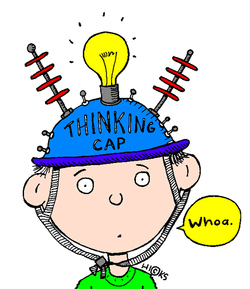

A partir das distribuições observadas no EDA, foram formuladas hipóteses exploratórias sobre os principais comportamentos e intenções presentes nos tickets.

Essas hipóteses possuem caráter interpretativo e ajudam a conectar a análise exploratória ao problema de classificação de Ticket Type.

**Hipótese exploratória 1 — Uma parcela expressiva dos usuários procura o suporte para situações relacionadas ao pós-compra**

A distribuição de Ticket Type mostra:

Refund request: 20,69%;

Technical issue: 20,63%;

Cancellation request: 20,01%;

Product inquiry: 19,38%;

Billing inquiry: 19,29%.

Também aparecem entre os assuntos frequentes temas como Refund request, Software bug, Delivery problem, Hardware issue, Battery life, Network problem e Data loss.

Esses resultados sugerem que uma parcela expressiva dos usuários procura o suporte depois da aquisição do produto para resolver problemas técnicos, financeiros, de entrega, cancelamento ou reembolso.

Entretanto, como as cinco classes de Ticket Type apresentam frequências bastante próximas, não é adequado afirmar que uma única intenção domina o conjunto de dados.

**Hipótese exploratória 2 — Parte dos usuários procura orientação para instalar, configurar ou verificar a compatibilidade dos produtos**

Entre os assuntos encontrados estão:

Product compatibility;

Installation support;

Product setup;

Product recommendation;

Peripheral compatibility.

Esses assuntos sugerem que uma parcela dos usuários utiliza o suporte não apenas quando ocorre uma falha, mas também para obter orientação sobre instalação, configuração, compatibilidade ou utilização adequada dos produtos.

Portanto, existe evidência descritiva de uma intenção relacionada à obtenção de assistência técnica e orientação de uso.

**Hipótese exploratória 3 — Uma parcela dos usuários pretende modificar ou encerrar uma transação já realizada**

Refund request representa 20,69% dos tickets e Cancellation request representa 20,01%.

Além disso, Refund request aparece entre os assuntos mais frequentes do dataset, assim como Cancellation request.

Esses padrões sugerem a existência de uma parcela relevante de usuários que entra em contato com o suporte com a intenção de solicitar reembolso, cancelar uma operação ou modificar uma relação de compra já estabelecida.

A análise exploratória, entretanto, não permite determinar isoladamente quais fatores causaram essas solicitações.

Observação sobre os canais de atendimento

A distribuição de Ticket Channel é bastante equilibrada:

Email: aproximadamente 25,30%;

Phone: aproximadamente 25,17%;

Social media: aproximadamente 25,04%;

Chat: aproximadamente 24,48%.

Portanto, não existe um canal claramente dominante.

Esse resultado é relevante do ponto de vista operacional e sugere um cenário de atendimento multicanal, mas não representa diretamente uma intenção do usuário.

Além disso, a análise multivariada mostrou associação muito fraca entre Ticket Channel e Ticket Type, indicando que o canal utilizado não parece diferenciar de maneira relevante a intenção do ticket.

In [18]:
# ============================================================
# TESTES FORMAIS DE HIPÓTESES
# ============================================================

from scipy.stats import mannwhitneyu


alpha = 0.05

resultados_testes = []


def executar_mann_whitney(
    nome_teste,
    coluna,
    classe_1,
    classe_2
):
    grupo_1 = (
        df.loc[
            df["Ticket Type"] == classe_1,
            coluna
        ]
        .dropna()
    )

    grupo_2 = (
        df.loc[
            df["Ticket Type"] == classe_2,
            coluna
        ]
        .dropna()
    )

    estatistica_u, p_valor = mannwhitneyu(
        grupo_1,
        grupo_2,
        alternative="two-sided"
    )

    if p_valor < alpha:

        decisao = "Rejeitar H0"

        interpretacao = (
            "Existe evidência estatística de diferença "
            "entre os grupos."
        )

    else:

        decisao = "Não rejeitar H0"

        interpretacao = (
            "Não há evidência estatística suficiente "
            "de diferença entre os grupos."
        )


    resultados_testes.append(
        {
            "Teste": nome_teste,
            "Variável": coluna,
            "Grupo 1": classe_1,
            "Grupo 2": classe_2,
            "n grupo 1": len(grupo_1),
            "n grupo 2": len(grupo_2),
            "Mediana grupo 1": grupo_1.median(),
            "Mediana grupo 2": grupo_2.median(),
            "Estatística U": estatistica_u,
            "p-valor": p_valor,
            "Decisão": decisao
        }
    )


    print_formatado(
        nome_teste
    )

    print(
        f"Variável analisada: {coluna}"
    )

    print(
        f"Grupo 1: {classe_1} "
        f"(n = {len(grupo_1)})"
    )

    print(
        f"Grupo 2: {classe_2} "
        f"(n = {len(grupo_2)})"
    )

    print(
        f"Mediana do grupo 1: "
        f"{grupo_1.median():.2f}"
    )

    print(
        f"Mediana do grupo 2: "
        f"{grupo_2.median():.2f}"
    )

    print(
        f"Estatística U: "
        f"{estatistica_u:.2f}"
    )

    print(
        f"p-valor: "
        f"{p_valor:.8f}"
    )

    print(
        f"Decisão: {decisao}"
    )

    print(
        f"Interpretação: "
        f"{interpretacao}"
    )


# ------------------------------------------------------------
# Hipótese formal 1
# ------------------------------------------------------------
#
# H0:
# A distribuição do comprimento das descrições é igual entre
# tickets Technical issue e Product inquiry.
#
# H1:
# A distribuição do comprimento das descrições é diferente
# entre tickets Technical issue e Product inquiry.
#

executar_mann_whitney(
    nome_teste=(
        "Hipótese formal 1 — Comprimento da descrição "
        "e tipo de intenção"
    ),
    coluna="Description Char Count",
    classe_1="Technical issue",
    classe_2="Product inquiry"
)


# ------------------------------------------------------------
# Hipótese formal 2
# ------------------------------------------------------------
#
# H0:
# A distribuição da quantidade de placeholders é igual entre
# Refund request e Cancellation request.
#
# H1:
# A distribuição da quantidade de placeholders é diferente
# entre Refund request e Cancellation request.
#

executar_mann_whitney(
    nome_teste=(
        "Hipótese formal 2 — Quantidade de placeholders "
        "e tipo de intenção"
    ),
    coluna="Description Placeholder Count",
    classe_1="Refund request",
    classe_2="Cancellation request"
)


# ------------------------------------------------------------
# Resumo
# ------------------------------------------------------------

print_formatado(
    "Resumo dos testes formais de hipóteses"
)

resultados_testes_df = pd.DataFrame(
    resultados_testes
)

display(
    resultados_testes_df.style.format(
        {
            "Mediana grupo 1": "{:.2f}",
            "Mediana grupo 2": "{:.2f}",
            "Estatística U": "{:.2f}",
            "p-valor": "{:.8f}"
        }
    )
)


print(
    "\nNível de significância utilizado: "
    f"{alpha:.2f}"
)

print(
    "\nO teste de Mann-Whitney foi escolhido porque "
    "as variáveis analisadas rejeitaram a hipótese "
    "de normalidade na etapa 1.7."
)

print("Ver Markdown")


Hipótese formal 1 — Comprimento da descrição e tipo de intenção
Variável analisada: Description Char Count
Grupo 1: Technical issue (n = 1747)
Grupo 2: Product inquiry (n = 1641)
Mediana do grupo 1: 297.00
Mediana do grupo 2: 299.00
Estatística U: 1384414.50
p-valor: 0.08505252
Decisão: Não rejeitar H0
Interpretação: Não há evidência estatística suficiente de diferença entre os grupos.

Hipótese formal 2 — Quantidade de placeholders e tipo de intenção
Variável analisada: Description Placeholder Count
Grupo 1: Refund request (n = 1752)
Grupo 2: Cancellation request (n = 1695)
Mediana do grupo 1: 2.00
Mediana do grupo 2: 2.00
Estatística U: 1496985.00
p-valor: 0.64775832
Decisão: Não rejeitar H0
Interpretação: Não há evidência estatística suficiente de diferença entre os grupos.

Resumo dos testes formais de hipóteses


,Teste,Variável,Grupo 1,Grupo 2,n grupo 1,n grupo 2,Mediana grupo 1,Mediana grupo 2,Estatística U,p-valor,Decisão
0,Hipótese formal 1 — Comprimento da descrição e tipo de intenção,Description Char Count,Technical issue,Product inquiry,1747,1641,297.00,299.00,1384414.50,0.08505252,Não rejeitar H0
1,Hipótese formal 2 — Quantidade de placeholders e tipo de intenção,Description Placeholder Count,Refund request,Cancellation request,1752,1695,2.00,2.00,1496985.00,0.64775832,Não rejeitar H0



Nível de significância utilizado: 0.05

O teste de Mann-Whitney foi escolhido porque as variáveis analisadas rejeitaram a hipótese de normalidade na etapa 1.7.
Ver Markdown


### Testes formais de hipóteses

Além das hipóteses exploratórias levantadas a partir das distribuições do dataset, foram realizados dois testes estatísticos formais.

Como as variáveis analisadas rejeitaram a hipótese de normalidade na etapa 1.7, foi utilizado o **teste não paramétrico de Mann-Whitney U**, com nível de significância de **5% (`α = 0,05`)**.

O objetivo foi verificar se características estruturais simples das descrições apresentam diferenças entre determinados tipos de intenção representados por `Ticket Type`.

---

#### Hipótese formal 1 — Comprimento da descrição e tipo de intenção

Foi investigado se o comprimento das descrições difere entre tickets classificados como `Technical issue` e `Product inquiry`.

**H0 — Hipótese nula**

A distribuição de `Description Char Count` é equivalente entre tickets `Technical issue` e `Product inquiry`.

**H1 — Hipótese alternativa**

A distribuição de `Description Char Count` difere entre tickets `Technical issue` e `Product inquiry`.

Os grupos analisados foram:

- `Technical issue`: **1.747 registros**;
- `Product inquiry`: **1.641 registros**.

As medianas observadas foram:

- `Technical issue`: **297 caracteres**;
- `Product inquiry`: **299 caracteres**.

O teste de Mann-Whitney produziu:

- estatística U: **1.384.414,50**;
- p-valor: **0,08505252**.

Como:

**p = 0,0851 > 0,05**

não existe evidência estatística suficiente para rejeitar H0.

Portanto, **não foi encontrada diferença estatisticamente significativa na distribuição do comprimento das descrições entre `Technical issue` e `Product inquiry`**.

Esse resultado é coerente com a análise multivariada anterior, na qual as médias e medianas do comprimento das descrições apresentaram valores muito semelhantes entre os tipos de ticket.

Assim, apenas o tamanho da descrição não parece ser suficiente para diferenciar essas duas intenções.

---

#### Hipótese formal 2 — Quantidade de placeholders e tipo de intenção

Foi investigado se a quantidade de placeholders presentes nas descrições difere entre tickets `Refund request` e `Cancellation request`.

**H0 — Hipótese nula**

A distribuição de `Description Placeholder Count` é equivalente entre tickets `Refund request` e `Cancellation request`.

**H1 — Hipótese alternativa**

A distribuição de `Description Placeholder Count` difere entre tickets `Refund request` e `Cancellation request`.

Os grupos analisados foram:

- `Refund request`: **1.752 registros**;
- `Cancellation request`: **1.695 registros**.

Em ambos os grupos, a mediana foi:

**2 placeholders por ticket.**

O teste de Mann-Whitney produziu:

- estatística U: **1.496.985,00**;
- p-valor: **0,64775832**.

Como:

**p = 0,6478 > 0,05**

não existe evidência estatística suficiente para rejeitar H0.

Portanto, **não foi encontrada diferença estatisticamente significativa na distribuição da quantidade de placeholders entre `Refund request` e `Cancellation request`**.

Esse resultado mostra que a simples quantidade de placeholders não diferencia adequadamente essas duas intenções.

---

### Relação com as hipóteses exploratórias

As hipóteses exploratórias indicaram que o conjunto de dados contém diferentes intenções dos usuários, como:

- resolver problemas técnicos;
- obter orientação sobre produtos;
- solicitar reembolso;
- cancelar transações.

Entretanto, os testes estatísticos mostram que essas intenções **não são facilmente diferenciadas apenas por características estruturais simples das mensagens**, como comprimento do texto ou quantidade de placeholders.

Assim, os resultados reforçam a necessidade de investigar o **conteúdo semântico de `Ticket Description`**, isto é, as palavras, expressões e padrões linguísticos utilizados pelos clientes.

Esse aspecto será especialmente importante no TP3, cujo objetivo será prever `Ticket Type`.

### Conclusão dos testes

Ao nível de significância de 5%:

1. **não foi rejeitada H0 na Hipótese formal 1** (`p = 0,08505252`);
2. **não foi rejeitada H0 na Hipótese formal 2** (`p = 0,64775832`);
3. o comprimento da descrição não apresentou diferença estatisticamente significativa entre `Technical issue` e `Product inquiry`;
4. a quantidade de placeholders não apresentou diferença estatisticamente significativa entre `Refund request` e `Cancellation request`;
5. os resultados reforçam que características estruturais simples possuem capacidade limitada para distinguir as intenções;
6. o conteúdo textual propriamente dito deverá receber maior atenção na futura modelagem de classificação.

Não rejeitar H0 não significa provar que os grupos são idênticos. Significa apenas que, com os dados e o nível de significância utilizados, **não existe evidência estatística suficiente para concluir que as distribuições diferem**.